In [1]:
###testing R in jyupter 
system("type R")

In [2]:
#package installation 
#install.packages("purrr")
#install.packages("tidyverse")
#conda install r-tidyverse r-purrr bioconductor-edger bioconductor-busparse bioconductor-rtracklayer r-dplyr -y 
#conda install -c conda-forge r-purrr -y
#conda install -c bioconda bioconductor-edger -y
#conda install -c bioconda bioconductor-busparse -y
#conda install -c bioconda bioconductor-rtracklayer -y
#conda install -c conda-forge r-dplyr -y 

In [3]:
library(purrr)
library(tidyverse)
library(edgeR)
library(rtracklayer)

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: limma

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’

In [4]:
library(purrr)
library(tidyverse)
f_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains", pattern = "*/Aligned.sortedByCoord.out_genes.out$", full.names = T)

f_files


character(0)

In [5]:
samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
samplenames

character(0)

In [6]:
#list of sample names with replicates 
lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))

lables

character(0)

In [7]:
A129S1_SvImJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/129S1_SvImJ_v3.2.gff3") #import gff3 file 
A129S1_SvImJ <- na.omit(mcols(A129S1_SvImJ)[,c("gene_id","Name",'type')])
A129S1_SvImJ <- A129S1_SvImJ[A129S1_SvImJ$type == 'gene', ]
A129S1_SvImJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(A129S1_SvImJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

A129S1_SvImJ_geneName = A129S1_SvImJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(A129S1_SvImJ_geneName) <- A129S1_SvImJ_geneName$gene_id
A129S1_SvImJ_geneName$gene_id <- NULL
A129S1_SvImJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#A129S1_SvImJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
A129S1_SvImJ_samplenames = c('129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-P20.5',
'129S1_SvImJ-P20.5','129S1_SvImJ-P20.5')

A129S1_SvImJ_lables = c('129S1_SvImJ-P12.5.1','129S1_SvImJ-P12.5.2','129S1_SvImJ-P12.5.3','129S1_SvImJ-E16.5.1','129S1_SvImJ-E16.5.2','129S1_SvImJ-E16.5.3','129S1_SvImJ-P20.5.1','129S1_SvImJ-P20.5.2','129S1_SvImJ-P20.5.3')

A129S1_SvImJ_raw <- readDGE(A129S1_SvImJ_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= A129S1_SvImJ_samplenames, labels = A129S1_SvImJ_lables)

library(dplyr)
A129S1_SvImJ_raw$counts <- merge(x=A129S1_SvImJ_raw$counts, y=A129S1_SvImJ_geneName, by = 0,all.x=TRUE ) #left merge 
A129S1_SvImJ_raw$counts['Row.names'] <- NULL
A129S1_SvImJ_raw$counts <- A129S1_SvImJ_raw$counts[!is.na(A129S1_SvImJ_raw$counts$Name),] #remove NA 
A129S1_SvImJ_raw$counts <- A129S1_SvImJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

A129S1_SvImJ_raw$counts <- as.data.frame(A129S1_SvImJ_raw$counts[!duplicated(A129S1_SvImJ_raw$counts$Name), ])  #remove dulicate values 
rownames(A129S1_SvImJ_raw$counts) <- A129S1_SvImJ_raw$counts$Name #set rawname to gene symbloes 
A129S1_SvImJ_raw$counts$Name <- NULL #remove genesybloe columns 
A129S1_SvImJ_raw

DataFrame with 20396 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00200002305        ugt1a1     gene
2     ENSMUSG00200002142          XKR4     gene
3     ENSMUSG00200001961           RP1     gene
4     ENSMUSG00200001998         SOX17     gene
5     ENSMUSG00200002527        MRPL15     gene
...                  ...           ...      ...
20392 ENSMUSG00200013771         AMELX     gene
20393 ENSMUSG00200013786          HCCS     gene
20394 ENSMUSG00200013810          rbmx     gene
20395 ENSMUSG00200013872          MID1     gene
20396 ENSMUSG00200013909 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00200002305,ugt1a1,gene
ENSMUSG00200002581,HMGB3,gene
ENSMUSG00200002586,RGS20,gene
ENSMUSG00200018450,RPL5,gene
ENSMUSG00200018421,RETN,gene
ENSMUSG00200018364,cetn4,gene
ENSMUSG00200018388,Khdc1b,gene
ENSMUSG00200018410,Khdc1b,gene
ENSMUSG00200018412,Khdc1b,gene


[1] 819

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
129S1_SvImJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,129S1_SvImJ-P12.5,1000000.0,1
129S1_SvImJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,129S1_SvImJ-P12.5,999999.8,1
129S1_SvImJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,129S1_SvImJ-P12.5,999999.7,1
129S1_SvImJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,129S1_SvImJ-E16.5,999999.6,1
129S1_SvImJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,129S1_SvImJ-E16.5,999999.3,1
129S1_SvImJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,129S1_SvImJ-E16.5,1000000.3,1
129S1_SvImJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,129S1_SvImJ-P20.5,1000000.3,1
129S1_SvImJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,129S1_SvImJ-P20.5,1000000.5,1
129S1_SvImJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/129S1_SvImJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,129S1_SvImJ-P20.5,999999.8,1


In [8]:
A_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/A_J_v3.2.gff3") #import gff3 file 
A_J <- na.omit(mcols(A_J)[,c("gene_id","Name",'type')])
A_J <- A_J[A_J$type == 'gene', ]
A_J


# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(A_J) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

A_J_geneName = A_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(A_J_geneName) <- A_J_geneName$gene_id
A_J_geneName$gene_id <- NULL
A_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#A_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "A_J.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
A_J_samplenames = c('A_J-P12.5','A_J-P12.5','A_J-P12.5','A_J-E16.5','A_J-E16.5','A_J-E16.5','A_J-P20.5','A_J-P20.5','A_J-P20.5')

A_J_lables = c('A_J-P12.5.1','A_J-P12.5.2','A_J-P12.5.3','A_J-E16.5.1','A_J-E16.5.2','A_J-E16.5.3','A_J-P20.5.1','A_J-P20.5.2','A_J-P20.5.3')

A_J_raw <- readDGE(A_J_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= A_J_samplenames, labels = A_J_lables)
A_J_raw
library(dplyr)
A_J_raw$counts <- merge(x=A_J_raw$counts, y=A_J_geneName, by = 0,all.x=TRUE ) #left merge 
A_J_raw$counts['Row.names'] <- NULL
A_J_raw$counts <- A_J_raw$counts[!is.na(A_J_raw$counts$Name),] #remove NA 
A_J_raw$counts <- A_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

A_J_raw$counts <- as.data.frame(A_J_raw$counts[!duplicated(A_J_raw$counts$Name), ])  #remove dulicate values 
rownames(A_J_raw$counts) <- A_J_raw$counts$Name #set rawname to gene symbloes 
A_J_raw$counts$Name <- NULL #remove genesybloe columns 
A_J_raw

DataFrame with 20472 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00195002697          XKR4     gene
2     ENSMUSG00195002553           RP1     gene
3     ENSMUSG00195002578         SOX17     gene
4     ENSMUSG00195002659        MRPL15     gene
5     ENSMUSG00195002525        LYPLA1     gene
...                  ...           ...      ...
20468 ENSMUSG00195016023         AMELX     gene
20469 ENSMUSG00195016042          HCCS     gene
20470 ENSMUSG00195016074          rbmx     gene
20471 ENSMUSG00195015519          MID1     gene
20472 ENSMUSG00195015611 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00195002535,HMGB3,gene
ENSMUSG00195002538,RGS20,gene
ENSMUSG00195002741,Gm4737,gene
ENSMUSG00195027030,rpl7,gene
ENSMUSG00195026754,cetn4,gene
ENSMUSG00195027068,Khdc1b,gene
ENSMUSG00195027241,Khdc1b,gene
ENSMUSG00195027352,Khdc1b,gene
ENSMUSG00195000040,rpl13,gene


[1] 847

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
A_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,A_J-P12.5,1000000.2,1
A_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,A_J-P12.5,1000000.3,1
A_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,A_J-P12.5,999999.6,1
A_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,A_J-E16.5,999999.1,1
A_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,A_J-E16.5,999999.5,1
A_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,A_J-E16.5,999999.7,1
A_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,A_J-P20.5,999999.7,1
A_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,A_J-P20.5,1000000.1,1
A_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,A_J-P20.5,999999.8,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
A_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,A_J-P12.5,1000000.2,1
A_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,A_J-P12.5,1000000.3,1
A_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,A_J-P12.5,999999.6,1
A_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,A_J-E16.5,999999.1,1
A_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,A_J-E16.5,999999.5,1
A_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,A_J-E16.5,999999.7,1
A_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,A_J-P20.5,999999.7,1
A_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,A_J-P20.5,1000000.1,1
A_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/A_J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,A_J-P20.5,999999.8,1


In [9]:
AKR_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/AKR_J_v3.2.gff3") #import gff3 file 
AKR_J <- na.omit(mcols(AKR_J)[,c("gene_id","Name",'type')])
AKR_J <- AKR_J[AKR_J$type == 'gene', ]
AKR_J

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(AKR_J) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

AKR_J_geneName = AKR_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(AKR_J_geneName) <- AKR_J_geneName$gene_id
AKR_J_geneName$gene_id <- NULL
AKR_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#AKR_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
AKR_J_samplenames = c('AKR_J-P12.5','AKR_J-P12.5','AKR_J-P12.5','AKR_J-E16.5',
'AKR_J-E16.5','AKR_J-E16.5','AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5')

AKR_J_lables = c('AKR_J-P12.5.1','AKR_J-P12.5.2','AKR_J-P12.5.3','AKR_J-E16.5.1','AKR_J-E16.5.2','AKR_J-E16.5.3',
'AKR_J-P20.5.1','AKR_J-P20.5.2','AKR_J-P20.5.3')

AKR_J_raw <- readDGE(AKR_J_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= AKR_J_samplenames, labels = AKR_J_lables)
AKR_J_raw
library(dplyr)
AKR_J_raw$counts <- merge(x=AKR_J_raw$counts, y=AKR_J_geneName, by = 0,all.x=TRUE ) #left merge 
AKR_J_raw$counts['Row.names'] <- NULL
AKR_J_raw$counts <- AKR_J_raw$counts[!is.na(AKR_J_raw$counts$Name),] #remove NA 
AKR_J_raw$counts <- AKR_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

AKR_J_raw$counts <- as.data.frame(AKR_J_raw$counts[!duplicated(AKR_J_raw$counts$Name), ])  #remove dulicate values 
rownames(AKR_J_raw$counts) <- AKR_J_raw$counts$Name #set rawname to gene symbloes 
AKR_J_raw$counts$Name <- NULL #remove genesybloe columns 
AKR_J_raw

DataFrame with 20391 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00220003361          XKR4     gene
2     ENSMUSG00220003474           RP1     gene
3     ENSMUSG00220003489         SOX17     gene
4     ENSMUSG00220003074        MRPL15     gene
5     ENSMUSG00220003096        LYPLA1     gene
...                  ...           ...      ...
20387 ENSMUSG00220030338         AMELX     gene
20388 ENSMUSG00220030408          HCCS     gene
20389 ENSMUSG00220030465          rbmx     gene
20390 ENSMUSG00220010896          MID1     gene
20391 ENSMUSG00220010941 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00220003122,HMGB3,gene
ENSMUSG00220003127,RGS20,gene
ENSMUSG00220002939,Gm4737,gene
ENSMUSG00220003225,COPS5,gene
ENSMUSG00220008002,rpl7,gene
ENSMUSG00220007908,cetn4,gene
ENSMUSG00220007871,Khdc1b,gene
ENSMUSG00220007935,Khdc1b,gene
ENSMUSG00220008043,Khdc1b,gene


[1] 849

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
AKR_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,AKR_J-P12.5,1000000.1,1
AKR_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,AKR_J-P12.5,1000000.0,1
AKR_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,AKR_J-P12.5,999999.6,1
AKR_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,AKR_J-E16.5,999999.7,1
AKR_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,AKR_J-E16.5,999999.8,1
AKR_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,AKR_J-E16.5,999999.6,1
AKR_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,AKR_J-P20.5,999999.9,1
AKR_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,AKR_J-P20.5,999999.5,1
AKR_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,AKR_J-P20.5,999999.5,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
AKR_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,AKR_J-P12.5,1000000.1,1
AKR_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,AKR_J-P12.5,1000000.0,1
AKR_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,AKR_J-P12.5,999999.6,1
AKR_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,AKR_J-E16.5,999999.7,1
AKR_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,AKR_J-E16.5,999999.8,1
AKR_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,AKR_J-E16.5,999999.6,1
AKR_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,AKR_J-P20.5,999999.9,1
AKR_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,AKR_J-P20.5,999999.5,1
AKR_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/AKR_J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,AKR_J-P20.5,999999.5,1


In [10]:
BALB_cJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/BALB_cJ_v3.2.gff3") #import gff3 file 
BALB_cJ <- na.omit(mcols(BALB_cJ)[,c("gene_id","Name",'type')])
BALB_cJ <- BALB_cJ[BALB_cJ$type == 'gene', ]
BALB_cJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(BALB_cJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))


BALB_cJ_geneName = BALB_cJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(BALB_cJ_geneName) <- BALB_cJ_geneName$gene_id
BALB_cJ_geneName$gene_id <- NULL
BALB_cJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#BALB_cJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
BALB_cJ_samplenames = c('BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-E16.5',
'BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5')

BALB_cJ_lables = c('BALB_cJ-P12.5.1','BALB_cJ-P12.5.2','BALB_cJ-P12.5.3','BALB_cJ-E16.5.1','BALB_cJ-E16.5.2','BALB_cJ-E16.5.3',
'BALB_cJ-P20.5.1','BALB_cJ-P20.5.2','BALB_cJ-P20.5.3')

BALB_cJ_raw <- readDGE(BALB_cJ_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= BALB_cJ_samplenames, labels = BALB_cJ_lables)
BALB_cJ_raw
library(dplyr)
BALB_cJ_raw$counts <- merge(x=BALB_cJ_raw$counts, y=BALB_cJ_geneName, by = 0,all.x=TRUE ) #left merge 
BALB_cJ_raw$counts['Row.names'] <- NULL
BALB_cJ_raw$counts <- BALB_cJ_raw$counts[!is.na(BALB_cJ_raw$counts$Name),] #remove NA 
BALB_cJ_raw$counts <- BALB_cJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

BALB_cJ_raw$counts <- as.data.frame(BALB_cJ_raw$counts[!duplicated(BALB_cJ_raw$counts$Name), ])  #remove dulicate values 
rownames(BALB_cJ_raw$counts) <- BALB_cJ_raw$counts$Name #set rawname to gene symbloes 
BALB_cJ_raw$counts$Name <- NULL #remove genesybloe columns 
BALB_cJ_raw

DataFrame with 20490 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00180008421          XKR4     gene
2     ENSMUSG00180008881           RP1     gene
3     ENSMUSG00180008896         SOX17     gene
4     ENSMUSG00180008861        MRPL15     gene
5     ENSMUSG00180008716        LYPLA1     gene
...                  ...           ...      ...
20486 ENSMUSG00180017230          MID1     gene
20487 ENSMUSG00180017318 4933400A11Rik     gene
20488 ENSMUSG00180017370         HSPB7     gene
20489 ENSMUSG00180017573           GSN     gene
20490 ENSMUSG00180017649          ASMT     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00180008759,HMGB3,gene
ENSMUSG00180008765,RGS20,gene
ENSMUSG00180008708,Gm4737,gene
ENSMUSG00180024291,cetn4,gene
ENSMUSG00180024352,Khdc1b,gene
ENSMUSG00180024299,Khdc1b,gene
ENSMUSG00180024328,Khdc1b,gene
ENSMUSG00180001053,rpl13,gene
ENSMUSG00180001099,4931428L18Rik,gene


[1] 844

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
BALB_cJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P12.5,999999.9,1
BALB_cJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P12.5,999999.3,1
BALB_cJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P12.5,1000000.2,1
BALB_cJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,BALB_cJ-E16.5,999999.5,1
BALB_cJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,BALB_cJ-E16.5,999999.6,1
BALB_cJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,BALB_cJ-E16.5,1000000.7,1
BALB_cJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P20.5,999999.5,1
BALB_cJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P20.5,999999.8,1
BALB_cJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P20.5,1000000.0,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
BALB_cJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P12.5,999999.9,1
BALB_cJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P12.5,999999.3,1
BALB_cJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P12.5,1000000.2,1
BALB_cJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,BALB_cJ-E16.5,999999.5,1
BALB_cJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,BALB_cJ-E16.5,999999.6,1
BALB_cJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,BALB_cJ-E16.5,1000000.7,1
BALB_cJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P20.5,999999.5,1
BALB_cJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P20.5,999999.8,1
BALB_cJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/BALB_cJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,BALB_cJ-P20.5,1000000.0,1


In [11]:
C3H_HeJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/C3H_HeJ_v3.2.gff3") #import gff3 file 
C3H_HeJ <- na.omit(mcols(C3H_HeJ)[,c("gene_id","Name",'type')])
C3H_HeJ <- C3H_HeJ[C3H_HeJ$type == 'gene', ]
C3H_HeJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(C3H_HeJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

C3H_HeJ_geneName = C3H_HeJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(C3H_HeJ_geneName) <- C3H_HeJ_geneName$gene_id
C3H_HeJ_geneName$gene_id <- NULL
C3H_HeJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#C3H_HeJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
C3H_HeJ_samplenames = c('C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-E16.5',
'C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5')

C3H_HeJ_lables = c('C3H_HeJ-P12.5.1','C3H_HeJ-P12.5.2','C3H_HeJ-P12.5.3','C3H_HeJ-E16.5.1','C3H_HeJ-E16.5.2','C3H_HeJ-E16.5.3',
'C3H_HeJ-P20.5.1','C3H_HeJ-P20.5.2','C3H_HeJ-P20.5.3')

C3H_HeJ_raw <- readDGE(C3H_HeJ_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= C3H_HeJ_samplenames, labels = C3H_HeJ_lables)
C3H_HeJ_raw
library(dplyr)
C3H_HeJ_raw$counts <- merge(x=C3H_HeJ_raw$counts, y=C3H_HeJ_geneName, by = 0,all.x=TRUE ) #left merge 
C3H_HeJ_raw$counts['Row.names'] <- NULL
C3H_HeJ_raw$counts <- C3H_HeJ_raw$counts[!is.na(C3H_HeJ_raw$counts$Name),] #remove NA 
C3H_HeJ_raw$counts <- C3H_HeJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

C3H_HeJ_raw$counts <- as.data.frame(C3H_HeJ_raw$counts[!duplicated(C3H_HeJ_raw$counts$Name), ])  #remove dulicate values 
rownames(C3H_HeJ_raw$counts) <- C3H_HeJ_raw$counts$Name #set rawname to gene symbloes 
C3H_HeJ_raw$counts$Name <- NULL #remove genesybloe columns 
C3H_HeJ_raw

DataFrame with 20427 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00175000235        CDCA7L     gene
2     ENSMUSG00175000248          XKR4     gene
3     ENSMUSG00175000083           RP1     gene
4     ENSMUSG00175000092         SOX17     gene
5     ENSMUSG00175000224        MRPL15     gene
...                  ...           ...      ...
20423 ENSMUSG00175010162          HCCS     gene
20424 ENSMUSG00175010173          rbmx     gene
20425 ENSMUSG00175010317          MID1     gene
20426 ENSMUSG00175010348 4933400A11Rik     gene
20427 ENSMUSG00175010363       DYNLRB2     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00175000235,CDCA7L,gene
ENSMUSG00175000275,HMGB3,gene
ENSMUSG00175000278,RGS20,gene
ENSMUSG00175000093,rpl7,gene
ENSMUSG00175000156,cetn4,gene
ENSMUSG00175000187,Khdc1b,gene
ENSMUSG00175000190,Khdc1b,gene
ENSMUSG00175000165,Khdc1b,gene
ENSMUSG00175000648,rpl13,gene


[1] 845

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C3H_HeJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P12.5,1000000.0,1
C3H_HeJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P12.5,999999.7,1
C3H_HeJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P12.5,1000000.5,1
C3H_HeJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-E16.5,1000000.5,1
C3H_HeJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-E16.5,1000000.2,1
C3H_HeJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-E16.5,999999.2,1
C3H_HeJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P20.5,999999.5,1
C3H_HeJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P20.5,1000000.1,1
C3H_HeJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P20.5,999999.9,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C3H_HeJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P12.5,1000000.0,1
C3H_HeJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P12.5,999999.7,1
C3H_HeJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P12.5,1000000.5,1
C3H_HeJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-E16.5,1000000.5,1
C3H_HeJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-E16.5,1000000.2,1
C3H_HeJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-E16.5,999999.2,1
C3H_HeJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P20.5,999999.5,1
C3H_HeJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P20.5,1000000.1,1
C3H_HeJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C3H_HeJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,C3H_HeJ-P20.5,999999.9,1


In [12]:
C57BL_6NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/C57BL_6NJ_v3.2.gff3") #import gff3 file 
C57BL_6NJ <- na.omit(mcols(C57BL_6NJ)[,c("gene_id","Name",'type')])
C57BL_6NJ <- C57BL_6NJ[C57BL_6NJ$type == 'gene', ]
C57BL_6NJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(C57BL_6NJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))


C57BL_6NJ_geneName = C57BL_6NJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(C57BL_6NJ_geneName) <- C57BL_6NJ_geneName$gene_id
C57BL_6NJ_geneName$gene_id <- NULL
C57BL_6NJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#C57BL_6NJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
C57BL_6NJ_samplenames = c('C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-E16.5',
'C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5')

C57BL_6NJ_lables = c('C57BL_6NJ-P12.5.1','C57BL_6NJ-P12.5.2','C57BL_6NJ-P12.5.3','C57BL_6NJ-E16.5.1','C57BL_6NJ-E16.5.2','C57BL_6NJ-E16.5.3',
'C57BL_6NJ-P20.5.1','C57BL_6NJ-P20.5.2','C57BL_6NJ-P20.5.3')

C57BL_6NJ_raw <- readDGE(C57BL_6NJ_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= C57BL_6NJ_samplenames, labels = C57BL_6NJ_lables)
C57BL_6NJ_raw
library(dplyr)
C57BL_6NJ_raw$counts <- merge(x=C57BL_6NJ_raw$counts, y=C57BL_6NJ_geneName, by = 0,all.x=TRUE ) #left merge 
C57BL_6NJ_raw$counts['Row.names'] <- NULL
C57BL_6NJ_raw$counts <- C57BL_6NJ_raw$counts[!is.na(C57BL_6NJ_raw$counts$Name),] #remove NA 
C57BL_6NJ_raw$counts <- C57BL_6NJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

C57BL_6NJ_raw$counts <- as.data.frame(C57BL_6NJ_raw$counts[!duplicated(C57BL_6NJ_raw$counts$Name), ])  #remove dulicate values 
rownames(C57BL_6NJ_raw$counts) <- C57BL_6NJ_raw$counts$Name #set rawname to gene symbloes 
C57BL_6NJ_raw$counts$Name <- NULL #remove genesybloe columns 
C57BL_6NJ_raw

DataFrame with 20459 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00215003924          XKR4     gene
2     ENSMUSG00215004064           RP1     gene
3     ENSMUSG00215004070         SOX17     gene
4     ENSMUSG00215004045        MRPL15     gene
5     ENSMUSG00215004089        LYPLA1     gene
...                  ...           ...      ...
20455 ENSMUSG00215015868         AMELX     gene
20456 ENSMUSG00215016025          HCCS     gene
20457 ENSMUSG00215016164          rbmx     gene
20458 ENSMUSG00215016408          MID1     gene
20459 ENSMUSG00215016857 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00215004096,HMGB3,gene
ENSMUSG00215004099,RGS20,gene
ENSMUSG00215003844,Gm4737,gene
ENSMUSG00215009764,cetn4,gene
ENSMUSG00215007914,Khdc1b,gene
ENSMUSG00215008143,Khdc1b,gene
ENSMUSG00215008161,Khdc1b,gene
ENSMUSG00215001024,MT-ND4L,gene
ENSMUSG00215001017,eef1g,gene


[1] 835

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C57BL_6NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P12.5,999999.5,1
C57BL_6NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P12.5,1000000.3,1
C57BL_6NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P12.5,1000000.1,1
C57BL_6NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-E16.5,1000000.2,1
C57BL_6NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-E16.5,1000000.2,1
C57BL_6NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-E16.5,999999.8,1
C57BL_6NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P20.5,999999.8,1
C57BL_6NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P20.5,1000000.0,1
C57BL_6NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P20.5,1000000.3,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
C57BL_6NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P12.5,999999.5,1
C57BL_6NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P12.5,1000000.3,1
C57BL_6NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P12.5,1000000.1,1
C57BL_6NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-E16.5,1000000.2,1
C57BL_6NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-E16.5,1000000.2,1
C57BL_6NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-E16.5,999999.8,1
C57BL_6NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P20.5,999999.8,1
C57BL_6NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P20.5,1000000.0,1
C57BL_6NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/C57BL_6NJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,C57BL_6NJ-P20.5,1000000.3,1


In [13]:
CAST_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/CAST_EiJ_v3.2.gff3") #import gff3 file 
CAST_EiJ <- na.omit(mcols(CAST_EiJ)[,c("gene_id","Name",'type')])
CAST_EiJ <- CAST_EiJ[CAST_EiJ$type == 'gene', ]
CAST_EiJ


# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(CAST_EiJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

CAST_EiJ_geneName = CAST_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(CAST_EiJ_geneName) <- CAST_EiJ_geneName$gene_id
CAST_EiJ_geneName$gene_id <- NULL
CAST_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#CAST_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
CAST_EiJ_samplenames = c('CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-E16.5',
'CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5')

CAST_EiJ_lables = c('CAST_EiJ-P12.5.1','CAST_EiJ-P12.5.2','CAST_EiJ-P12.5.3','CAST_EiJ-E16.5.1','CAST_EiJ-E16.5.2','CAST_EiJ-E16.5.3',
'CAST_EiJ-P20.5.1','CAST_EiJ-P20.5.2','CAST_EiJ-P20.5.3')

CAST_EiJ_raw <- readDGE(CAST_EiJ_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= CAST_EiJ_samplenames, labels = CAST_EiJ_lables)
CAST_EiJ_raw
library(dplyr)
CAST_EiJ_raw$counts <- merge(x=CAST_EiJ_raw$counts, y=CAST_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
CAST_EiJ_raw$counts['Row.names'] <- NULL
CAST_EiJ_raw$counts <- CAST_EiJ_raw$counts[!is.na(CAST_EiJ_raw$counts$Name),] #remove NA 
CAST_EiJ_raw$counts <- CAST_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

CAST_EiJ_raw$counts <- as.data.frame(CAST_EiJ_raw$counts[!duplicated(CAST_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(CAST_EiJ_raw$counts) <- CAST_EiJ_raw$counts$Name #set rawname to gene symbloes 
CAST_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
CAST_EiJ_raw

DataFrame with 20368 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSTCUG00005001819        MROH2A     gene
2     ENSTCUG00005001868         HJURP     gene
3     ENSTCUG00005002045          XKR4     gene
4     ENSTCUG00005001875           RP1     gene
5     ENSTCUG00005001952         SOX17     gene
...                  ...           ...      ...
20364 ENSTCUG00005024214          HCCS     gene
20365 ENSTCUG00005024248          rbmx     gene
20366 ENSTCUG00005023838          PRC1     gene
20367 ENSTCUG00005024102          MID1     gene
20368 ENSTCUG00005024201 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSTCUG00005001819,MROH2A,gene
ENSTCUG00005001868,HJURP,gene
ENSTCUG00005001742,LYPLA1,gene
ENSTCUG00005001771,HMGB3,gene
ENSTCUG00005020648,LY96,gene
ENSTCUG00005020749,Khdc1b,gene
ENSTCUG00005020764,Khdc1b,gene
ENSTCUG00005020792,Khdc1b,gene
ENSTCUG00005020817,Khdc1b,gene


[1] 851

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
CAST_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P12.5,999999.5,1
CAST_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P12.5,1000000.0,1
CAST_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P12.5,1000000.1,1
CAST_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-E16.5,999999.9,1
CAST_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-E16.5,1000000.4,1
CAST_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-E16.5,1000000.2,1
CAST_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P20.5,1000000.4,1
CAST_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P20.5,999999.8,1
CAST_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P20.5,1000000.1,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
CAST_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P12.5,999999.5,1
CAST_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P12.5,1000000.0,1
CAST_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P12.5,1000000.1,1
CAST_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-E16.5,999999.9,1
CAST_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-E16.5,1000000.4,1
CAST_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-E16.5,1000000.2,1
CAST_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P20.5,1000000.4,1
CAST_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P20.5,999999.8,1
CAST_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CAST_EiJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,CAST_EiJ-P20.5,1000000.1,1


In [14]:
CBA_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/CBA_J_v3.2.gff3") #import gff3 file 
CBA_J <- na.omit(mcols(CBA_J)[,c("gene_id","Name",'type')])
CBA_J <- CBA_J[CBA_J$type == 'gene', ]
CBA_J

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(CBA_J) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

CBA_J_geneName = CBA_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(CBA_J_geneName) <- CBA_J_geneName$gene_id
CBA_J_geneName$gene_id <- NULL
CBA_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
#'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#CBA_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
CBA_J_samplenames = c('CBA_J-P12.5','CBA_J-P12.5','CBA_J-P12.5',#'CBA_J-E16.5',
'CBA_J-E16.5','CBA_J-E16.5','CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5')

CBA_J_lables = c('CBA_J-P12.5.1','CBA_J-P12.5.3','CBA_J-E16.5.1','CBA_J-E16.5.2','CBA_J-E16.5.3',#'CBA_J-P12.5.2',
'CBA_J-P20.5.1','CBA_J-P20.5.2','CBA_J-P20.5.3')

CBA_J_raw <- readDGE(CBA_J_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= CBA_J_samplenames, labels = CBA_J_lables)
CBA_J_raw
library(dplyr)
CBA_J_raw$counts <- merge(x=CBA_J_raw$counts, y=CBA_J_geneName, by = 0,all.x=TRUE ) #left merge 
CBA_J_raw$counts['Row.names'] <- NULL
CBA_J_raw$counts <- CBA_J_raw$counts[!is.na(CBA_J_raw$counts$Name),] #remove NA 
CBA_J_raw$counts <- CBA_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

CBA_J_raw$counts <- as.data.frame(CBA_J_raw$counts[!duplicated(CBA_J_raw$counts$Name), ])  #remove dulicate values 
rownames(CBA_J_raw$counts) <- CBA_J_raw$counts$Name #set rawname to gene symbloes 
CBA_J_raw$counts$Name <- NULL #remove genesybloe columns 
CBA_J_raw

DataFrame with 20435 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00210001546          XKR4     gene
2     ENSMUSG00210001575           RP1     gene
3     ENSMUSG00210001604         SOX17     gene
4     ENSMUSG00210001755        MRPL15     gene
5     ENSMUSG00210001766        LYPLA1     gene
...                  ...           ...      ...
20431 ENSMUSG00210028259         AMELX     gene
20432 ENSMUSG00210028307          HCCS     gene
20433 ENSMUSG00210028366          rbmx     gene
20434 ENSMUSG00210027771          MID1     gene
20435 ENSMUSG00210027942 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00210001790,HMGB3,gene
ENSMUSG00210001793,RGS20,gene
ENSMUSG00210002588,rpl7,gene
ENSMUSG00210002745,cetn4,gene
ENSMUSG00210002755,Khdc1b,gene
ENSMUSG00210002563,Khdc1b,gene
ENSMUSG00210002566,Khdc1b,gene
ENSMUSG00210010462,rpl13,gene
ENSMUSG00210010480,MTCH2,gene


[1] 838

An object of class "DGEList"
$samples
                                                                                                                                              files
CBA_J-P12.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out
CBA_J-P12.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out
CBA_J-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out
CBA_J-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out
CBA_J-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out
CBA_J-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out
CBA_J-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out
CBA_J-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out
                    group  lib.size norm.factors
CBA_J-P12.5.1 CBA_J-P12.5  999999.8            1
CBA_J-P12.5.3 CBA_J-P12.5  999999.3            1
CBA_J-E16.5.1 CBA_J-P12.5  999999.4            1
CBA_J-E16.5.2 CBA_J-E16.5 1000000.0            1
CBA_J-E16.5.3 CBA_J-E16.5 1000000.0            1
CBA_J-P20.5.1 CBA_J-P20.5 1000000.4            1
CBA_J-P20.5.2 CBA_J-P20.5 1000000.0            1
CBA_J-P20.5.3 CBA_J-P20.5 1000000.4            1

$counts
                    Samples
Tags                 CBA_J-P12.5.1 CBA_J-P12.5.3 CBA_J-E16.5.1 CBA_J-E16.5.2
  ENSMUSG00210037368     0.5396510     0.4477990     0.0000000     0.0000000
  ENSMUSG00210039929     0.0195289     0.0171052     0.0000000     0.0100596
  ENSMUSG00210039962     8.1656500     6.9656900     3.4652500     5.8437600
  ENSMUSG00210032427     2.7325900     2.1088100     0.1008230     0.1367510
  ENSMUSG00210040050     5.3036600     3.6549900     0.0988417     0.1899410
                    Samples
Tags                 CBA_J-E16.5.3 CBA_J-P20.5.1 CBA_J-P20.5.2 CBA_J-P20.5.3
  ENSMUSG00210037368     0.0000000    0.41531800    0.36475100     0.4063330
  ENSMUSG00210039929     0.0128926    0.00973504    0.00737626     0.0251445
  ENSMUSG00210039962     3.2646700    9.03699000    5.36408000     6.2511500
  ENSMUSG00210032427     0.1344700    1.82993000    1.06325000     1.4674600
  ENSMUSG00210040050     0.0568011    3.23511000    1.87093000     2.7061800
49340 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                              files
CBA_J-P12.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out
CBA_J-P12.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out
CBA_J-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out
CBA_J-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out
CBA_J-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out
CBA_J-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out
CBA_J-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out
CBA_J-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/CBA_J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out
                    group  lib.size norm.factors
CBA_J-P12.5.1 CBA_J-P12.5  999999.8            1
CBA_J-P12.5.3 CBA_J-P12.5  999999.3            1
CBA_J-E16.5.1 CBA_J-P12.5  999999.4            1
CBA_J-E16.5.2 CBA_J-E16.5 1000000.0            1
CBA_J-E16.5.3 CBA_J-E16.5 1000000.0            1
CBA_J-P20.5.1 CBA_J-P20.5 1000000.4            1
CBA_J-P20.5.2 CBA_J-P20.5 1000000.0            1
CBA_J-P20.5.3 CBA_J-P20.5 1000000.4            1

$counts
              CBA_J-P12.5.1 CBA_J-P12.5.3 CBA_J-E16.5.1 CBA_J-E16.5.2
0610007P14Rik      10.26474       9.23764     15.129520      19.09052
0610009B22Rik       2.43282       2.19281      2.427080       2.82088
0610009O20Rik       1.74907       1.61718      2.775780       3.36176
0610010F05Rik       1.14865       1.01238      0.448454       0.62993
0610010K14Rik       6.51653       4.72993      4.366010       7.44192
              CBA_J-E16.5.3 CBA_J-P20.5.1 CBA_J-P20.5.2 CBA_J-P20.5.3
0610007P14Rik     16.908330      10.30053       7.31432       7.76410
0610009B22Rik      2.630870       4.53057       3.38427       3.36272
0610009O20Rik      2.832820       2.99072       2.08702       2.32274
0610010F05Rik      0.392249       1.59975       1.07555       1.24132
0610010K14Rik      4.708840       4.91802       3.05171       3.64861
18785 more rows ...

In [15]:
DBA_2J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/DBA_2J_v3.2.gff3") #import gff3 file 
DBA_2J <- na.omit(mcols(DBA_2J)[,c("gene_id","Name",'type')])
DBA_2J <- DBA_2J[DBA_2J$type == 'gene', ]
DBA_2J

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(DBA_2J) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

DBA_2J_geneName = DBA_2J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(DBA_2J_geneName) <- DBA_2J_geneName$gene_id
DBA_2J_geneName$gene_id <- NULL
DBA_2J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#DBA_2J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
DBA_2J_samplenames = c('DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-E16.5',
'DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5')

DBA_2J_lables = c('DBA_2J-P12.5.1','DBA_2J-P12.5.2','DBA_2J-P12.5.3','DBA_2J-E16.5.1','DBA_2J-E16.5.2','DBA_2J-E16.5.3',
'DBA_2J-P20.5.1','DBA_2J-P20.5.2','DBA_2J-P20.5.3')

DBA_2J_raw <- readDGE(DBA_2J_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= DBA_2J_samplenames, labels = DBA_2J_lables)
DBA_2J_raw
library(dplyr)
DBA_2J_raw$counts <- merge(x=DBA_2J_raw$counts, y=DBA_2J_geneName, by = 0,all.x=TRUE ) #left merge 
DBA_2J_raw$counts['Row.names'] <- NULL
DBA_2J_raw$counts <- DBA_2J_raw$counts[!is.na(DBA_2J_raw$counts$Name),] #remove NA 
DBA_2J_raw$counts <- DBA_2J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

DBA_2J_raw$counts <- as.data.frame(DBA_2J_raw$counts[!duplicated(DBA_2J_raw$counts$Name), ])  #remove dulicate values 
rownames(DBA_2J_raw$counts) <- DBA_2J_raw$counts$Name #set rawname to gene symbloes 
DBA_2J_raw$counts$Name <- NULL #remove genesybloe columns 
DBA_2J_raw

DataFrame with 20744 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00185003942        ugt1a1     gene
2     ENSMUSG00185003991         HJURP     gene
3     ENSMUSG00185003999         HJURP     gene
4     ENSMUSG00185004005        ugt1a1     gene
5     ENSMUSG00185004011        MROH2A     gene
...                  ...           ...      ...
20740 ENSMUSG00185029791         AMELX     gene
20741 ENSMUSG00185029830          HCCS     gene
20742 ENSMUSG00185029875          rbmx     gene
20743 ENSMUSG00185029083          MID1     gene
20744 ENSMUSG00185029146 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00185003942,ugt1a1,gene
ENSMUSG00185003991,HJURP,gene
ENSMUSG00185003999,HJURP,gene
ENSMUSG00185004005,ugt1a1,gene
ENSMUSG00185004011,MROH2A,gene
ENSMUSG00185004210,HMGB3,gene
ENSMUSG00185004215,RGS20,gene
ENSMUSG00185003939,Gm4737,gene
ENSMUSG00185003692,RPL5,gene


[1] 871

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
DBA_2J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,DBA_2J-P12.5,1000000.3,1
DBA_2J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,DBA_2J-P12.5,999999.9,1
DBA_2J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,DBA_2J-P12.5,1000000.8,1
DBA_2J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,DBA_2J-E16.5,999999.1,1
DBA_2J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,DBA_2J-E16.5,1000000.0,1
DBA_2J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,DBA_2J-E16.5,999999.7,1
DBA_2J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,DBA_2J-P20.5,1000000.0,1
DBA_2J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,DBA_2J-P20.5,999999.7,1
DBA_2J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,DBA_2J-P20.5,1000000.2,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
DBA_2J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,DBA_2J-P12.5,1000000.3,1
DBA_2J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,DBA_2J-P12.5,999999.9,1
DBA_2J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,DBA_2J-P12.5,1000000.8,1
DBA_2J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,DBA_2J-E16.5,999999.1,1
DBA_2J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,DBA_2J-E16.5,1000000.0,1
DBA_2J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,DBA_2J-E16.5,999999.7,1
DBA_2J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,DBA_2J-P20.5,1000000.0,1
DBA_2J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,DBA_2J-P20.5,999999.7,1
DBA_2J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/DBA_2J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,DBA_2J-P20.5,1000000.2,1


In [16]:
FVB_NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/FVB_NJ_v3.2.gff3") #import gff3 file 
FVB_NJ <- na.omit(mcols(FVB_NJ)[,c("gene_id","Name",'type')])
FVB_NJ <- FVB_NJ[FVB_NJ$type == 'gene', ]
FVB_NJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(FVB_NJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

FVB_NJ_geneName = FVB_NJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(FVB_NJ_geneName) <- FVB_NJ_geneName$gene_id
FVB_NJ_geneName$gene_id <- NULL
FVB_NJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#FVB_NJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
FVB_NJ_samplenames = c('FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-E16.5',
'FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5')

FVB_NJ_lables = c('FVB_NJ-P12.5.1','FVB_NJ-P12.5.2','FVB_NJ-P12.5.3','FVB_NJ-E16.5.1','FVB_NJ-E16.5.2','FVB_NJ-E16.5.3',
'FVB_NJ-P20.5.1','FVB_NJ-P20.5.2','FVB_NJ-P20.5.3')

FVB_NJ_raw <- readDGE(FVB_NJ_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= FVB_NJ_samplenames, labels = FVB_NJ_lables)
FVB_NJ_raw
library(dplyr)
FVB_NJ_raw$counts <- merge(x=FVB_NJ_raw$counts, y=FVB_NJ_geneName, by = 0,all.x=TRUE ) #left merge 
FVB_NJ_raw$counts['Row.names'] <- NULL
FVB_NJ_raw$counts <- FVB_NJ_raw$counts[!is.na(FVB_NJ_raw$counts$Name),] #remove NA 
FVB_NJ_raw$counts <- FVB_NJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

FVB_NJ_raw$counts <- as.data.frame(FVB_NJ_raw$counts[!duplicated(FVB_NJ_raw$counts$Name), ])  #remove dulicate values 
rownames(FVB_NJ_raw$counts) <- FVB_NJ_raw$counts$Name #set rawname to gene symbloes 
FVB_NJ_raw$counts$Name <- NULL #remove genesybloe columns 
FVB_NJ_raw

DataFrame with 20249 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00205004560          XKR4     gene
2     ENSMUSG00205004861           RP1     gene
3     ENSMUSG00205005121         SOX17     gene
4     ENSMUSG00205004846        MRPL15     gene
5     ENSMUSG00205004466        LYPLA1     gene
...                  ...           ...      ...
20245 ENSMUSG00205002553         AMELX     gene
20246 ENSMUSG00205002563          HCCS     gene
20247 ENSMUSG00205002570          rbmx     gene
20248 ENSMUSG00205002644          MID1     gene
20249 ENSMUSG00205002674 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00205004517,HMGB3,gene
ENSMUSG00205004522,RGS20,gene
ENSMUSG00205012700,cetn4,gene
ENSMUSG00205014065,Khdc1b,gene
ENSMUSG00205012720,Khdc1b,gene
ENSMUSG00205012736,Khdc1b,gene
ENSMUSG00205006880,rpl13,gene
ENSMUSG00205006901,MTCH2,gene
ENSMUSG00205006772,SDHAF4,gene


[1] 814

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
FVB_NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P12.5,999999.7,1
FVB_NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P12.5,1000000.0,1
FVB_NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P12.5,1000000.4,1
FVB_NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,FVB_NJ-E16.5,999999.7,1
FVB_NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,FVB_NJ-E16.5,999999.9,1
FVB_NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,FVB_NJ-E16.5,1000000.4,1
FVB_NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P20.5,1000000.3,1
FVB_NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P20.5,999999.9,1
FVB_NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P20.5,999999.9,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
FVB_NJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P12.5,999999.7,1
FVB_NJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P12.5,1000000.0,1
FVB_NJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P12.5,1000000.4,1
FVB_NJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,FVB_NJ-E16.5,999999.7,1
FVB_NJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,FVB_NJ-E16.5,999999.9,1
FVB_NJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,FVB_NJ-E16.5,1000000.4,1
FVB_NJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P20.5,1000000.3,1
FVB_NJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P20.5,999999.9,1
FVB_NJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/FVB_NJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,FVB_NJ-P20.5,999999.9,1


In [17]:
NOD_ShiLtJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/NOD_ShiLtJ_v3.2.gff3") #import gff3 file 
NOD_ShiLtJ <- na.omit(mcols(NOD_ShiLtJ)[,c("gene_id","Name",'type')])
NOD_ShiLtJ <- NOD_ShiLtJ[NOD_ShiLtJ$type == 'gene', ]
NOD_ShiLtJ


# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(NOD_ShiLtJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))


NOD_ShiLtJ_geneName = NOD_ShiLtJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(NOD_ShiLtJ_geneName) <- NOD_ShiLtJ_geneName$gene_id
NOD_ShiLtJ_geneName$gene_id <- NULL
NOD_ShiLtJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#NOD_ShiLtJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
NOD_ShiLtJ_samplenames = c('NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-E16.5',
'NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5')

NOD_ShiLtJ_lables = c('NOD_ShiLtJ-P12.5.1','NOD_ShiLtJ-P12.5.2','NOD_ShiLtJ-P12.5.3','NOD_ShiLtJ-E16.5.1','NOD_ShiLtJ-E16.5.2','NOD_ShiLtJ-E16.5.3',
'NOD_ShiLtJ-P20.5.1','NOD_ShiLtJ-P20.5.2','NOD_ShiLtJ-P20.5.3')

NOD_ShiLtJ_raw <- readDGE(NOD_ShiLtJ_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= NOD_ShiLtJ_samplenames, labels = NOD_ShiLtJ_lables)
NOD_ShiLtJ_raw
library(dplyr)
NOD_ShiLtJ_raw$counts <- merge(x=NOD_ShiLtJ_raw$counts, y=NOD_ShiLtJ_geneName, by = 0,all.x=TRUE ) #left merge 
NOD_ShiLtJ_raw$counts['Row.names'] <- NULL
NOD_ShiLtJ_raw$counts <- NOD_ShiLtJ_raw$counts[!is.na(NOD_ShiLtJ_raw$counts$Name),] #remove NA 
NOD_ShiLtJ_raw$counts <- NOD_ShiLtJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

NOD_ShiLtJ_raw$counts <- as.data.frame(NOD_ShiLtJ_raw$counts[!duplicated(NOD_ShiLtJ_raw$counts$Name), ])  #remove dulicate values 
rownames(NOD_ShiLtJ_raw$counts) <- NOD_ShiLtJ_raw$counts$Name #set rawname to gene symbloes 
NOD_ShiLtJ_raw$counts$Name <- NULL #remove genesybloe columns 
NOD_ShiLtJ_raw

DataFrame with 20402 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00190001012          XKR4     gene
2     ENSMUSG00190001200           RP1     gene
3     ENSMUSG00190001204         SOX17     gene
4     ENSMUSG00190000988        MRPL15     gene
5     ENSMUSG00190001005        LYPLA1     gene
...                  ...           ...      ...
20398 ENSMUSG00190021047          HCCS     gene
20399 ENSMUSG00190021097          rbmx     gene
20400 ENSMUSG00190021319          MID1     gene
20401 ENSMUSG00190021390 4933400A11Rik     gene
20402 ENSMUSG00190021442          ASMT     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00190001007,HMGB3,gene
ENSMUSG00190001008,RGS20,gene
ENSMUSG00190001139,Gm4737,gene
ENSMUSG00190001140,COPS5,gene
ENSMUSG00190026098,cetn4,gene
ENSMUSG00190026909,Khdc1b,gene
ENSMUSG00190026957,Khdc1b,gene
ENSMUSG00190026998,Khdc1b,gene
ENSMUSG00190000039,rpl13,gene


[1] 836

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
NOD_ShiLtJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P12.5,1000000.1,1
NOD_ShiLtJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P12.5,1000000.2,1
NOD_ShiLtJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P12.5,1000000.4,1
NOD_ShiLtJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-E16.5,1000000.3,1
NOD_ShiLtJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-E16.5,1000000.5,1
NOD_ShiLtJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-E16.5,1000000.1,1
NOD_ShiLtJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P20.5,1000000.4,1
NOD_ShiLtJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P20.5,1000000.0,1
NOD_ShiLtJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P20.5,999999.6,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
NOD_ShiLtJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P12.5,1000000.1,1
NOD_ShiLtJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P12.5,1000000.2,1
NOD_ShiLtJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P12.5,1000000.4,1
NOD_ShiLtJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-E16.5,1000000.3,1
NOD_ShiLtJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-E16.5,1000000.5,1
NOD_ShiLtJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-E16.5,1000000.1,1
NOD_ShiLtJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P20.5,1000000.4,1
NOD_ShiLtJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P20.5,1000000.0,1
NOD_ShiLtJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NOD_ShiLtJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,NOD_ShiLtJ-P20.5,999999.6,1


In [18]:
PWK_PhJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/PWK_PhJ_v3.2.gff3") #import gff3 file 
PWK_PhJ <- na.omit(mcols(PWK_PhJ)[,c("gene_id","Name",'type')])
PWK_PhJ <- PWK_PhJ[PWK_PhJ$type == 'gene', ]
PWK_PhJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(PWK_PhJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

PWK_PhJ_geneName = PWK_PhJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(PWK_PhJ_geneName) <- PWK_PhJ_geneName$gene_id
PWK_PhJ_geneName$gene_id <- NULL
PWK_PhJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#PWK_PhJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
PWK_PhJ_samplenames = c('PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-E16.5',
'PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5')

PWK_PhJ_lables = c('PWK_PhJ-P12.5.1','PWK_PhJ-P12.5.2','PWK_PhJ-P12.5.3','PWK_PhJ-E16.5.1','PWK_PhJ-E16.5.2','PWK_PhJ-E16.5.3',
'PWK_PhJ-P20.5.1','PWK_PhJ-P20.5.2','PWK_PhJ-P20.5.3')

PWK_PhJ_raw <- readDGE(PWK_PhJ_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= PWK_PhJ_samplenames, labels = PWK_PhJ_lables)
PWK_PhJ_raw
library(dplyr)
PWK_PhJ_raw$counts <- merge(x=PWK_PhJ_raw$counts, y=PWK_PhJ_geneName, by = 0,all.x=TRUE ) #left merge 
PWK_PhJ_raw$counts['Row.names'] <- NULL
PWK_PhJ_raw$counts <- PWK_PhJ_raw$counts[!is.na(PWK_PhJ_raw$counts$Name),] #remove NA 
PWK_PhJ_raw$counts <- PWK_PhJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

PWK_PhJ_raw$counts <- as.data.frame(PWK_PhJ_raw$counts[!duplicated(PWK_PhJ_raw$counts$Name), ])  #remove dulicate values 
rownames(PWK_PhJ_raw$counts) <- PWK_PhJ_raw$counts$Name #set rawname to gene symbloes 
PWK_PhJ_raw$counts$Name <- NULL #remove genesybloe columns 
PWK_PhJ_raw

DataFrame with 20311 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSLUMG00010002333          XKR4     gene
2     ENSLUMG00010002218           RP1     gene
3     ENSLUMG00010002217         SOX17     gene
4     ENSLUMG00010002301        MRPL15     gene
5     ENSLUMG00010002268        LYPLA1     gene
...                  ...           ...      ...
20307 ENSLUMG00010001640          HCCS     gene
20308 ENSLUMG00010001642          rbmx     gene
20309 ENSLUMG00010001632          MID1     gene
20310 ENSLUMG00010001635 4933400A11Rik     gene
20311 ENSLUMG00010001636       DYNLRB2     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSLUMG00010002277,TCEA1,gene
ENSLUMG00010002198,COPS5,gene
ENSLUMG00010021331,Atp5h,gene
ENSLUMG00010020702,PHF5A,gene
ENSLUMG00010021125,WDR83OS,gene
ENSLUMG00010020880,LY96,gene
ENSLUMG00010021734,MRPS33,gene
ENSLUMG00010021671,tra2b,gene
ENSLUMG00010021610,Khdc1b,gene


[1] 871

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
PWK_PhJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P12.5,1000000.9,1
PWK_PhJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P12.5,1000000.2,1
PWK_PhJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P12.5,1000000.0,1
PWK_PhJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-E16.5,999999.9,1
PWK_PhJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-E16.5,999999.7,1
PWK_PhJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-E16.5,1000000.7,1
PWK_PhJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P20.5,1000000.5,1
PWK_PhJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P20.5,1000000.4,1
PWK_PhJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P20.5,999999.2,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
PWK_PhJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P12.5,1000000.9,1
PWK_PhJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P12.5,1000000.2,1
PWK_PhJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P12.5,1000000.0,1
PWK_PhJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-E16.5,999999.9,1
PWK_PhJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-E16.5,999999.7,1
PWK_PhJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-E16.5,1000000.7,1
PWK_PhJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P20.5,1000000.5,1
PWK_PhJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P20.5,1000000.4,1
PWK_PhJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/PWK_PhJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,PWK_PhJ-P20.5,999999.2,1


In [19]:
SPRET_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/SPRET_EiJ_v3.2.gff3") #import gff3 file 
SPRET_EiJ <- na.omit(mcols(SPRET_EiJ)[,c("gene_id","Name",'type')])
SPRET_EiJ <- SPRET_EiJ[SPRET_EiJ$type == 'gene', ]
SPRET_EiJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(SPRET_EiJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

SPRET_EiJ_geneName = SPRET_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(SPRET_EiJ_geneName) <- SPRET_EiJ_geneName$gene_id
SPRET_EiJ_geneName$gene_id <- NULL
SPRET_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#SPRET_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
SPRET_EiJ_samplenames = c('SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-E16.5',
'SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5')

SPRET_EiJ_lables = c('SPRET_EiJ-P12.5.1','SPRET_EiJ-P12.5.2','SPRET_EiJ-P12.5.3','SPRET_EiJ-E16.5.1','SPRET_EiJ-E16.5.2','SPRET_EiJ-E16.5.3',
'SPRET_EiJ-P20.5.1','SPRET_EiJ-P20.5.2','SPRET_EiJ-P20.5.3')

SPRET_EiJ_raw <- readDGE(SPRET_EiJ_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= SPRET_EiJ_samplenames, labels = SPRET_EiJ_lables)
SPRET_EiJ_raw
library(dplyr)
SPRET_EiJ_raw$counts <- merge(x=SPRET_EiJ_raw$counts, y=SPRET_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
SPRET_EiJ_raw$counts['Row.names'] <- NULL
SPRET_EiJ_raw$counts <- SPRET_EiJ_raw$counts[!is.na(SPRET_EiJ_raw$counts$Name),] #remove NA 
SPRET_EiJ_raw$counts <- SPRET_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

SPRET_EiJ_raw$counts <- as.data.frame(SPRET_EiJ_raw$counts[!duplicated(SPRET_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(SPRET_EiJ_raw$counts) <- SPRET_EiJ_raw$counts$Name #set rawname to gene symbloes 
SPRET_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
SPRET_EiJ_raw

DataFrame with 19975 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMSPG00010013869          XKR4     gene
2     ENSMSPG00010013465           RP1     gene
3     ENSMSPG00010013678         SOX17     gene
4     ENSMSPG00010013963        MRPL15     gene
5     ENSMSPG00010013304        LYPLA1     gene
...                  ...           ...      ...
19971 ENSMSPG00010025834         BUD13     gene
19972 ENSMSPG00010025902          MID1     gene
19973 ENSMSPG00010026011 4933400A11Rik     gene
19974 ENSMSPG00010025005         CLCN4     gene
19975 ENSMSPG00010025308          WWC3     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMSPG00010012915,DBX2,gene
ENSMSPG00010013107,btf3,gene
ENSMSPG00010025777,rpl6,gene
ENSMSPG00010024791,rpl7,gene
ENSMSPG00010026070,ube2w,gene
ENSMSPG00010026630,rps24,gene
ENSMSPG00010024872,rpl37,gene
ENSMSPG00010000598,NSA2,gene
ENSMSPG00010000621,GAPDH,gene


[1] 820

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
SPRET_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P12.5,1000000.7,1
SPRET_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P12.5,1000000.0,1
SPRET_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P12.5,1000000.0,1
SPRET_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-E16.5,1000000.0,1
SPRET_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-E16.5,1000000.0,1
SPRET_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-E16.5,999999.4,1
SPRET_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P20.5,1000000.0,1
SPRET_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P20.5,999999.4,1
SPRET_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P20.5,1000000.4,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
SPRET_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P12.5,1000000.7,1
SPRET_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P12.5,1000000.0,1
SPRET_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P12.5,1000000.0,1
SPRET_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-E16.5,1000000.0,1
SPRET_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-E16.5,1000000.0,1
SPRET_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-E16.5,999999.4,1
SPRET_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P20.5,1000000.0,1
SPRET_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P20.5,999999.4,1
SPRET_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/SPRET_EiJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,SPRET_EiJ-P20.5,1000000.4,1


In [20]:
WSB_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/WSB_EiJ_v3.2.gff3") #import gff3 file 
WSB_EiJ <- na.omit(mcols(WSB_EiJ)[,c("gene_id","Name",'type')])
WSB_EiJ <- WSB_EiJ[WSB_EiJ$type == 'gene', ]
WSB_EiJ
# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(WSB_EiJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))


WSB_EiJ_geneName = WSB_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(WSB_EiJ_geneName) <- WSB_EiJ_geneName$gene_id
WSB_EiJ_geneName$gene_id <- NULL
WSB_EiJ_geneName
WSB_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#WSB_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
WSB_EiJ_samplenames = c('WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-E16.5',
'WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')

WSB_EiJ_lables = c('WSB_EiJ-P12.5.1','WSB_EiJ-P12.5.2','WSB_EiJ-P12.5.3','WSB_EiJ-E16.5.1','WSB_EiJ-E16.5.2','WSB_EiJ-E16.5.3',
'WSB_EiJ-P20.5.1','WSB_EiJ-P20.5.2','WSB_EiJ-P20.5.3')

WSB_EiJ_raw <- readDGE(WSB_EiJ_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= WSB_EiJ_samplenames, labels = WSB_EiJ_lables)
WSB_EiJ_raw
library(dplyr)
WSB_EiJ_raw$counts <- merge(x=WSB_EiJ_raw$counts, y=WSB_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
WSB_EiJ_raw$counts['Row.names'] <- NULL
WSB_EiJ_raw$counts <- WSB_EiJ_raw$counts[!is.na(WSB_EiJ_raw$counts$Name),] #remove NA 
WSB_EiJ_raw$counts <- WSB_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))
WSB_EiJ_raw
WSB_EiJ_raw$counts <- as.data.frame(WSB_EiJ_raw$counts[!duplicated(WSB_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(WSB_EiJ_raw$counts) <- WSB_EiJ_raw$counts$Name #set rawname to gene symbloes 
WSB_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
WSB_EiJ_raw

DataFrame with 20295 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSIUOG00005011030      C16orf92     gene
2     ENSIUOG00005011041          XKR4     gene
3     ENSIUOG00005010731           RP1     gene
4     ENSIUOG00005010829         SOX17     gene
5     ENSIUOG00005010349        MRPL15     gene
...                  ...           ...      ...
20291 ENSIUOG00005010896         AMELX     gene
20292 ENSIUOG00005010918          HCCS     gene
20293 ENSIUOG00005010927          rbmx     gene
20294 ENSIUOG00005011018          MID1     gene
20295 ENSIUOG00005011033 4933400A11Rik     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSIUOG00005011030,C16orf92,gene
ENSIUOG00005010410,HMGB3,gene
ENSIUOG00005010417,RGS20,gene
ENSIUOG00005011423,WDR83OS,gene
ENSIUOG00005011429,GAPDH,gene
ENSIUOG00005011567,rpl7,gene
ENSIUOG00005011170,Khdc1b,gene
ENSIUOG00005011294,Khdc1b,gene
ENSIUOG00005011286,Khdc1b,gene


[1] 815

DataFrame with 20295 rows and 1 column
                            Name
                     <character>
ENSIUOG00005011030      C16orf92
ENSIUOG00005011041          XKR4
ENSIUOG00005010731           RP1
ENSIUOG00005010829         SOX17
ENSIUOG00005010349        MRPL15
...                          ...
ENSIUOG00005010896         AMELX
ENSIUOG00005010918          HCCS
ENSIUOG00005010927          rbmx
ENSIUOG00005011018          MID1
ENSIUOG00005011033 4933400A11Rik

,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
WSB_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P12.5,999999.6,1
WSB_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P12.5,1000000.1,1
WSB_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P12.5,999999.9,1
WSB_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-E16.5,1000000.4,1
WSB_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-E16.5,1000000.0,1
WSB_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-E16.5,1000000.3,1
WSB_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P20.5,1000000.2,1
WSB_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P20.5,1000000.0,1
WSB_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P20.5,1000000.6,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
WSB_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P12.5,999999.6,1
WSB_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P12.5,1000000.1,1
WSB_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P12.5,999999.9,1
WSB_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-E16.5,1000000.4,1
WSB_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-E16.5,1000000.0,1
WSB_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-E16.5,1000000.3,1
WSB_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P20.5,1000000.2,1
WSB_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P20.5,1000000.0,1
WSB_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P20.5,1000000.6,1


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
WSB_EiJ-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P12.5,999999.6,1
WSB_EiJ-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P12.5,1000000.1,1
WSB_EiJ-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P12.5,999999.9,1
WSB_EiJ-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-E16.5,1000000.4,1
WSB_EiJ-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-E16.5,1000000.0,1
WSB_EiJ-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-E16.5,1000000.3,1
WSB_EiJ-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P20.5,1000000.2,1
WSB_EiJ-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P20.5,1000000.0,1
WSB_EiJ-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/WSB_EiJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,WSB_EiJ-P20.5,1000000.6,1


In [21]:
NZO_HlLtJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/NZO_HlLtJ_v3.2.gff3") #import gff3 file 
#NZO_HlLtJ_geneName = na.omit(mcols(NZO_HlLtJ)[,c("gene_id","Name",'type')]) #get gene symbloes for respective gene id 
NZO_HlLtJ <- na.omit(mcols(NZO_HlLtJ)[,c("gene_id","Name",'type')])
#colnames(NZO_HlLtJ)[which(names(NZO_HlLtJ) == "Name")] <- "Name" #change columns name
NZO_HlLtJ <- NZO_HlLtJ[NZO_HlLtJ$type == 'gene', ]
NZO_HlLtJ

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(NZO_HlLtJ) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

NZO_HlLtJ_geneName = NZO_HlLtJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(NZO_HlLtJ_geneName) <- NZO_HlLtJ_geneName$gene_id
NZO_HlLtJ_geneName$gene_id <- NULL
NZO_HlLtJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
#'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#NZO_HlLtJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
NZO_HlLtJ_samplenames = c('NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-E16.5',
'NZO_HlLtJ-E16.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5')
#'NZO_HlLtJ-E16.5',
NZO_HlLtJ_lables = c('NZO_HlLtJ-P12.5.1','NZO_HlLtJ-P12.5.2','NZO_HlLtJ-P12.5.3','NZO_HlLtJ-E16.5.1','NZO_HlLtJ-E16.5.3',
'NZO_HlLtJ-P20.5.1','NZO_HlLtJ-P20.5.2','NZO_HlLtJ-P20.5.3')
#'NZO_HlLtJ-E16.5.2',
NZO_HlLtJ_raw <- readDGE(NZO_HlLtJ_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= NZO_HlLtJ_samplenames, labels = NZO_HlLtJ_lables)
NZO_HlLtJ_raw
library(dplyr)
NZO_HlLtJ_raw$counts <- merge(x=NZO_HlLtJ_raw$counts, y=NZO_HlLtJ_geneName, by = 0,all.x=TRUE ) #left merge 
NZO_HlLtJ_raw$counts['Row.names'] <- NULL
NZO_HlLtJ_raw$counts$Name[NZO_HlLtJ_raw$counts$Name == "PARP2"] <- "CCNB1IP1"
NZO_HlLtJ_raw$counts <- NZO_HlLtJ_raw$counts[!is.na(NZO_HlLtJ_raw$counts$Name),] #remove NA 
NZO_HlLtJ_raw$counts <- NZO_HlLtJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

NZO_HlLtJ_raw$counts <- as.data.frame(NZO_HlLtJ_raw$counts[!duplicated(NZO_HlLtJ_raw$counts$Name), ])  #remove dulicate values 
rownames(NZO_HlLtJ_raw$counts) <- NZO_HlLtJ_raw$counts$Name #set rawname to gene symbloes 
NZO_HlLtJ_raw$counts$Name <- NULL #remove genesybloe columns 
NZO_HlLtJ_raw

DataFrame with 20573 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00225000084       MPV17L2     gene
2     ENSMUSG00225000096         HJURP     gene
3     ENSMUSG00225000140        ugt1a1     gene
4     ENSMUSG00225000142         HJURP     gene
5     ENSMUSG00225000071        ugt1a1     gene
...                  ...           ...      ...
20569 ENSMUSG00225038352 4933400A11Rik     gene
20570 ENSMUSG00225038391           NGF     gene
20571 ENSMUSG00225028175         SPHK1     gene
20572 ENSMUSG00225028213           GSN     gene
20573 ENSMUSG00225028240          ASMT     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00225000084,MPV17L2,gene
ENSMUSG00225000096,HJURP,gene
ENSMUSG00225000140,ugt1a1,gene
ENSMUSG00225000142,HJURP,gene
ENSMUSG00225000071,ugt1a1,gene
ENSMUSG00225000075,HJURP,gene
ENSMUSG00225000088,TCEA1,gene
ENSMUSG00225000090,HMGB3,gene
ENSMUSG00225000092,RGS20,gene


[1] 840

An object of class "DGEList"
$samples
                                                                                                                                                      files
NZO_HlLtJ-P12.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-P12.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-P12.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out
                            group  lib.size norm.factors
NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5  999999.9            1
NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5 1000000.1            1
NZO_HlLtJ-P12.5.3 NZO_HlLtJ-P12.5 1000000.3            1
NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5  999999.8            1
NZO_HlLtJ-E16.5.3 NZO_HlLtJ-E16.5 1000000.1            1
NZO_HlLtJ-P20.5.1 NZO_HlLtJ-P20.5 1000000.1            1
NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5 1000000.0            1
NZO_HlLtJ-P20.5.3 NZO_HlLtJ-P20.5 1000000.5            1

$counts
                    Samples
Tags                 NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5.3
  ENSMUSG00225037723         0.2031530       1.82364e-01         0.1603100
  ENSMUSG00225037738         0.0133244       2.22157e-03         0.0194136
  ENSMUSG00225037672         0.6450870       5.13210e-01         0.4856770
  ENSMUSG00225037777       258.2520000       2.47348e+02       227.5340000
  ENSMUSG00225038056       310.2310000       2.97132e+02       273.3300000
                    Samples
Tags                 NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5.3 NZO_HlLtJ-P20.5.1
  ENSMUSG00225037723         0.1835060         0.1804780         0.0776447
  ENSMUSG00225037738         0.0506521         0.0631457         0.0149313
  ENSMUSG00225037672         0.8489690         0.6152660         0.4588290
  ENSMUSG00225037777       612.4540000       613.5680000       255.1620000
  ENSMUSG00225038056       735.7230000       737.0610000       306.5180000
                    Samples
Tags                 NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5.3
  ENSMUSG00225037723       7.39504e-02       8.89460e-02
  ENSMUSG00225037738       4.65655e-03       4.74755e-03
  ENSMUSG00225037672       3.72462e-01       3.89181e-01
  ENSMUSG00225037777       2.17035e+02       2.21122e+02
  ENSMUSG00225038056       2.60718e+02       2.65628e+02
49709 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                                      files
NZO_HlLtJ-P12.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-12.5dpp.1/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-P12.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-12.5dpp.2/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-P12.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-12.5dpp.3/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-16.5dpc.1/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-16.5dpc.3/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-P20.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-20.5dpp.1/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-P20.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-20.5dpp.2/Aligned.sortedByCoord.out_genes.out
NZO_HlLtJ-P20.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/NZO_HlLtJ-20.5dpp.3/Aligned.sortedByCoord.out_genes.out
                            group  lib.size norm.factors
NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5  999999.9            1
NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5 1000000.1            1
NZO_HlLtJ-P12.5.3 NZO_HlLtJ-P12.5 1000000.3            1
NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5  999999.8            1
NZO_HlLtJ-E16.5.3 NZO_HlLtJ-E16.5 1000000.1            1
NZO_HlLtJ-P20.5.1 NZO_HlLtJ-P20.5 1000000.1            1
NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5 1000000.0            1
NZO_HlLtJ-P20.5.3 NZO_HlLtJ-P20.5 1000000.5            1

$counts
              NZO_HlLtJ-P12.5.1 NZO_HlLtJ-P12.5.2 NZO_HlLtJ-P12.5.3
0610007P14Rik          4.061426          3.816653          3.693039
0610009B22Rik          3.746620          3.556590          3.727250
0610009O20Rik          1.471630          1.393490          1.421980
0610010F05Rik          1.144090          1.051820          1.207830
0610010K14Rik          8.248490          8.156420          7.441340
              NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5.3 NZO_HlLtJ-P20.5.1
0610007P14Rik          5.666296          5.207388          3.632108
0610009B22Rik          5.255850          4.659070          7.941690
0610009O20Rik          2.048090          1.849300          2.752140
0610010F05Rik          0.576088          0.540046          1.803950
0610010K14Rik          8.400260          8.462040          5.881170
              NZO_HlLtJ-P20.5.2 NZO_HlLtJ-P20.5.3
0610007P14Rik          3.362705          3.517013
0610009B22Rik          7.507640          6.595740
0610009O20Rik          2.777390          2.687900
0610010F05Rik          1.556620          1.637750
0610010K14Rik          5.021960          5.198660
18582 more rows ...

In [22]:
mm39 <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/ref_genome/Mus_musculus.GRCm39.110.gff3") #import gff3 file 

mm39 = na.omit(mcols(mm39)[,c("gene_id","Name",'type')]) #get gene symbloes for respective gene id 
mm39
#LP_J <- na.omit(mcols(LP_J)[,c("gene_id","Name",'type')])
#colnames(LP_J)[which(names(LP_J) == "Name")] <- "Name" #change columns name
mm39 <- mm39[mm39$type == 'gene', ]
mm39

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(mm39) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))



DataFrame with 56631 rows and 3 columns
                 gene_id          Name       type
             <character>   <character>   <factor>
1     ENSMUSG00000102693 4933401J01Rik gene      
2     ENSMUSG00000064842       Gm26206 ncRNA_gene
3     ENSMUSG00000051951          Xkr4 gene      
4     ENSMUSG00000102851       Gm18956 pseudogene
5     ENSMUSG00000103377       Gm37180 gene      
...                  ...           ...        ...
56627 ENSMUSG00000099399       Gm28301 ncRNA_gene
56628 ENSMUSG00000095366       Gm21860 ncRNA_gene
56629 ENSMUSG00000095134      Mid1-ps1 pseudogene
56630 ENSMUSG00000096768       Gm47283 ncRNA_gene
56631 ENSMUSG00000099871       Gm21742 pseudogene

DataFrame with 25334 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00000102693 4933401J01Rik     gene
2     ENSMUSG00000051951          Xkr4     gene
3     ENSMUSG00000103377       Gm37180     gene
4     ENSMUSG00000104017       Gm37363     gene
5     ENSMUSG00000103025       Gm37686     gene
...                  ...           ...      ...
25330 ENSMUSG00000099856       Gm20906     gene
25331 ENSMUSG00000101915       Gm28102     gene
25332 ENSMUSG00000102045       Gm21294     gene
25333 ENSMUSG00000100608       Gm21996     gene
25334 ENSMUSG00000096178       Gm20837     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00000026064,Ptp4a1,gene
ENSMUSG00000117310,Ptp4a1,gene
ENSMUSG00000026276,Septin2,gene
ENSMUSG00000116048,Septin2,gene
ENSMUSG00000115958,Gm28040,gene
ENSMUSG00000098306,Gm28040,gene
ENSMUSG00000025408,Ddit3,gene
ENSMUSG00000116429,Ddit3,gene
ENSMUSG00000020807,4933427D14Rik,gene


[1] 19

In [23]:
LP_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/LP_J_v3.2.gff3") #import gff3 file 
LP_J = na.omit(mcols(LP_J)[,c("gene_id","Name",'type')]) #get gene symbloes for respective gene id 
#LP_J <- na.omit(mcols(LP_J)[,c("gene_id","Name",'type')])
#colnames(LP_J)[which(names(LP_J) == "Name")] <- "Name" #change columns name
LP_J <- LP_J[LP_J$type == 'gene', ]
LP_J

# Now try using dplyr functions like group_by
library(dplyr)
duplicated_names <- as.data.frame(LP_J) %>%
  group_by(Name) %>%
  filter(n() > 1)
duplicated_names
length(unique(duplicated_names$Name))

LP_J_geneName = LP_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(LP_J_geneName) <- LP_J_geneName$gene_id
LP_J_geneName$gene_id <- NULL
LP_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out')
#LP_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+/Aligned.sortedByCoord.out_genes.out$", full.names = T)
LP_J_samplenames = c('LP_J-P12.5','LP_J-P12.5','LP_J-P12.5','LP_J-E16.5',
'LP_J-E16.5','LP_J-E16.5','LP_J-P20.5','LP_J-P20.5','LP_J-P20.5')

LP_J_lables = c('LP_J-P12.5.1','LP_J-P12.5.2','LP_J-P12.5.3','LP_J-E16.5.1','LP_J-E16.5.2','LP_J-E16.5.3',
'LP_J-P20.5.1','LP_J-P20.5.2','LP_J-P20.5.3')

LP_J_raw <- readDGE(LP_J_files, columns = c(1, 7), comment.char = "*",header=TRUE, sep="\t", group= LP_J_samplenames, labels = LP_J_lables)
#LP_J_raw
library(dplyr)
LP_J_raw$counts <- merge(x=LP_J_raw$counts, y=LP_J_geneName, by = 0,all.x=TRUE ) #left merge 
LP_J_raw$counts['Row.names'] <- NULL
# Replace "old_value" with "new_value" in the "Name" column
#LP_J_raw$Name[LP_J_raw$Name == "PARP2"] #<- "CCNB1IP1"

LP_J_raw$counts <- LP_J_raw$counts[!is.na(LP_J_raw$counts$Name),] #remove NA 
LP_J_raw$counts[LP_J_raw$counts$Name == "PARP2", ]
LP_J_raw$counts[LP_J_raw$counts$Name == "CCNB1IP1", ]
# Replace "old_value" with "new_value" in the "ColumnName" column
#LP_J_raw$Name <- ifelse(LP_J_raw$Name == "PARP2", "CCNB1IP1", LP_J_raw$Name)
LP_J_raw$counts$Name[LP_J_raw$counts$Name == "PARP2"] <- "CCNB1IP1"
LP_J_raw$counts[LP_J_raw$counts$Name == "CCNB1IP1", ]
LP_J_raw$counts[LP_J_raw$counts$Name == "PARP2", ]
LP_J_raw$counts <- LP_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))
LP_J_raw$counts[LP_J_raw$counts$Name == "CCNB1IP1", ]
#LP_J_raw$counts[LP_J_raw$counts$Name == "LUZP4", ]
LP_J_raw$counts <- as.data.frame(LP_J_raw$counts[!duplicated(LP_J_raw$counts$Name), ])  #remove dulicate values 
#LP_J_raw$counts[LP_J_raw$counts$Name == "LUZP4", ]
rownames(LP_J_raw$counts) <- LP_J_raw$counts$Name #set rawname to gene symbloes 
LP_J_raw$counts$Name <- NULL #remove genesybloe columns 
LP_J_raw

DataFrame with 20584 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00230001954        ugt1a1     gene
2     ENSMUSG00230001994        MROH2A     gene
3     ENSMUSG00230002012         HJURP     gene
4     ENSMUSG00230002276          XKR4     gene
5     ENSMUSG00230001712           RP1     gene
...                  ...           ...      ...
20580 ENSMUSG00230025268          MID1     gene
20581 ENSMUSG00230025421 4933400A11Rik     gene
20582 ENSMUSG00230025630          glsa     gene
20583 ENSMUSG00230025776           GSN     gene
20584 ENSMUSG00230025861          ASMT     gene

gene_id,Name,type
<chr>,<chr>,<fct>
ENSMUSG00230001954,ugt1a1,gene
ENSMUSG00230001994,MROH2A,gene
ENSMUSG00230002012,HJURP,gene
ENSMUSG00230001779,TCEA1,gene
ENSMUSG00230001786,HMGB3,gene
ENSMUSG00230001800,RGS20,gene
ENSMUSG00230001684,Gm4737,gene
ENSMUSG00230002131,COPS5,gene
ENSMUSG00230015720,RPL5,gene


[1] 881

,LP_J-P12.5.1,LP_J-P12.5.2,LP_J-P12.5.3,LP_J-E16.5.1,LP_J-E16.5.2,LP_J-E16.5.3,LP_J-P20.5.1,LP_J-P20.5.2,LP_J-P20.5.3,Name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
48037,3.89644,3.82576,4.11366,3.80794,3.91309,3.55042,3.52319,3.2434,3.59503,PARP2


,LP_J-P12.5.1,LP_J-P12.5.2,LP_J-P12.5.3,LP_J-E16.5.1,LP_J-E16.5.2,LP_J-E16.5.3,LP_J-P20.5.1,LP_J-P20.5.2,LP_J-P20.5.3,Name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
48035,1.66821,1.21943,1.04485,0.738083,0.795351,0.640539,1.85817,1.71418,2.03338,CCNB1IP1


,LP_J-P12.5.1,LP_J-P12.5.2,LP_J-P12.5.3,LP_J-E16.5.1,LP_J-E16.5.2,LP_J-E16.5.3,LP_J-P20.5.1,LP_J-P20.5.2,LP_J-P20.5.3,Name
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
48035,1.66821,1.21943,1.04485,0.738083,0.795351,0.640539,1.85817,1.71418,2.03338,CCNB1IP1
48037,3.89644,3.82576,4.11366,3.807940,3.913090,3.550420,3.52319,3.24340,3.59503,CCNB1IP1


LP_J-P12.5.1,LP_J-P12.5.2,LP_J-P12.5.3,LP_J-E16.5.1,LP_J-E16.5.2,LP_J-E16.5.3,LP_J-P20.5.1,LP_J-P20.5.2,LP_J-P20.5.3,Name
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>


Name,LP_J-P12.5.1,LP_J-P12.5.2,LP_J-P12.5.3,LP_J-E16.5.1,LP_J-E16.5.2,LP_J-E16.5.3,LP_J-P20.5.1,LP_J-P20.5.2,LP_J-P20.5.3
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CCNB1IP1,5.56465,5.04519,5.15851,4.546023,4.708441,4.190959,5.38136,4.95758,5.62841


,files,group,lib.size,norm.factors
,<chr>,<fct>,<dbl>,<dbl>
LP_J-P12.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-12.5dpp.1/Aligned.sortedByCoord.out_genes.out,LP_J-P12.5,999999.6,1
LP_J-P12.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-12.5dpp.2/Aligned.sortedByCoord.out_genes.out,LP_J-P12.5,999999.8,1
LP_J-P12.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-12.5dpp.3/Aligned.sortedByCoord.out_genes.out,LP_J-P12.5,1000000.1,1
LP_J-E16.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-16.5dpc.1/Aligned.sortedByCoord.out_genes.out,LP_J-E16.5,1000000.4,1
LP_J-E16.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-16.5dpc.2/Aligned.sortedByCoord.out_genes.out,LP_J-E16.5,1000000.0,1
LP_J-E16.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-16.5dpc.3/Aligned.sortedByCoord.out_genes.out,LP_J-E16.5,1000000.3,1
LP_J-P20.5.1,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-20.5dpp.1/Aligned.sortedByCoord.out_genes.out,LP_J-P20.5,1000000.5,1
LP_J-P20.5.2,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-20.5dpp.2/Aligned.sortedByCoord.out_genes.out,LP_J-P20.5,999999.6,1
LP_J-P20.5.3,/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/TPMCount_rna/strains/LP_J-20.5dpp.3/Aligned.sortedByCoord.out_genes.out,LP_J-P20.5,1000000.1,1


In [24]:
# Create a function to count rows with values greater than 1 in a column
count_rows_with_values_greater_than_1 <- function(column) {
  sum(column > 1)
}

# Apply the function to each column in the data frame
counts <- sapply(LP_J_raw$counts, count_rows_with_values_greater_than_1)

# Create a data frame with column names and counts
result_df <- data.frame(Column_Name = names(counts), Count = counts)
result_df

,Column_Name,Count
,<chr>,<int>
LP_J-P12.5.1,LP_J-P12.5.1,8334
LP_J-P12.5.2,LP_J-P12.5.2,8559
LP_J-P12.5.3,LP_J-P12.5.3,8512
LP_J-E16.5.1,LP_J-E16.5.1,8382
LP_J-E16.5.2,LP_J-E16.5.2,8611
LP_J-E16.5.3,LP_J-E16.5.3,8134
LP_J-P20.5.1,LP_J-P20.5.1,8385
LP_J-P20.5.2,LP_J-P20.5.2,8505
LP_J-P20.5.3,LP_J-P20.5.3,8223


In [25]:
library(edgeR)

# Combine two DGEList objects
# Assuming you have a list of DGEList objects: dge_list
dge_list <- list(A129S1_SvImJ_raw, 
    A_J_raw,
    AKR_J_raw, 
    BALB_cJ_raw,
    C3H_HeJ_raw,
    C57BL_6NJ_raw,
    CAST_EiJ_raw,
    CBA_J_raw,
    DBA_2J_raw,
    FVB_NJ_raw,
    LP_J_raw,
    NOD_ShiLtJ_raw,
    NZO_HlLtJ_raw,
    PWK_PhJ_raw,
    SPRET_EiJ_raw,
    WSB_EiJ_raw)  # List of DGEList objects
gene_lists <- lapply(dge_list, rownames)

# Find common genes across all gene lists
common_genes <- Reduce(intersect, gene_lists)


all_strains_dge <- cbind(A129S1_SvImJ_raw$counts[common_genes,], 
        A_J_raw$counts[common_genes,],
        AKR_J_raw$counts[common_genes,], 
        BALB_cJ_raw$counts[common_genes,],
        C3H_HeJ_raw$counts[common_genes,],
        C57BL_6NJ_raw$counts[common_genes,],
        CAST_EiJ_raw$counts[common_genes,],
        CBA_J_raw$counts[common_genes,],
        DBA_2J_raw$counts[common_genes,],
        FVB_NJ_raw$counts[common_genes,], 
        LP_J_raw$counts[common_genes,],
        NOD_ShiLtJ_raw$counts[common_genes,],
        NZO_HlLtJ_raw$counts[common_genes,],
        PWK_PhJ_raw$counts[common_genes,],
        SPRET_EiJ_raw$counts[common_genes,],
        WSB_EiJ_raw$counts[common_genes,])
all_strains_dge

,129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5.3,129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5.3,129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5.3,A_J-P12.5.1,⋯,SPRET_EiJ-P20.5.3,WSB_EiJ-P12.5.1,WSB_EiJ-P12.5.2,WSB_EiJ-P12.5.3,WSB_EiJ-E16.5.1,WSB_EiJ-E16.5.2,WSB_EiJ-E16.5.3,WSB_EiJ-P20.5.1,WSB_EiJ-P20.5.2,WSB_EiJ-P20.5.3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610007P14Rik,3.58855600,4.0584840,3.38154500,3.9362420,4.9796810,5.7779940,3.31912900,3.3987260,4.48542600,9.42689000,⋯,2.07915402,3.69874500,3.43013600,3.35717500,3.8937970,3.6702590,4.06934500,2.6217440,2.59864200,2.79719300
0610009B22Rik,2.68683000,2.9513300,2.35159000,2.5988200,3.4441800,3.8097500,8.92881000,10.2855000,9.50584000,2.04853000,⋯,2.64213000,3.08239000,2.81366000,2.84724000,3.2515800,3.1655600,3.70599000,3.0955200,3.14007000,3.77500000
0610010F05Rik,1.35976000,1.5273500,1.06440000,0.4013010,0.5623790,0.7449720,2.43557000,2.6395600,3.41697000,1.05919000,⋯,1.08358000,1.21081000,0.93344500,1.02863000,0.5084780,0.5285770,0.56038700,1.1888900,1.02653000,1.14986000
0610010K14Rik,7.36567000,7.4974200,6.97660000,7.1619000,8.0485300,10.2075000,5.39652000,5.4081300,6.74073000,5.09516000,⋯,5.62139000,5.94694000,5.24954000,5.20018000,5.7988200,4.9474100,4.35481000,3.6249800,3.44015000,3.87323000
0610037L13Rik,2.15165000,2.7840300,2.40694000,3.0013100,3.4486900,4.4410800,6.28269000,6.3736400,7.46483000,1.77389000,⋯,1.96734000,2.43855000,2.17809000,2.49220000,3.3470300,3.4019400,2.91411000,2.7741800,2.37354000,2.62176000
0610040J01Rik,0.08632280,0.0782552,0.06684080,0.0833931,0.1118290,0.1794480,0.05549250,0.0837020,0.09420730,0.01313630,⋯,0.00442431,0.01376200,0.02730240,0.01525500,0.0374436,0.0247065,0.02496420,0.0070673,0.00940113,0.00898350
1110002E22Rik,0.00872514,0.0114442,0.00247602,0.0202228,0.0267909,0.0295059,0.00414746,0.0075100,0.00856987,0.00121611,⋯,0.00121633,0.00755063,0.00291496,0.00345542,0.0352800,0.0295158,0.01851960,0.0033772,0.00000000,0.00391410
1110004F10Rik,1.08476000,1.3249600,0.91564900,0.7743370,1.0408700,1.3154300,2.25084000,2.4270300,3.24372000,0.91453600,⋯,20.81522500,1.86265000,1.26925000,1.34698000,1.2370700,1.1859900,1.10634000,1.7344700,1.90355000,2.12237000
1110008F13Rik,4.63604000,4.7049100,4.16422000,4.6897500,5.9654800,7.2061600,3.48601000,3.7185200,4.90554000,3.03489000,⋯,3.97559000,5.53450000,5.11741000,5.37729000,4.5322400,4.3638600,4.35798000,2.9768800,3.13518000,3.69503000


In [26]:
all_strains_dge <- all_strains_dge[row.names(all_strains_dge) != 'CCNB1IP1', ]

In [27]:

# Write the DataFrame to the CSV file
write.csv(all_strains_dge, file = 'all_sample_TPM_count.csv', row.names = TRUE)

In [28]:

all_strains_dge <- all_strains_dge[!rowSums(is.na(all_strains_dge)) > 0, ]  #Removing genes with missing values:

In [29]:
all_strains_dge

,129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5.3,129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5.3,129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5.3,A_J-P12.5.1,⋯,SPRET_EiJ-P20.5.3,WSB_EiJ-P12.5.1,WSB_EiJ-P12.5.2,WSB_EiJ-P12.5.3,WSB_EiJ-E16.5.1,WSB_EiJ-E16.5.2,WSB_EiJ-E16.5.3,WSB_EiJ-P20.5.1,WSB_EiJ-P20.5.2,WSB_EiJ-P20.5.3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610007P14Rik,3.58855600,4.0584840,3.38154500,3.9362420,4.9796810,5.7779940,3.31912900,3.3987260,4.48542600,9.42689000,⋯,2.07915402,3.69874500,3.43013600,3.35717500,3.8937970,3.6702590,4.06934500,2.6217440,2.59864200,2.79719300
0610009B22Rik,2.68683000,2.9513300,2.35159000,2.5988200,3.4441800,3.8097500,8.92881000,10.2855000,9.50584000,2.04853000,⋯,2.64213000,3.08239000,2.81366000,2.84724000,3.2515800,3.1655600,3.70599000,3.0955200,3.14007000,3.77500000
0610010F05Rik,1.35976000,1.5273500,1.06440000,0.4013010,0.5623790,0.7449720,2.43557000,2.6395600,3.41697000,1.05919000,⋯,1.08358000,1.21081000,0.93344500,1.02863000,0.5084780,0.5285770,0.56038700,1.1888900,1.02653000,1.14986000
0610010K14Rik,7.36567000,7.4974200,6.97660000,7.1619000,8.0485300,10.2075000,5.39652000,5.4081300,6.74073000,5.09516000,⋯,5.62139000,5.94694000,5.24954000,5.20018000,5.7988200,4.9474100,4.35481000,3.6249800,3.44015000,3.87323000
0610037L13Rik,2.15165000,2.7840300,2.40694000,3.0013100,3.4486900,4.4410800,6.28269000,6.3736400,7.46483000,1.77389000,⋯,1.96734000,2.43855000,2.17809000,2.49220000,3.3470300,3.4019400,2.91411000,2.7741800,2.37354000,2.62176000
0610040J01Rik,0.08632280,0.0782552,0.06684080,0.0833931,0.1118290,0.1794480,0.05549250,0.0837020,0.09420730,0.01313630,⋯,0.00442431,0.01376200,0.02730240,0.01525500,0.0374436,0.0247065,0.02496420,0.0070673,0.00940113,0.00898350
1110002E22Rik,0.00872514,0.0114442,0.00247602,0.0202228,0.0267909,0.0295059,0.00414746,0.0075100,0.00856987,0.00121611,⋯,0.00121633,0.00755063,0.00291496,0.00345542,0.0352800,0.0295158,0.01851960,0.0033772,0.00000000,0.00391410
1110004F10Rik,1.08476000,1.3249600,0.91564900,0.7743370,1.0408700,1.3154300,2.25084000,2.4270300,3.24372000,0.91453600,⋯,20.81522500,1.86265000,1.26925000,1.34698000,1.2370700,1.1859900,1.10634000,1.7344700,1.90355000,2.12237000
1110008F13Rik,4.63604000,4.7049100,4.16422000,4.6897500,5.9654800,7.2061600,3.48601000,3.7185200,4.90554000,3.03489000,⋯,3.97559000,5.53450000,5.11741000,5.37729000,4.5322400,4.3638600,4.35798000,2.9768800,3.13518000,3.69503000


In [30]:

combined_dge <- DGEList(counts = all_strains_dge)

samplenames <- c('129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5',
'129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5',
'129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5',
'A_J-P12.5','A_J-P12.5','A_J-P12.5',
'A_J-E16.5','A_J-E16.5','A_J-E16.5',
'A_J-P20.5','A_J-P20.5','A_J-P20.5',
'AKR_J-P12.5','AKR_J-P12.5','AKR_J-P12.5',
'AKR_J-E16.5','AKR_J-E16.5','AKR_J-E16.5',
'AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5',
'BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5',
'BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5',
'BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5',
'C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5',
'C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5',
'C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5',
'C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5',
'C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-E16.5',
'C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5',
'CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5',
'CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5',
'CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5',
'CBA_J-P12.5','CBA_J-P12.5',#'CBA_J-P12.5',
'CBA_J-E16.5','CBA_J-E16.5','CBA_J-E16.5',
'CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5',
'DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5',
'DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5',
'DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5',
'FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5',
'FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5','
FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5',
'LP_J-P12.5','LP_J-P12.5','LP_J-P12.5',
'LP_J-E16.5','LP_J-E16.5','LP_J-E16.5',
'LP_J-P20.5','LP_J-P20.5','LP_J-P20.5',
'NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5',
'NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5',
'NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5',
'NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5',
'NZO_HlLtJ-E16.5','NZO_HlLtJ-E16.5',#'NZO_HlLtJ-E16.5',
'NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5',
'PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5',
'PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5',
'PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5',
'SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5',
'SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-E16.5',
'SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5',
'WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5',
'WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5',
'WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')
samplenames


combined_dge$samples$group <- samplenames

combined_dge$samples

[1] "129S1_SvImJ-P12.5" "129S1_SvImJ-P12.5" "129S1_SvImJ-P12.5"
  [4] "129S1_SvImJ-E16.5" "129S1_SvImJ-E16.5" "129S1_SvImJ-E16.5"
  [7] "129S1_SvImJ-P20.5" "129S1_SvImJ-P20.5" "129S1_SvImJ-P20.5"
 [10] "A_J-P12.5"         "A_J-P12.5"         "A_J-P12.5"        
 [13] "A_J-E16.5"         "A_J-E16.5"         "A_J-E16.5"        
 [16] "A_J-P20.5"         "A_J-P20.5"         "A_J-P20.5"        
 [19] "AKR_J-P12.5"       "AKR_J-P12.5"       "AKR_J-P12.5"      
 [22] "AKR_J-E16.5"       "AKR_J-E16.5"       "AKR_J-E16.5"      
 [25] "AKR_J-P20.5"       "AKR_J-P20.5"       "AKR_J-P20.5"      
 [28] "BALB_cJ-P12.5"     "BALB_cJ-P12.5"     "BALB_cJ-P12.5"    
 [31] "BALB_cJ-E16.5"     "BALB_cJ-E16.5"     "BALB_cJ-E16.5"    
 [34] "BALB_cJ-P20.5"     "BALB_cJ-P20.5"     "BALB_cJ-P20.5"    
 [37] "C3H_HeJ-P12.5"     "C3H_HeJ-P12.5"     "C3H_HeJ-P12.5"    
 [40] "C3H_HeJ-E16.5"     "C3H_HeJ-E16.5"     "C3H_HeJ-E16.5"    
 [43] "C3H_HeJ-P20.5"     "C3H_HeJ-P20.5"     "C3H_HeJ-P20.5"    
 [46] "C57BL_6NJ-P12.5"   "C57BL_6NJ-P12.5"   "C57BL_6NJ-P12.5"  
 [49] "C57BL_6NJ-E16.5"   "C57BL_6NJ-E16.5"   "C57BL_6NJ-E16.5"  
 [52] "C57BL_6NJ-P20.5"   "C57BL_6NJ-P20.5"   "C57BL_6NJ-P20.5"  
 [55] "CAST_EiJ-P12.5"    "CAST_EiJ-P12.5"    "CAST_EiJ-P12.5"   
 [58] "CAST_EiJ-E16.5"    "CAST_EiJ-E16.5"    "CAST_EiJ-E16.5"   
 [61] "CAST_EiJ-P20.5"    "CAST_EiJ-P20.5"    "CAST_EiJ-P20.5"   
 [64] "CBA_J-P12.5"       "CBA_J-P12.5"       "CBA_J-E16.5"      
 [67] "CBA_J-E16.5"       "CBA_J-E16.5"       "CBA_J-P20.5"      
 [70] "CBA_J-P20.5"       "CBA_J-P20.5"       "DBA_2J-P12.5"     
 [73] "DBA_2J-P12.5"      "DBA_2J-P12.5"      "DBA_2J-E16.5"     
 [76] "DBA_2J-E16.5"      "DBA_2J-E16.5"      "DBA_2J-P20.5"     
 [79] "DBA_2J-P20.5"      "DBA_2J-P20.5"      "FVB_NJ-P12.5"     
 [82] "FVB_NJ-P12.5"      "FVB_NJ-P12.5"      "FVB_NJ-E16.5"     
 [85] "FVB_NJ-E16.5"      "FVB_NJ-E16.5"      "\nFVB_NJ-P20.5"   
 [88] "FVB_NJ-P20.5"      "FVB_NJ-P20.5"      "LP_J-P12.5"       
 [91] "LP_J-P12.5"        "LP_J-P12.5"        "LP_J-E16.5"       
 [94] "LP_J-E16.5"        "LP_J-E16.5"        "LP_J-P20.5"       
 [97] "LP_J-P20.5"        "LP_J-P20.5"        "NOD_ShiLtJ-P12.5" 
[100] "NOD_ShiLtJ-P12.5"  "NOD_ShiLtJ-P12.5"  "NOD_ShiLtJ-E16.5" 
[103] "NOD_ShiLtJ-E16.5"  "NOD_ShiLtJ-E16.5"  "NOD_ShiLtJ-P20.5" 
[106] "NOD_ShiLtJ-P20.5"  "NOD_ShiLtJ-P20.5"  "NZO_HlLtJ-P12.5"  
[109] "NZO_HlLtJ-P12.5"   "NZO_HlLtJ-P12.5"   "NZO_HlLtJ-E16.5"  
[112] "NZO_HlLtJ-E16.5"   "NZO_HlLtJ-P20.5"   "NZO_HlLtJ-P20.5"  
[115] "NZO_HlLtJ-P20.5"   "PWK_PhJ-P12.5"     "PWK_PhJ-P12.5"    
[118] "PWK_PhJ-P12.5"     "PWK_PhJ-E16.5"     "PWK_PhJ-E16.5"    
[121] "PWK_PhJ-E16.5"     "PWK_PhJ-P20.5"     "PWK_PhJ-P20.5"    
[124] "PWK_PhJ-P20.5"     "SPRET_EiJ-P12.5"   "SPRET_EiJ-P12.5"  
[127] "SPRET_EiJ-P12.5"   "SPRET_EiJ-E16.5"   "SPRET_EiJ-E16.5"  
[130] "SPRET_EiJ-E16.5"   "SPRET_EiJ-P20.5"   "SPRET_EiJ-P20.5"  
[133] "SPRET_EiJ-P20.5"   "WSB_EiJ-P12.5"     "WSB_EiJ-P12.5"    
[136] "WSB_EiJ-P12.5"     "WSB_EiJ-E16.5"     "WSB_EiJ-E16.5"    
[139] "WSB_EiJ-E16.5"     "WSB_EiJ-P20.5"     "WSB_EiJ-P20.5"    
[142] "WSB_EiJ-P20.5"

,group,lib.size,norm.factors
,<chr>,<dbl>,<dbl>
129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5,56982.91,1
129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5,61235.19,1
129S1_SvImJ-P12.5.3,129S1_SvImJ-P12.5,53628.56,1
129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5,80306.70,1
129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5,89530.55,1
129S1_SvImJ-E16.5.3,129S1_SvImJ-E16.5,115730.54,1
129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5,89579.23,1
129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5,97376.69,1
129S1_SvImJ-P20.5.3,129S1_SvImJ-P20.5,113651.67,1


In [31]:
rawdata_copy <- combined_dge

In [32]:
# Now we build a DESeq2 Count dataset and normalize it.
library(DESeq2)
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

conds = data.frame(samplenames) ##what Desq2 manual calls coldata
colnames(conds)="sample"
#cds <- DESeqDataSetFromMatrix(countData = round(combined_dge$counts), colData = conds, design = ~ sample)
#cds <- estimateSizeFactors(cds)
#cds <- estimateDispersions(cds)
#cds <- nbinomWaldTest(cds)
#cds <- DESeq(cds, parallel = TRUE)
#cds <- DESeq(cds)
#norm_counts <- counts(cds,normalized=TRUE)
norm_counts <- combined_dge$counts

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, 

In [33]:
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/RNA_deSeq/ALL_timepoints_TPM")

In [34]:
write.csv(norm_counts, "all_sample_TPM_count.csv", row.names=TRUE)

In [35]:
pdf("All_timepoints_deseq2_BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(combined_dge$counts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames, cex.names = 0.6, cex.axis = 0.8)
postnorm=apply(combined_dge$counts ,2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames, cex.names = 0.6, cex.axis = 0.8)
dev.off()

png 
  2

In [36]:
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)
# First we tell DESeq which samples correspond to which tissues.

pdf("All_timepoint_InitialHeatMap.pdf",paper="special",width=300, height=300,title="ALL Timepoint",fillOddEven=T)
heatmap.2(cor(norm_counts),trace="none",col=hmcol,main="Sample Correlation",cexRow=10,cexCol=10,
    margins=c(90,90),na.rm=T,key=T,offsetRow=3,offsetCol=3,keysize=0.2,density.info='histogram')
dev.off()

png 
  2

In [37]:
##And the Spearman Dendogram

foo_cor_1 = cor(norm_counts, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="All_timepoints_dendrogram.pdf", height=8, width=25)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2

In [38]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Sample data for illustration purposes
set.seed(123)


# Perform PCA on normalized count data
pca <- prcomp(t(norm_counts))


# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Generate a color palette based on the number of unique sample names


custom_colors <- c(
  '#FF0000',  # Bright Red
  '#00FF00',  # Bright Green
  '#0000FF',  # Bright Blue
  '#FF00FF',  # Bright Magenta
  '#FFFF00',  # Bright Yellow
  '#00FFFF',  # Bright Cyan
  '#FFA500',  # Orange
  '#800080',  # Purple
  '#FF4500',  # Deep Orange
  '#8B008B',  # Dark Magenta
  '#FF69B4',  # Hot Pink
  '#48D1CC',  # Teal
  '#9370DB',  # Lavender
  '#1E90FF',  # Royal Blue
  '#FFD700',  # Gold
  '#8A2BE2',  # Blue Violet
  '#FF6347',  # Tomato
  '#008000'   # Dark Green
)



# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = samplenames,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P12.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])

pca_data
write.csv(pca_data, "all_sample_PCA.csv", row.names=TRUE)
row.names(pca_data)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine


The following object is masked from ‘package:dplyr’:

    combine




,PC1,PC2,PC3,Strains,Variance_PC1,Variance_PC2,Variance_PC3,Shape,Unique_Strains
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
129S1_SvImJ-P12.5.1,-1584.890,-512.89676,-352.93475,129S1_SvImJ-P12.5,62.26708,9.06525,7.25844,P12.5,129S1_SvImJ
129S1_SvImJ-P12.5.2,-1608.506,-471.13609,228.12371,129S1_SvImJ-P12.5,62.26708,9.06525,7.25844,P12.5,129S1_SvImJ
129S1_SvImJ-P12.5.3,-1808.427,-430.35759,275.77912,129S1_SvImJ-P12.5,62.26708,9.06525,7.25844,P12.5,129S1_SvImJ
129S1_SvImJ-E16.5.1,4359.754,-1317.61967,214.13774,129S1_SvImJ-E16.5,62.26708,9.06525,7.25844,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.2,4200.579,-1565.23621,45.84371,129S1_SvImJ-E16.5,62.26708,9.06525,7.25844,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.3,6042.309,-2389.36636,466.17572,129S1_SvImJ-E16.5,62.26708,9.06525,7.25844,E16.5,129S1_SvImJ
129S1_SvImJ-P20.5.1,-2253.598,-1223.53091,2003.32808,129S1_SvImJ-P20.5,62.26708,9.06525,7.25844,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.2,-2216.258,-1270.49669,1880.80543,129S1_SvImJ-P20.5,62.26708,9.06525,7.25844,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.3,-2137.644,-1913.68901,2700.03365,129S1_SvImJ-P20.5,62.26708,9.06525,7.25844,P20.5,129S1_SvImJ


[1] "129S1_SvImJ-P12.5.1" "129S1_SvImJ-P12.5.2" "129S1_SvImJ-P12.5.3"
  [4] "129S1_SvImJ-E16.5.1" "129S1_SvImJ-E16.5.2" "129S1_SvImJ-E16.5.3"
  [7] "129S1_SvImJ-P20.5.1" "129S1_SvImJ-P20.5.2" "129S1_SvImJ-P20.5.3"
 [10] "A_J-P12.5.1"         "A_J-P12.5.2"         "A_J-P12.5.3"        
 [13] "A_J-E16.5.1"         "A_J-E16.5.2"         "A_J-E16.5.3"        
 [16] "A_J-P20.5.1"         "A_J-P20.5.2"         "A_J-P20.5.3"        
 [19] "AKR_J-P12.5.1"       "AKR_J-P12.5.2"       "AKR_J-P12.5.3"      
 [22] "AKR_J-E16.5.1"       "AKR_J-E16.5.2"       "AKR_J-E16.5.3"      
 [25] "AKR_J-P20.5.1"       "AKR_J-P20.5.2"       "AKR_J-P20.5.3"      
 [28] "BALB_cJ-P12.5.1"     "BALB_cJ-P12.5.2"     "BALB_cJ-P12.5.3"    
 [31] "BALB_cJ-E16.5.1"     "BALB_cJ-E16.5.2"     "BALB_cJ-E16.5.3"    
 [34] "BALB_cJ-P20.5.1"     "BALB_cJ-P20.5.2"     "BALB_cJ-P20.5.3"    
 [37] "C3H_HeJ-P12.5.1"     "C3H_HeJ-P12.5.2"     "C3H_HeJ-P12.5.3"    
 [40] "C3H_HeJ-E16.5.1"     "C3H_HeJ-E16.5.2"     "C3H_HeJ-E16.5.3"    
 [43] "C3H_HeJ-P20.5.1"     "C3H_HeJ-P20.5.2"     "C3H_HeJ-P20.5.3"    
 [46] "C57BL_6NJ-P12.5.1"   "C57BL_6NJ-P12.5.2"   "C57BL_6NJ-P12.5.3"  
 [49] "C57BL_6NJ-E16.5.1"   "C57BL_6NJ-E16.5.2"   "C57BL_6NJ-E16.5.3"  
 [52] "C57BL_6NJ-P20.5.1"   "C57BL_6NJ-P20.5.2"   "C57BL_6NJ-P20.5.3"  
 [55] "CAST_EiJ-P12.5.1"    "CAST_EiJ-P12.5.2"    "CAST_EiJ-P12.5.3"   
 [58] "CAST_EiJ-E16.5.1"    "CAST_EiJ-E16.5.2"    "CAST_EiJ-E16.5.3"   
 [61] "CAST_EiJ-P20.5.1"    "CAST_EiJ-P20.5.2"    "CAST_EiJ-P20.5.3"   
 [64] "CBA_J-P12.5.1"       "CBA_J-P12.5.3"       "CBA_J-E16.5.1"      
 [67] "CBA_J-E16.5.2"       "CBA_J-E16.5.3"       "CBA_J-P20.5.1"      
 [70] "CBA_J-P20.5.2"       "CBA_J-P20.5.3"       "DBA_2J-P12.5.1"     
 [73] "DBA_2J-P12.5.2"      "DBA_2J-P12.5.3"      "DBA_2J-E16.5.1"     
 [76] "DBA_2J-E16.5.2"      "DBA_2J-E16.5.3"      "DBA_2J-P20.5.1"     
 [79] "DBA_2J-P20.5.2"      "DBA_2J-P20.5.3"      "FVB_NJ-P12.5.1"     
 [82] "FVB_NJ-P12.5.2"      "FVB_NJ-P12.5.3"      "FVB_NJ-E16.5.1"     
 [85] "FVB_NJ-E16.5.2"      "FVB_NJ-E16.5.3"      "FVB_NJ-P20.5.1"     
 [88] "FVB_NJ-P20.5.2"      "FVB_NJ-P20.5.3"      "LP_J-P12.5.1"       
 [91] "LP_J-P12.5.2"        "LP_J-P12.5.3"        "LP_J-E16.5.1"       
 [94] "LP_J-E16.5.2"        "LP_J-E16.5.3"        "LP_J-P20.5.1"       
 [97] "LP_J-P20.5.2"        "LP_J-P20.5.3"        "NOD_ShiLtJ-P12.5.1" 
[100] "NOD_ShiLtJ-P12.5.2"  "NOD_ShiLtJ-P12.5.3"  "NOD_ShiLtJ-E16.5.1" 
[103] "NOD_ShiLtJ-E16.5.2"  "NOD_ShiLtJ-E16.5.3"  "NOD_ShiLtJ-P20.5.1" 
[106] "NOD_ShiLtJ-P20.5.2"  "NOD_ShiLtJ-P20.5.3"  "NZO_HlLtJ-P12.5.1"  
[109] "NZO_HlLtJ-P12.5.2"   "NZO_HlLtJ-P12.5.3"   "NZO_HlLtJ-E16.5.1"  
[112] "NZO_HlLtJ-E16.5.3"   "NZO_HlLtJ-P20.5.1"   "NZO_HlLtJ-P20.5.2"  
[115] "NZO_HlLtJ-P20.5.3"   "PWK_PhJ-P12.5.1"     "PWK_PhJ-P12.5.2"    
[118] "PWK_PhJ-P12.5.3"     "PWK_PhJ-E16.5.1"     "PWK_PhJ-E16.5.2"    
[121] "PWK_PhJ-E16.5.3"     "PWK_PhJ-P20.5.1"     "PWK_PhJ-P20.5.2"    
[124] "PWK_PhJ-P20.5.3"     "SPRET_EiJ-P12.5.1"   "SPRET_EiJ-P12.5.2"  
[127] "SPRET_EiJ-P12.5.3"   "SPRET_EiJ-E16.5.1"   "SPRET_EiJ-E16.5.2"  
[130] "SPRET_EiJ-E16.5.3"   "SPRET_EiJ-P20.5.1"   "SPRET_EiJ-P20.5.2"  
[133] "SPRET_EiJ-P20.5.3"   "WSB_EiJ-P12.5.1"     "WSB_EiJ-P12.5.2"    
[136] "WSB_EiJ-P12.5.3"     "WSB_EiJ-E16.5.1"     "WSB_EiJ-E16.5.2"    
[139] "WSB_EiJ-E16.5.3"     "WSB_EiJ-P20.5.1"     "WSB_EiJ-P20.5.2"    
[142] "WSB_EiJ-P20.5.3"

In [39]:

samplenames_order = c('C57BL_6NJ','C57BL_6NJ','C57BL_6NJ',
'BALB_cJ','BALB_cJ','BALB_cJ',
'A_J','A_J','A_J',
'FVB_NJ','FVB_NJ','FVB_NJ',
'C3H_HeJ','C3H_HeJ','C3H_HeJ',
'LP_J','LP_J','LP_J',
'129S1_SvImJ','129S1_SvImJ','129S1_SvImJ',
'DBA_2J','DBA_2J','DBA_2J',
'AKR_J','AKR_J','AKR_J',
'CBA_J','CBA_J','CBA_J',
'NZO_HlLtJ','NZO_HlLtJ',#'NZO_HlLtJ',
'NOD_ShiLtJ','NOD_ShiLtJ','NOD_ShiLtJ',
'WSB_EiJ','WSB_EiJ','WSB_EiJ',
'CAST_EiJ','CAST_EiJ','CAST_EiJ',
'PWK_PhJ','PWK_PhJ','PWK_PhJ',
'SPRET_EiJ','SPRET_EiJ','SPRET_EiJ')

Unique_Strains <- unique(samplenames_order)

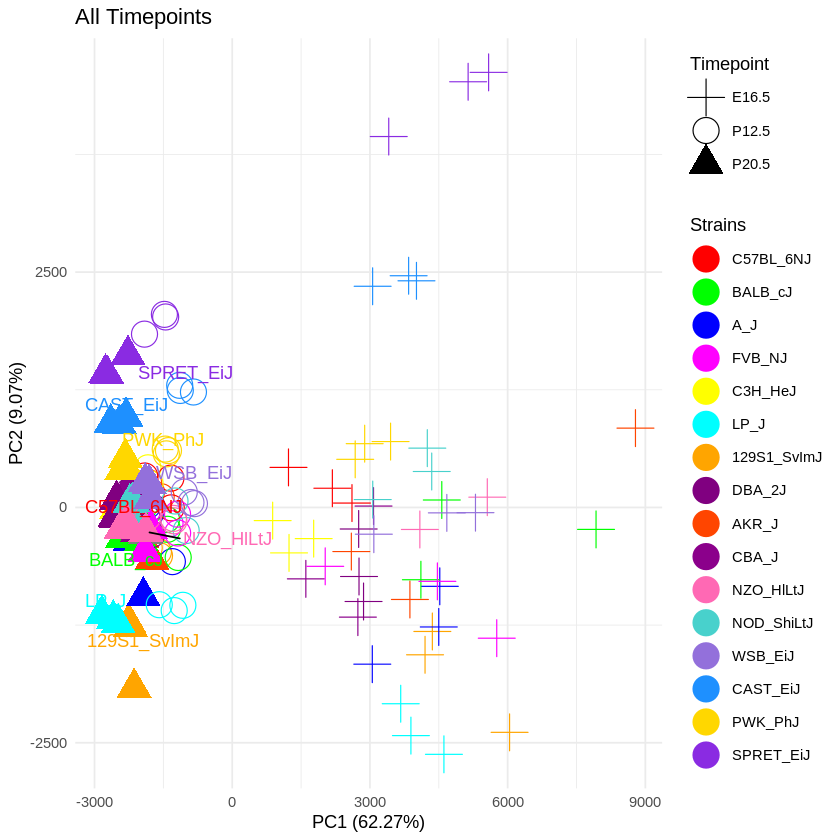

In [40]:

library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 7) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ", '129S1_SvImJ', 'BALB_cJ','LP_J','NZO_HlLtJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 2
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("all_timepoint_PC1_PC2.pdf", plot = pca_plot_pc1_pc2, width = 6, height = 7)

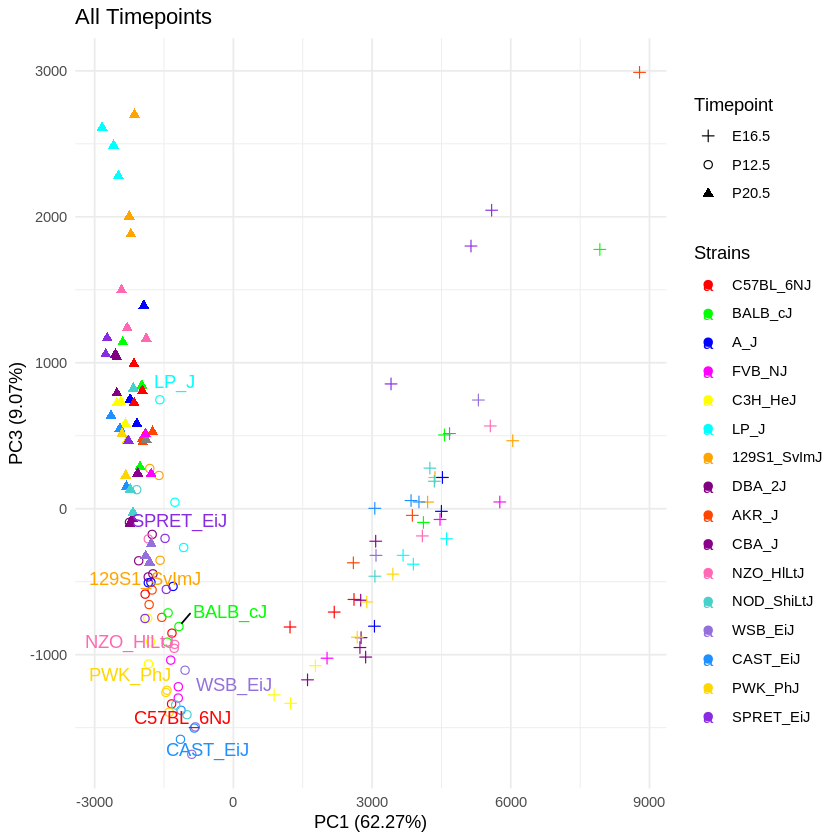

In [41]:

library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 2) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ", '129S1_SvImJ', 'BALB_cJ','LP_J','NZO_HlLtJ')
filtered_data <- pca_data %>% filter( Unique_Strains %in% selected_strains)
  #filter(Shape == "E16.5"   , Unique_Strains %in% selected_strains)


# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 2
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("all_timepoint_PC1_PC3.pdf", plot = pca_plot_pc1_pc2, width = 6, height = 7)

TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


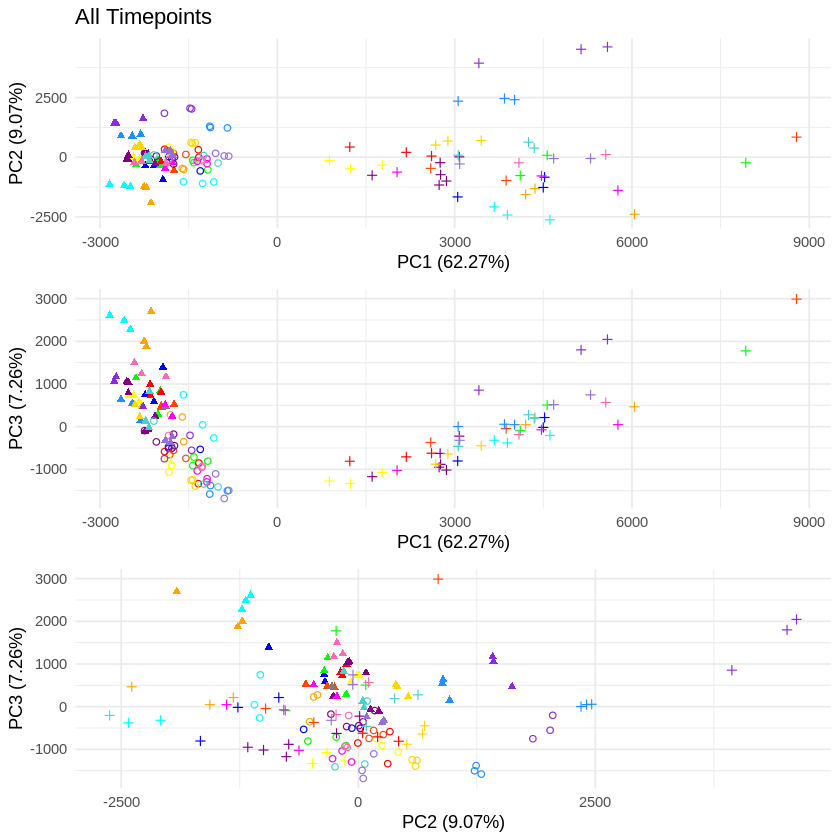

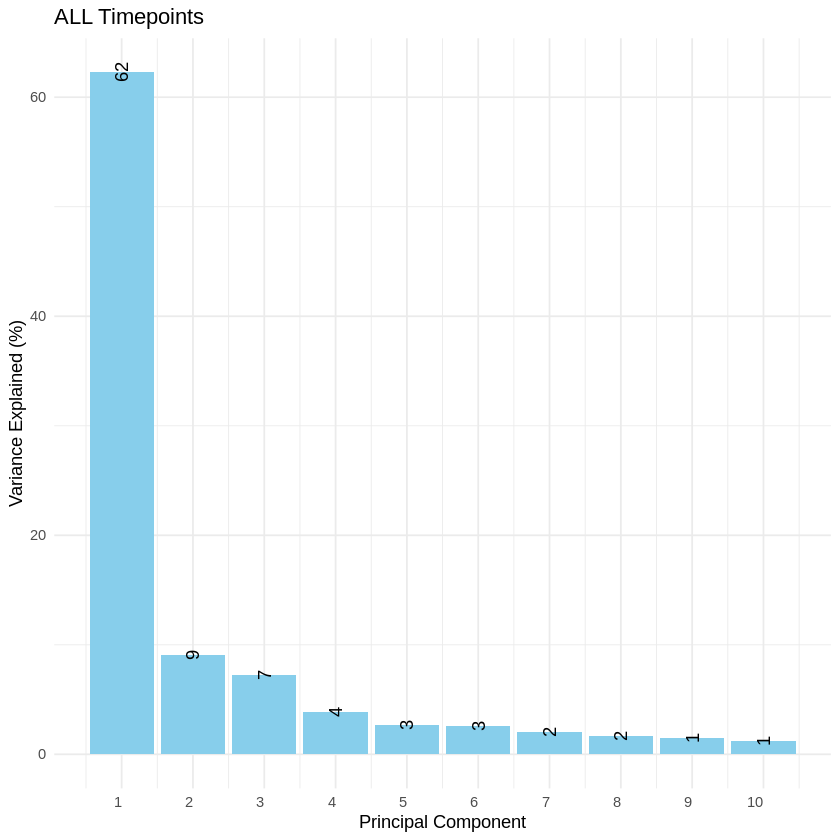

In [42]:



# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  labs(shape = "Timepoint") +
         labs(color = "Strains")  +  theme(legend.position = "none") 



pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme(legend.position = "none") 





# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("All_timepoints_deseq_PCA.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 , angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "ALL Timepoints",
       x = "Principal Component", y = "Variance Explained (%)") +
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +  # Set custom x-axis breaks
  theme(axis.text.x = element_text(angle = 0, hjust = 1))  # Rotate and allow overlap


# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("ALL_timepoints_variance_explained_bar_plot.pdf", variance_bar_plot, width = 2, height = 2, units = "in")

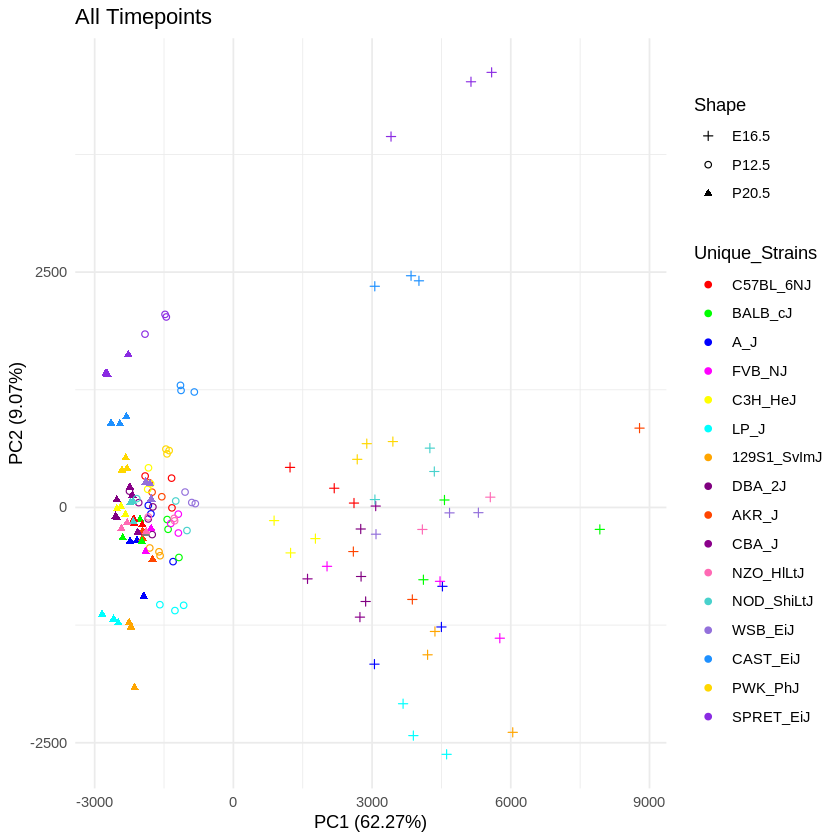

In [43]:
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) 
pca_plot_pc1_pc2

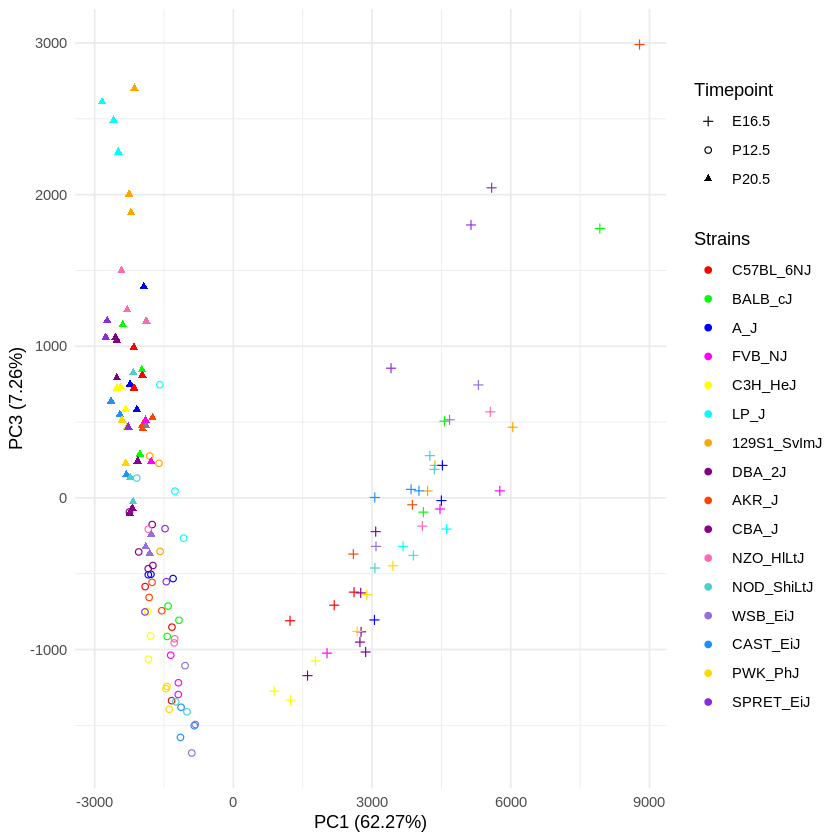

In [44]:
pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  labs(shape = "Timepoint") +
         labs(color = "Strains") 
pca_plot_pc1_pc3 

,Variable
,<chr>
0610007P14Rik,0610007P14Rik
0610009B22Rik,0610009B22Rik
0610010F05Rik,0610010F05Rik
0610010K14Rik,0610010K14Rik
0610037L13Rik,0610037L13Rik
0610040J01Rik,0610040J01Rik
1110002E22Rik,1110002E22Rik
1110004F10Rik,1110004F10Rik
1110008F13Rik,1110008F13Rik


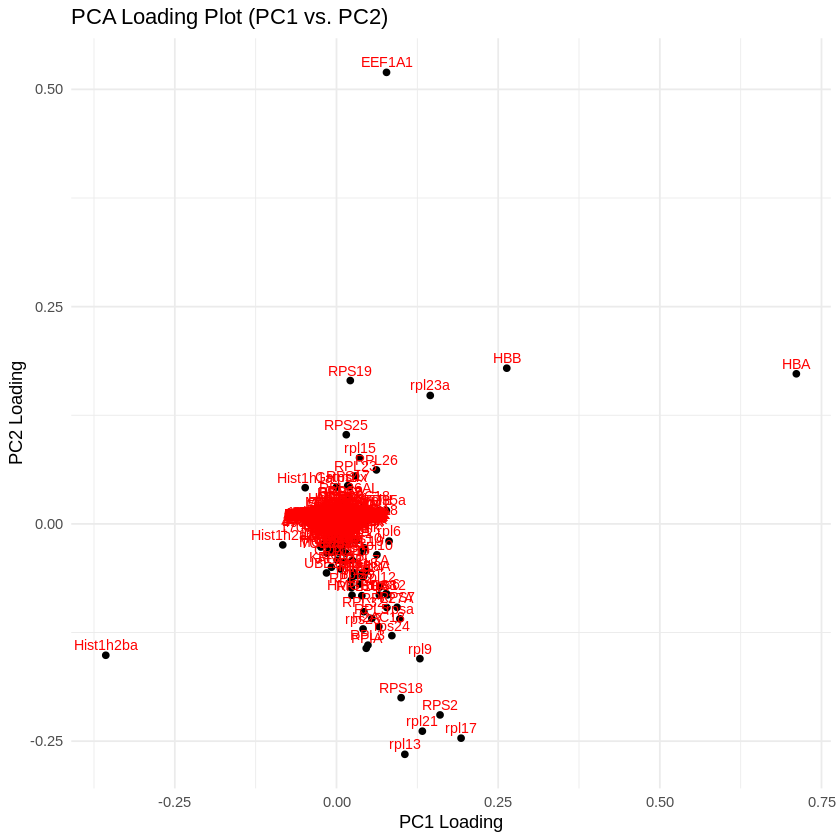

In [45]:
# Load required libraries
library(ggplot2)



# Perform PCA
pca_result <-  prcomp(t(norm_counts))

# Extract the loadings
loadings <- pca_result$rotation
write.csv(loadings, "all_sample_PCA_loading.csv", row.names=TRUE)
# Calculate the ranking of loadings for each PC
rankings <- apply(loadings, 2, rank)

# Create a data frame for plotting
loadings_df <- data.frame(
  Variable = rownames(loadings),
  PC1 = loadings[, 1],
  PC2 = loadings[, 2],
  Ranking_PC1 = rankings[, 1],
  Ranking_PC2 = rankings[, 2]
)
loadings_df['Variable']
# Sort the data frame by absolute values of PC1 loadings
loadings_df_pc1 <- loadings_df[order(abs(loadings_df$PC1), decreasing = TRUE),]



# Create a scatter plot of PC1 vs. PC2 loadings
ggplot(data = loadings_df, aes(x = PC1, y = PC2, label = Variable)) +
  geom_point() +
  geom_text(vjust = -0.5, size = 3, color = "red") +
  labs(title = "PCA Loading Plot (PC1 vs. PC2)", x = "PC1 Loading", y = "PC2 Loading") +
  theme_minimal()

,Variable
,<chr>
0610007P14Rik,0610007P14Rik
0610009B22Rik,0610009B22Rik
0610010F05Rik,0610010F05Rik
0610010K14Rik,0610010K14Rik
0610037L13Rik,0610037L13Rik
0610040J01Rik,0610040J01Rik
1110002E22Rik,1110002E22Rik
1110004F10Rik,1110004F10Rik
1110008F13Rik,1110008F13Rik


Warning message:
“ggrepel: 16946 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 16927 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


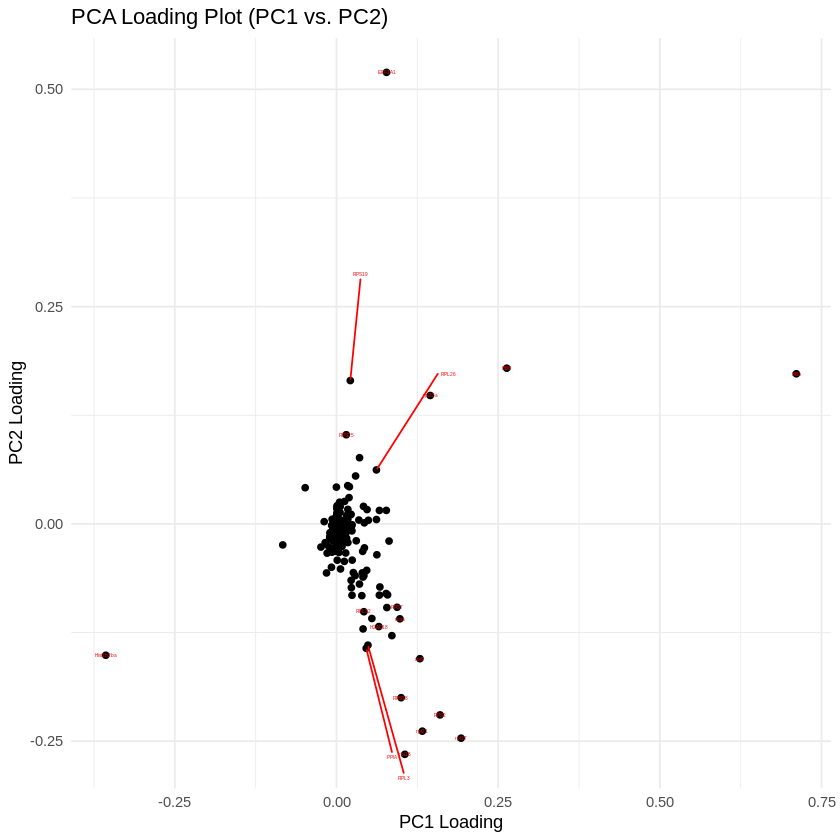

In [46]:
library(ggrepel)

# Load required libraries
library(ggplot2)



# Perform PCA
pca_result <-  prcomp(t(norm_counts))

# Extract the loadings
loadings <- pca_result$rotation

# Calculate the ranking of loadings for each PC
rankings <- apply(loadings, 2, rank)

# Create a data frame for plotting
loadings_df <- data.frame(
  Variable = rownames(loadings),
  PC1 = loadings[, 1],
  PC2 = loadings[, 2],
  Ranking_PC1 = rankings[, 1],
  Ranking_PC2 = rankings[, 2]
)

loadings_df['Variable']
# Create the scatter plot
plot <- ggplot(data = loadings_df, aes(x = PC1, y = PC2, label = Variable)) +
  geom_point() +
  geom_text_repel(
    size = 1,
    color = "red",
    box.padding = 0.1,
    force = 0.05  # Adjust the force parameter to control label dispersion
  ) +
  labs(title = "PCA Loading Plot (PC1 vs. PC2)", x = "PC1 Loading", y = "PC2 Loading") +
  theme_minimal()
plot
ggsave("all_timepoint_PC1_PC2_loading_full_scale.pdf", plot, width = 10, height =10 , units = "in")

In [47]:




selected_vars <- c('CTNNA2','SETX','HBB','Dnmt1','Sycp3','Dnmt3a','Dnmt3b','Dnmt3c','Dnmt3l','Meiob','Nanos2','Nanos3','Piwil1', 'Piwil2', 'Piwil4',
'Ddx4','Mael','Gtsf1','Mybl1','Mov10l1','Pld6','Asz1','Henmt1','Tdrd1','Tdrd5','Tdrd6','Tdrd9','Tdrd12', 'Tdrkh','Gpat2','Rnf17','Tcfl5','Tex15','Tex19.1','Tex19.2','Spocd1','Fkbp6')

# Extract loading scores for selected variables
selected_loading_df <- loadings_df[tolower(loadings_df$Variable) %in% tolower(selected_vars), ]
#selected_loading_df <- var.coord 

# Define the groups and their corresponding colors
group_colors <- c(
  'Marker Genes' = "#FF5733",  # Bright Orange
  'Piwi Genes' = "#7C36A3",  # Rich Purple
  'Piwi Pathways Genes' = "#3FA33F"   # Lively Green
)

# Create a new column in the data frame to indicate the group each variable belongs to
selected_loading_df$Group <- NA
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Dnmt1','Sycp3','Dnmt3a','Dnmt3b','Dnmt3c','Dnmt3l','Meiob','Nanos2','Nanos3'))] <- 'Marker Genes'
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Piwil1', 'Piwil2', 'Piwil4'))] <- 'Piwi Genes'
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Ddx4','Mael','Gtsf1','Mybl1','Mov10l1','Pld6','Asz1','Henmt1','Tdrd1','Tdrd5','Tdrd6','Tdrd9','Tdrd12', 'Tdrkh','Gpat2','Rnf17','Tcfl5','Tex15','Tex19.1','Tex19.2','Spocd1','Fkbp6'))] <- 'Piwi Pathways Genes'

# Create the scatter plot with labels and colored groups
plot<- ggplot(data = selected_loading_df, aes(x = PC1, y = PC2, label = Variable, color = Group)) +
  geom_point() +
  geom_text_repel(
    size = 3,
    box.padding = 0.5,
    force = 5,
    segment.color = "black"
  ) +
  labs(title = "PCA Loading Plot (PC1 vs. PC2)", x = "PC1 Loading", y = "PC2 Loading") +
  scale_color_manual(values = group_colors) +  # Set custom colors for groups
  theme_minimal()
ggsave("all_timepoint_PC1_PC2_loading_piwi_full_scale.pdf", plot, width = 10, height =6 , units = "in")

Warning message:
“ggrepel: 33 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [48]:

selected_vars <- c('Dnmt1','Sycp3','Dnmt3a','Dnmt3b','Dnmt3c','Dnmt3l','Meiob','Nanos2','Nanos3','Piwil1', 'Piwil2', 'Piwil4',
'Ddx4','Mael','Gtsf1','Mybl1','Mov10l1','Pld6','Asz1','Henmt1','Tdrd1','Tdrd5','Tdrd6','Tdrd9','Tdrd12', 'Tdrkh','Gpat2','Rnf17','Tcfl5','Tex15','Tex19.1','Tex19.2','Spocd1','Fkbp6')
# Extract loading scores for selected variables
selected_loading_df <- loadings_df[tolower(loadings_df$Variable) %in% tolower(selected_vars), ]
#selected_loading_df <- var.coord 

# Define the groups and their corresponding colors
group_colors <- c(
  'Marker Genes' = "#FF5733",  # Bright Orange
  'Piwi Genes' = "#7C36A3",  # Rich Purple
  'Piwi Pathways Genes' = "#3FA33F"   # Lively Green
)

# Create a new column in the data frame to indicate the group each variable belongs to
selected_loading_df$Group <- NA
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Dnmt1','Sycp3','Dnmt3a','Dnmt3b','Dnmt3c','Dnmt3l','Meiob','Nanos2','Nanos3'))] <- 'Marker Genes'
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Piwil1', 'Piwil2', 'Piwil4'))] <- 'Piwi Genes'
selected_loading_df$Group[tolower(selected_loading_df$Variable) %in% tolower(c('Ddx4','Mael','Gtsf1','Mybl1','Mov10l1','Pld6','Asz1','Henmt1','Tdrd1','Tdrd5','Tdrd6','Tdrd9','Tdrd12', 'Tdrkh','Gpat2','Rnf17','Tcfl5','Tex15','Tex19.1','Tex19.2','Spocd1','Fkbp6'))] <- 'Piwi Pathways Genes'

# Create the scatter plot with labels and colored groups
plot <- ggplot(data = selected_loading_df, aes(x = PC1, y = PC2, label = Variable, color = Group)) +
  geom_point() +
  geom_text_repel(
    size = 3,
    box.padding = 0.5,
    force = 5,
    segment.color = "black"
  ) +
  labs(title = "PCA Loading Plot (PC1 vs. PC2)", x = "PC1 Loading", y = "PC2 Loading") +
  scale_color_manual(values = group_colors) +  # Set custom colors for groups
  theme_minimal()
ggsave("all_timepoint_PC1_PC2_loading_piwi.pdf", plot, width = 10, height = 6, units = "in")


Warning message:
“ggrepel: 21 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


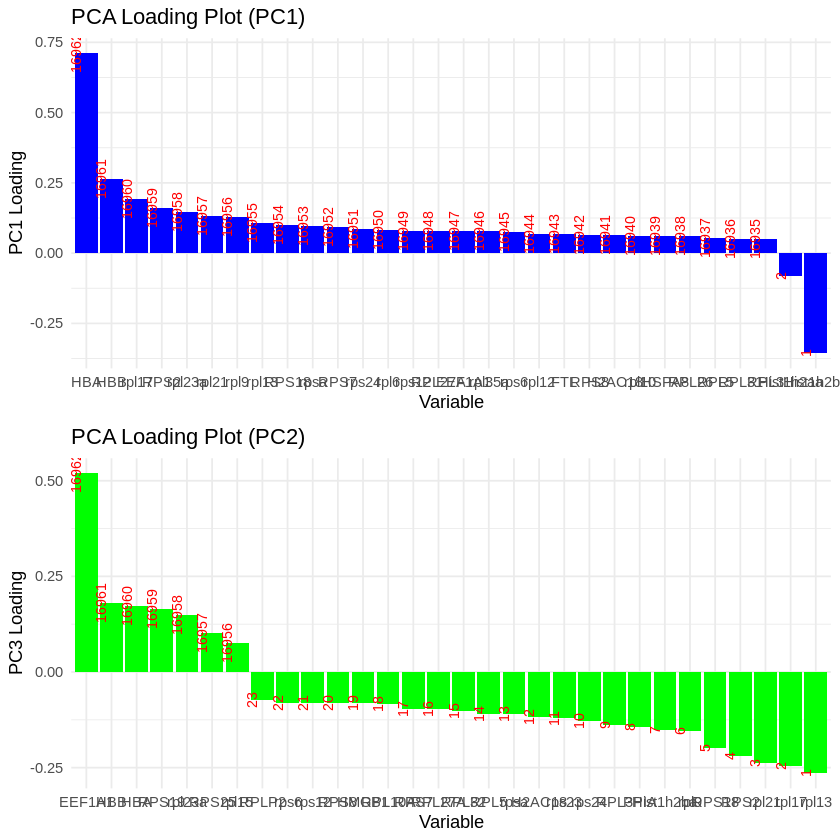

In [49]:
library(ggplot2)

# Perform PCA
pca_result <-  prcomp(t(norm_counts))

# Extract the loadings
loadings <- pca_result$rotation

# Calculate the ranking of loadings for each PC
rankings <- apply(loadings, 2, rank)

# Create a data frame for plotting
loadings_df <- data.frame(
  Variable = rownames(loadings),
  PC1 = loadings[, 1],
  PC2 = loadings[, 2],
  Ranking_PC1 = rankings[, 1],
  Ranking_PC2 = rankings[, 2]
)
# Sort the data frame by absolute values of PC1 loadings
loadings_df_pc1 <- loadings_df[order(abs(loadings_df$PC1), decreasing = TRUE),]

# Select the top 30 variables for PC1
loadings_df_pc1 <- head(loadings_df_pc1, 30)

# Create a bar plot for PC1 loadings with ranking
plot_pc1 <- ggplot(data = loadings_df_pc1, aes(x = reorder(Variable, -PC1), y = PC1)) +
  geom_bar(stat = "identity", fill = "blue") +
  geom_text(aes(x = Variable, y = PC1, label = Ranking_PC1), vjust = -0.5,angle = 90, size = 3, color = "red") +
  labs(title = "PCA Loading Plot (PC1)", x = "Variable", y = "PC1 Loading") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme_minimal()

# Sort the data frame by absolute values of PC2 loadings
loadings_df_pc2 <- loadings_df[order(abs(loadings_df$PC2), decreasing = TRUE),]

# Select the top 30 variables for PC2
loadings_df_pc2 <- head(loadings_df_pc2, 30)

# Create a bar plot for PC2 loadings with ranking
plot_pc2 <- ggplot(data = loadings_df_pc2, aes(x = reorder(Variable, -PC2), y = PC2)) +
  geom_bar(stat = "identity", fill = "green") +
  geom_text(aes(x = Variable, y = PC2, label = Ranking_PC2),angle = 90, vjust = -0.5, size = 3, color = "red") +
  labs(title = "PCA Loading Plot (PC2)", x = "Variable", y = "PC3 Loading") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))+
  theme_minimal()

# Combine the two plots using grid.arrange
grid.arrange(plot_pc1, plot_pc2, ncol = 1)


In [50]:
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color =Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 
ggsave("ALL_timepoints_P1_vs_PC2.pdf", pca_plot_pc1_pc2, width = 10, height = 10, units = "in")

Warning message in geom_text_repel(data = filtered_data %>% distinct(Unique_Strains, :
“Ignoring unknown parameters: `jitter`”


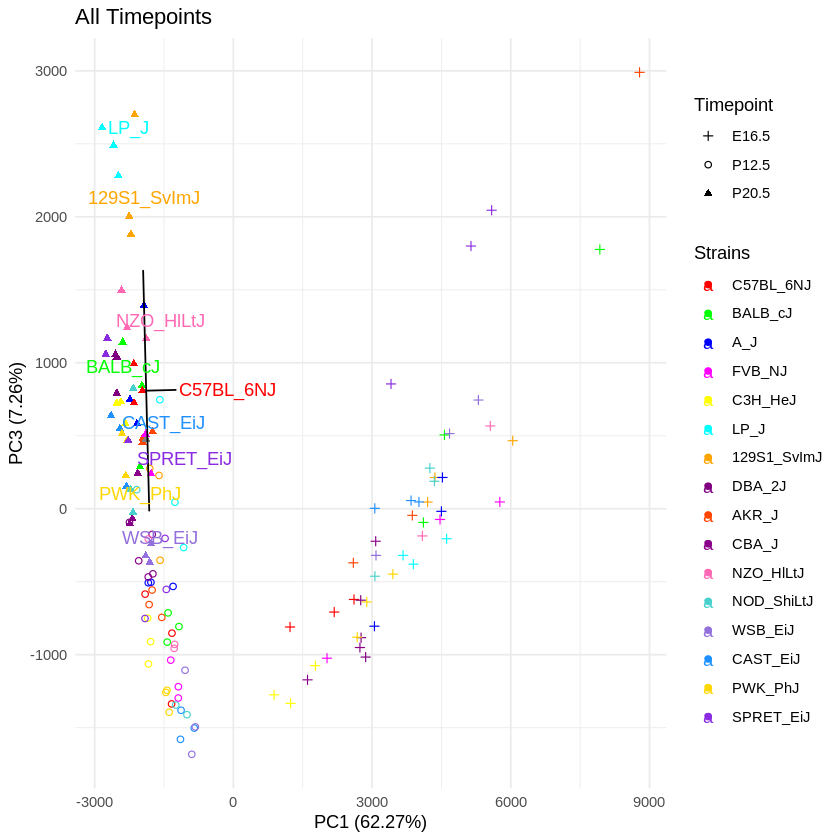

In [51]:
library(dplyr)


pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
 geom_point() +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ", '129S1_SvImJ', 'BALB_cJ','LP_J','NZO_HlLtJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4

pca_plot_pc1_pc3 <- pca_plot_pc1_pc3 +geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 5, nudge_y = 5,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    jitter = jitter_amount,force=5
  )
pca_plot_pc1_pc3

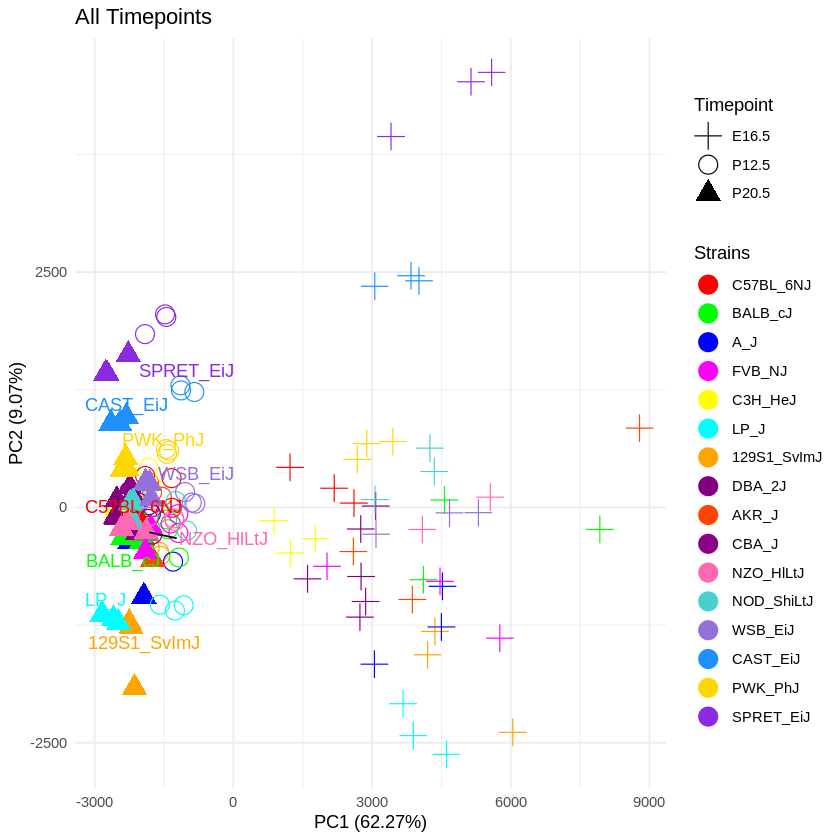

In [52]:

library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ", '129S1_SvImJ', 'BALB_cJ','LP_J','NZO_HlLtJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 10
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("all_timepoint_PC1_PC2.pdf", plot = pca_plot_pc1_pc2, width = 20, height = 20)

Warning message in geom_label_repel(data = filtered_data %>% distinct(Unique_Strains, :
“Ignoring unknown parameters: `label.box`”


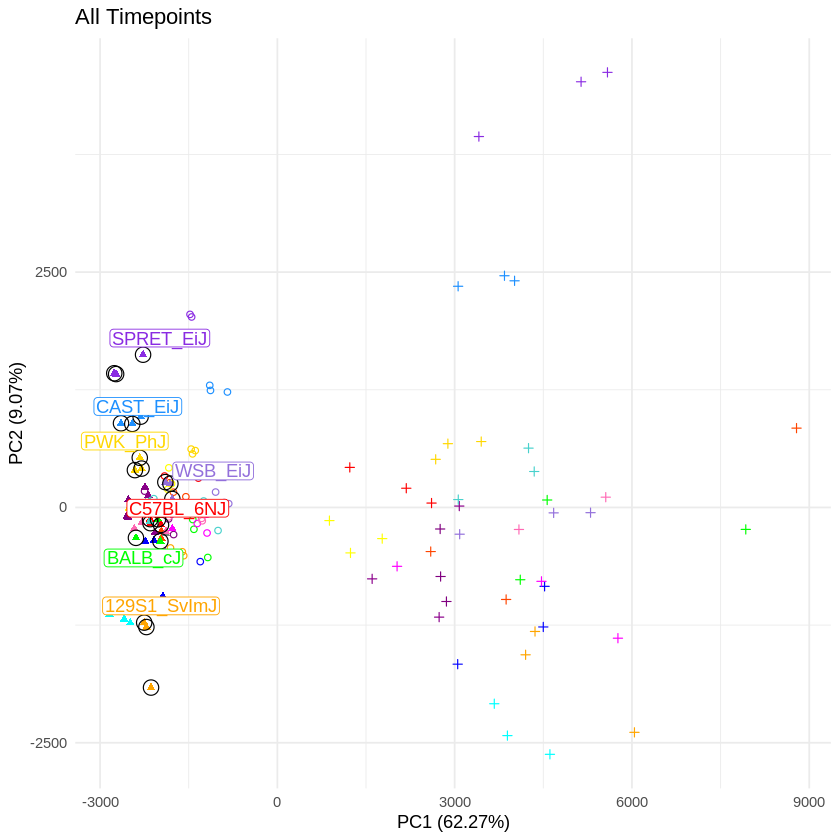

In [53]:
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") + 
  theme(legend.position = "none") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ",'129S1_SvImJ','BALB_cJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)

# Create the PCA plot with labeled selected strains and wrapped labels
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_point(data = filtered_data, shape = 1, size = 4, color = "black") +
  geom_label_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),  # Keep only one instance of each strain
    aes(label = Unique_Strains),
    nudge_x = 0.4,  # Adjust the label positions slightly
    segment.color = "black", 
    arrow = arrow(type = "closed", angle = 20, length = unit(0.15, "inches")),
    label.padding = unit(0.1, "lines"),  # Adjust the padding around the label
    label.box = "bottom"  # Place the label in a box below the point
  ) +
  guides(values = guide_legend(override.aes = list(values = 1)))

# Print the modified PCA plot
print(pca_plot_pc1_pc2)


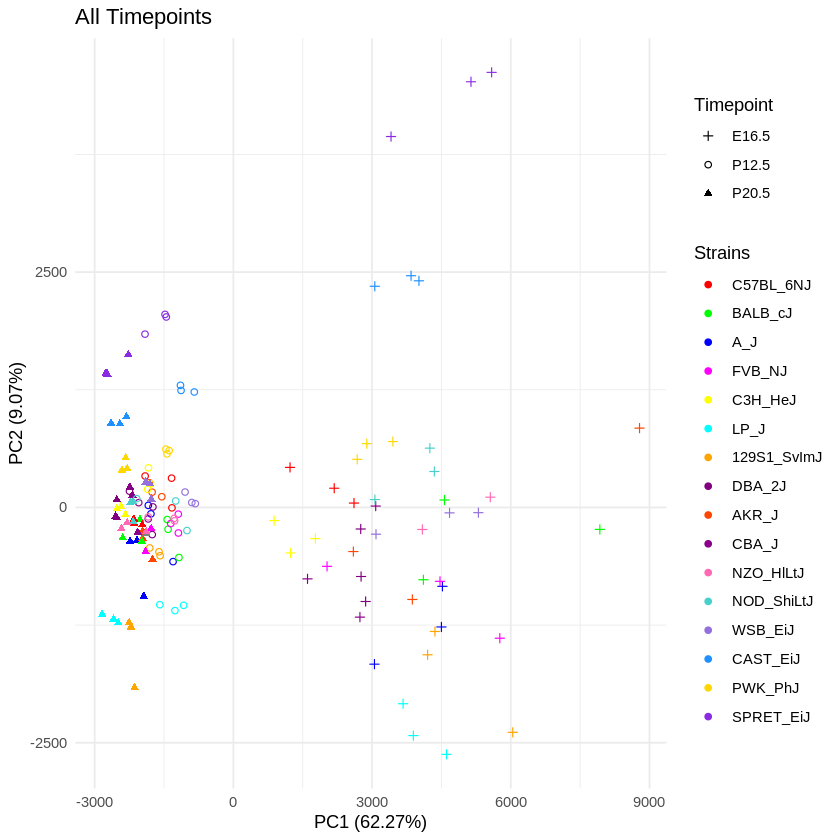

In [54]:
library(ggplot2)
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  labs(shape = "Timepoint") +
         labs(color = "Strains") 
pca_plot_pc1_pc2

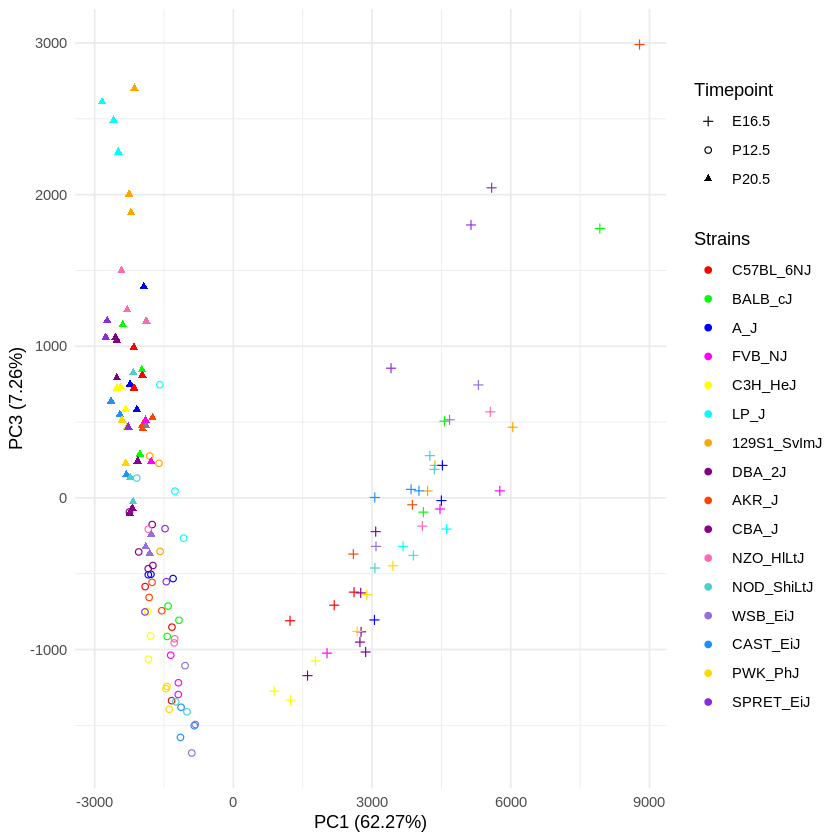

In [55]:
pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
       scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  labs(shape = "Timepoint") +
         labs(color = "Strains") +
      theme_minimal() 
pca_plot_pc1_pc3

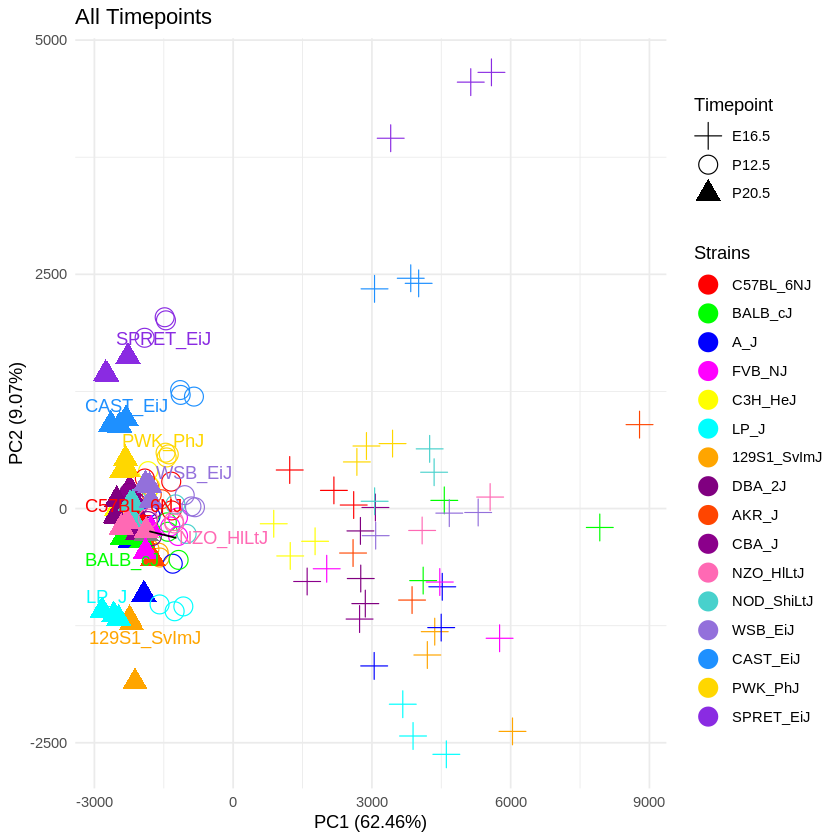

In [56]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Calculate the row-wise variance and order rows by variance
#row_variances <- apply(norm_counts, 1, var)
#top_variants <- names(sort(row_variances, decreasing = TRUE))[1:500] #top 500 
#subset_norm_counts <- norm_counts[top_variants, ]


# Calculate the row-wise sum and order rows by sum
row_sums <- apply(norm_counts, 1, sum)
top_sums <- names(sort(row_sums, decreasing = TRUE))[1:500] #top 500 
subset_norm_counts <- norm_counts[top_sums, ]
# Perform PCA on the subsetted data
pca <- prcomp(t(subset_norm_counts))

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100






# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = samplenames,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P12.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])


library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ", '129S1_SvImJ', 'BALB_cJ','LP_J','NZO_HlLtJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 10
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("all_timepoint_PC1_PC2_500_expresed.pdf", plot = pca_plot_pc1_pc2, width = 6, height = 6)

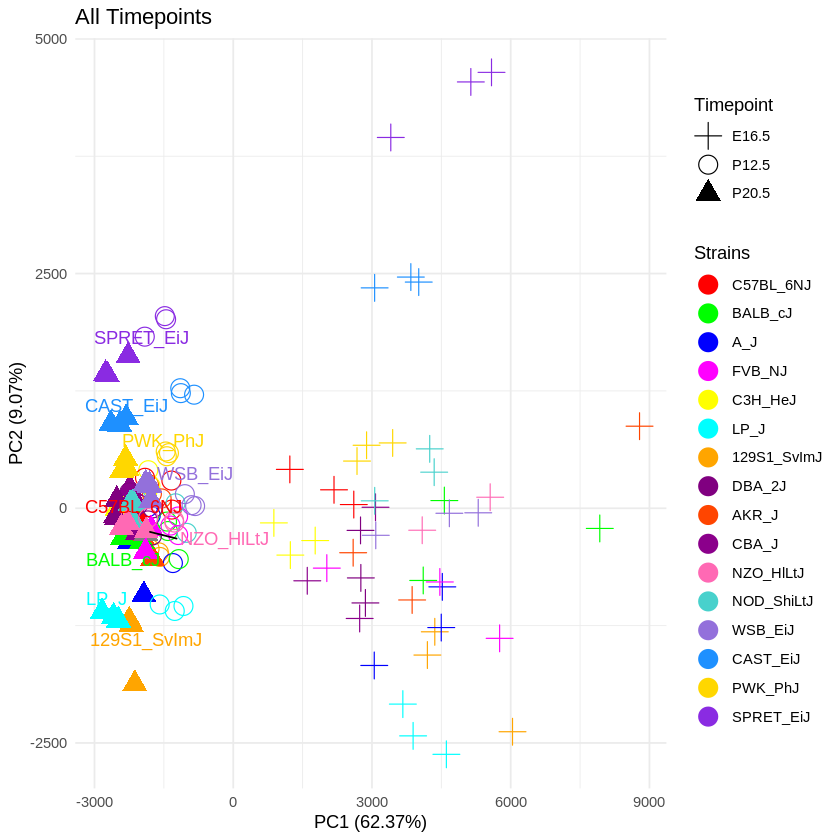

In [57]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Calculate the row-wise variance and order rows by variance
row_variances <- apply(norm_counts, 1, var)
top_variants <- names(sort(row_variances, decreasing = TRUE))[1:500] #top 500 
subset_norm_counts <- norm_counts[top_variants, ]


# Calculate the row-wise sum and order rows by sum
#row_sums <- apply(norm_counts, 1, sum)
#top_sums <- names(sort(row_sums, decreasing = TRUE))[1:500] #top 500 
#subset_norm_counts <- norm_counts[top_sums, ]
# Perform PCA on the subsetted data
pca <- prcomp(t(subset_norm_counts))

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100






# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = samplenames,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P12.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])


library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains") 

# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "C57BL_6NJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ", '129S1_SvImJ', 'BALB_cJ','LP_J','NZO_HlLtJ')
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 10
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("all_timepoint_PC1_PC2_500_var.pdf", plot = pca_plot_pc1_pc2, width = 10, height = 10)

TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


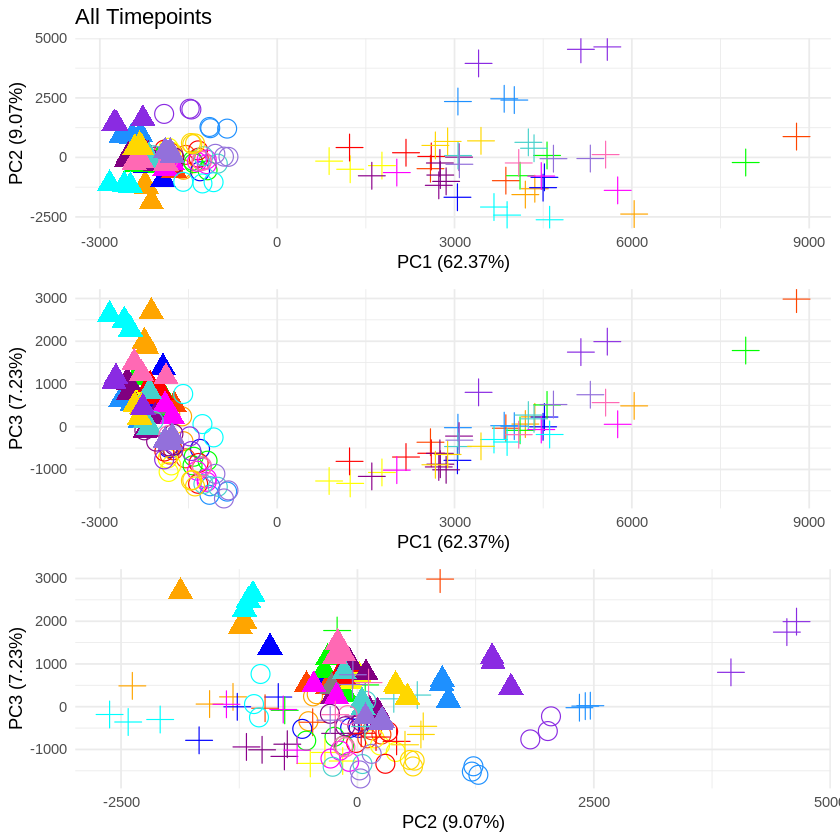

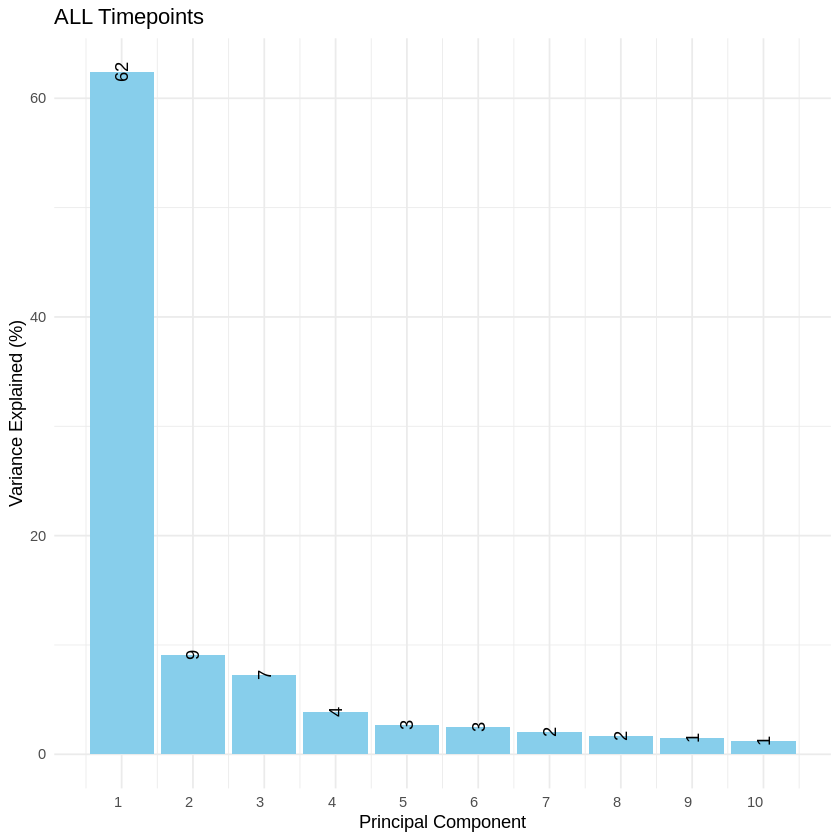

In [58]:



# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme(legend.position = "none") 


pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point(size = 5) +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  theme_minimal() +scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme(legend.position = "none") 



# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("All_timepoints_edgeR_PCA_500.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 , angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "ALL Timepoints",
       x = "Principal Component", y = "Variance Explained (%)") +
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +  # Set custom x-axis breaks
  theme(axis.text.x = element_text(angle = 0, hjust = 1))  # Rotate and allow overlap


# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("ALL_timepoints_variance_explained_bar_plot_500.pdf", variance_bar_plot, width = 3, height = 4, units = "in")

In [59]:
colnames(rawdata_copy$counts)

[1] "129S1_SvImJ-P12.5.1" "129S1_SvImJ-P12.5.2" "129S1_SvImJ-P12.5.3"
  [4] "129S1_SvImJ-E16.5.1" "129S1_SvImJ-E16.5.2" "129S1_SvImJ-E16.5.3"
  [7] "129S1_SvImJ-P20.5.1" "129S1_SvImJ-P20.5.2" "129S1_SvImJ-P20.5.3"
 [10] "A_J-P12.5.1"         "A_J-P12.5.2"         "A_J-P12.5.3"        
 [13] "A_J-E16.5.1"         "A_J-E16.5.2"         "A_J-E16.5.3"        
 [16] "A_J-P20.5.1"         "A_J-P20.5.2"         "A_J-P20.5.3"        
 [19] "AKR_J-P12.5.1"       "AKR_J-P12.5.2"       "AKR_J-P12.5.3"      
 [22] "AKR_J-E16.5.1"       "AKR_J-E16.5.2"       "AKR_J-E16.5.3"      
 [25] "AKR_J-P20.5.1"       "AKR_J-P20.5.2"       "AKR_J-P20.5.3"      
 [28] "BALB_cJ-P12.5.1"     "BALB_cJ-P12.5.2"     "BALB_cJ-P12.5.3"    
 [31] "BALB_cJ-E16.5.1"     "BALB_cJ-E16.5.2"     "BALB_cJ-E16.5.3"    
 [34] "BALB_cJ-P20.5.1"     "BALB_cJ-P20.5.2"     "BALB_cJ-P20.5.3"    
 [37] "C3H_HeJ-P12.5.1"     "C3H_HeJ-P12.5.2"     "C3H_HeJ-P12.5.3"    
 [40] "C3H_HeJ-E16.5.1"     "C3H_HeJ-E16.5.2"     "C3H_HeJ-E16.5.3"    
 [43] "C3H_HeJ-P20.5.1"     "C3H_HeJ-P20.5.2"     "C3H_HeJ-P20.5.3"    
 [46] "C57BL_6NJ-P12.5.1"   "C57BL_6NJ-P12.5.2"   "C57BL_6NJ-P12.5.3"  
 [49] "C57BL_6NJ-E16.5.1"   "C57BL_6NJ-E16.5.2"   "C57BL_6NJ-E16.5.3"  
 [52] "C57BL_6NJ-P20.5.1"   "C57BL_6NJ-P20.5.2"   "C57BL_6NJ-P20.5.3"  
 [55] "CAST_EiJ-P12.5.1"    "CAST_EiJ-P12.5.2"    "CAST_EiJ-P12.5.3"   
 [58] "CAST_EiJ-E16.5.1"    "CAST_EiJ-E16.5.2"    "CAST_EiJ-E16.5.3"   
 [61] "CAST_EiJ-P20.5.1"    "CAST_EiJ-P20.5.2"    "CAST_EiJ-P20.5.3"   
 [64] "CBA_J-P12.5.1"       "CBA_J-P12.5.3"       "CBA_J-E16.5.1"      
 [67] "CBA_J-E16.5.2"       "CBA_J-E16.5.3"       "CBA_J-P20.5.1"      
 [70] "CBA_J-P20.5.2"       "CBA_J-P20.5.3"       "DBA_2J-P12.5.1"     
 [73] "DBA_2J-P12.5.2"      "DBA_2J-P12.5.3"      "DBA_2J-E16.5.1"     
 [76] "DBA_2J-E16.5.2"      "DBA_2J-E16.5.3"      "DBA_2J-P20.5.1"     
 [79] "DBA_2J-P20.5.2"      "DBA_2J-P20.5.3"      "FVB_NJ-P12.5.1"     
 [82] "FVB_NJ-P12.5.2"      "FVB_NJ-P12.5.3"      "FVB_NJ-E16.5.1"     
 [85] "FVB_NJ-E16.5.2"      "FVB_NJ-E16.5.3"      "FVB_NJ-P20.5.1"     
 [88] "FVB_NJ-P20.5.2"      "FVB_NJ-P20.5.3"      "LP_J-P12.5.1"       
 [91] "LP_J-P12.5.2"        "LP_J-P12.5.3"        "LP_J-E16.5.1"       
 [94] "LP_J-E16.5.2"        "LP_J-E16.5.3"        "LP_J-P20.5.1"       
 [97] "LP_J-P20.5.2"        "LP_J-P20.5.3"        "NOD_ShiLtJ-P12.5.1" 
[100] "NOD_ShiLtJ-P12.5.2"  "NOD_ShiLtJ-P12.5.3"  "NOD_ShiLtJ-E16.5.1" 
[103] "NOD_ShiLtJ-E16.5.2"  "NOD_ShiLtJ-E16.5.3"  "NOD_ShiLtJ-P20.5.1" 
[106] "NOD_ShiLtJ-P20.5.2"  "NOD_ShiLtJ-P20.5.3"  "NZO_HlLtJ-P12.5.1"  
[109] "NZO_HlLtJ-P12.5.2"   "NZO_HlLtJ-P12.5.3"   "NZO_HlLtJ-E16.5.1"  
[112] "NZO_HlLtJ-E16.5.3"   "NZO_HlLtJ-P20.5.1"   "NZO_HlLtJ-P20.5.2"  
[115] "NZO_HlLtJ-P20.5.3"   "PWK_PhJ-P12.5.1"     "PWK_PhJ-P12.5.2"    
[118] "PWK_PhJ-P12.5.3"     "PWK_PhJ-E16.5.1"     "PWK_PhJ-E16.5.2"    
[121] "PWK_PhJ-E16.5.3"     "PWK_PhJ-P20.5.1"     "PWK_PhJ-P20.5.2"    
[124] "PWK_PhJ-P20.5.3"     "SPRET_EiJ-P12.5.1"   "SPRET_EiJ-P12.5.2"  
[127] "SPRET_EiJ-P12.5.3"   "SPRET_EiJ-E16.5.1"   "SPRET_EiJ-E16.5.2"  
[130] "SPRET_EiJ-E16.5.3"   "SPRET_EiJ-P20.5.1"   "SPRET_EiJ-P20.5.2"  
[133] "SPRET_EiJ-P20.5.3"   "WSB_EiJ-P12.5.1"     "WSB_EiJ-P12.5.2"    
[136] "WSB_EiJ-P12.5.3"     "WSB_EiJ-E16.5.1"     "WSB_EiJ-E16.5.2"    
[139] "WSB_EiJ-E16.5.3"     "WSB_EiJ-P20.5.1"     "WSB_EiJ-P20.5.2"    
[142] "WSB_EiJ-P20.5.3"

In [60]:


pairwise_combinations <- list(
  # E16.5 vs P12.5
  c('sample', 'C57BL_6NJ-E16.5', 'C57BL_6NJ-P12.5'),
  c('sample', 'BALB_cJ-E16.5', 'BALB_cJ-P12.5'),
  c('sample', 'A_J-E16.5', 'A_J-P12.5'),
  c('sample', 'FVB_NJ-E16.5', 'FVB_NJ-P12.5'),
  c('sample', 'C3H_HeJ-E16.5', 'C3H_HeJ-P12.5'),
  c('sample', 'LP_J-E16.5', 'LP_J-P12.5'),
  c('sample', '129S1_SvImJ-E16.5', '129S1_SvImJ-P12.5'),
  c('sample', 'DBA_2J-E16.5', 'DBA_2J-P12.5'),
  c('sample', 'AKR_J-E16.5', 'AKR_J-P12.5'),
  c('sample', 'CBA_J-E16.5', 'CBA_J-P12.5'),
  c('sample', 'NZO_HlLtJ-E16.5', 'NZO_HlLtJ-P12.5'),
  c('sample', 'NOD_ShiLtJ-E16.5', 'NOD_ShiLtJ-P12.5'),
  c('sample', 'WSB_EiJ-E16.5', 'WSB_EiJ-P12.5'),
  c('sample', 'CAST_EiJ-E16.5', 'CAST_EiJ-P12.5'),
  c('sample', 'PWK_PhJ-E16.5', 'PWK_PhJ-P12.5'),
  c('sample', 'SPRET_EiJ-E16.5', 'SPRET_EiJ-P12.5'),
  
  # P12.5 vs P20.5
  c('sample', 'C57BL_6NJ-P12.5', 'C57BL_6NJ-P20.5'),
  c('sample', 'BALB_cJ-P12.5', 'BALB_cJ-P20.5'),
  c('sample', 'A_J-P12.5', 'A_J-P20.5'),
  c('sample', 'FVB_NJ-P12.5', 'FVB_NJ-P20.5'),
  c('sample', 'C3H_HeJ-P12.5', 'C3H_HeJ-P20.5'),
  c('sample', 'LP_J-P12.5', 'LP_J-P20.5'),
  c('sample', '129S1_SvImJ-P12.5', '129S1_SvImJ-P20.5'),
  c('sample', 'DBA_2J-P12.5', 'DBA_2J-P20.5'),
  c('sample', 'AKR_J-P12.5', 'AKR_J-P20.5'),
  c('sample', 'CBA_J-P12.5', 'CBA_J-P20.5'),
  c('sample', 'NZO_HlLtJ-P12.5', 'NZO_HlLtJ-P20.5'),
  c('sample', 'NOD_ShiLtJ-P12.5', 'NOD_ShiLtJ-P20.5'),
  c('sample', 'WSB_EiJ-P12.5', 'WSB_EiJ-P20.5'),
  c('sample', 'CAST_EiJ-P12.5', 'CAST_EiJ-P20.5'),
  c('sample', 'PWK_PhJ-P12.5', 'PWK_PhJ-P20.5'),
  c('sample', 'SPRET_EiJ-P12.5', 'SPRET_EiJ-P20.5')
)

# Load required libraries
library(foreach)
library(doParallel)
library(EnhancedVolcano)  # Make sure you have this package installed

# Create a directory to save the plots
if (!dir.exists("volcano_plots")) {
    dir.create("volcano_plots")
}
# Combine results from all comparisons

library(edgeR)
library(EnhancedVolcano)
library(tidyverse)
library(DESeq2)
library(ggrepel)
library(kableExtra)

# Combine results from all comparisons
all_results <- data.frame()

# Loop through pairwise combinations
for (pair in pairwise_combinations) {
  condition1 <- pair[2]
  condition2 <- pair[3]
  
res <- results(cds, contrast = pair)
#res <- results(cds, contrast = c('sample', 'C57BL_6NJ-P20.5', 'BALB_cJ-P20.5'))
res

data <- data.frame(Genes = rownames(res),
                    logFC = res$log2FoldChange,
                     FDR = res$padj,
                     PValue = res$pvalue)

data <- data %>% 
    mutate(
      Expression = case_when(logFC >= log(2) & FDR <= 0.0001 ~ "Up-regulated",
                            logFC <= -log(2) & FDR <= 0.0001 ~ "Down-regulated",
                            TRUE ~ "Unchanged")
      )
data <- data %>% 
      mutate(
        Significance = case_when(
          abs(logFC) >= log(2) & FDR <= 0.05 & FDR > 0.01 ~ "FDR 0.05", 
          abs(logFC) >= log(2) & FDR <= 0.01 & FDR > 0.001 ~ "FDR 0.01",
          abs(logFC) >= log(2) & FDR <= 0.0001 ~ "FDR 0.0001", 
          TRUE ~ "Unchanged")
      )


all_genes <- bind_rows(
      data %>% 
        filter(Expression == 'Up-regulated') %>% 
        arrange(FDR, desc(abs(logFC))),
      data %>% 
        filter(Expression == 'Down-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) 
    )


comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
all_results <- rbind(all_results, data.frame(Comparison = comparison_name,
                                                Expression = all_genes$Expression,
                                                Significance = all_genes$Significance,
                                                Genes = all_genes$Genes))
p2 <- ggplot(data, aes(logFC, -log(FDR,10))) +
      geom_point(aes(color = Expression), size = 2/5) +
      xlab(expression("log"[2]*"FC")) + 
      ylab(expression("-log"[10]*"FDR")) +
      scale_color_manual(values = c("dodgerblue3", "gray50", "firebrick3")) +
      guides(colour = guide_legend(override.aes = list(size=1.5)))  + theme_minimal()
p2 <-  p2 +
      geom_label_repel(
    data = all_genes[1:5,],
    mapping = aes(logFC, -log(FDR, 10), label = Genes),
    size = 2,
    box.padding = 0.2,
    point.padding = 0.5,
    segment.color = "grey50",
    segment.size = 0.5,
    box.draw = FALSE,  # Remove the box around labels
    label.size = NA,  # Show only the label text without background
    label.background = aes(fill = NA)  # Set the label background to transparent
  ) +
  theme(plot.title = element_text(hjust = 0.7))  +  # Center the plot title
  ggtitle(paste("vs", condition2))
 # Save the plot as a PDF file
    pdf(paste("volcano_plots/", condition1, "_vs_", condition2, "_up_down_volcano_plot.pdf", sep = ""), width = 3, height = 3)  # Adjust width and height as needed
    print(p2)
    dev.off()  # Close the PDF device

p3 <- ggplot(data, aes(logFC, -log(FDR,10))) +
      geom_point(aes(color = Significance), size = 2/5) +
      xlab(expression("log"[2]*"FC")) + 
      ylab(expression("-log"[10]*"FDR")) +
      scale_color_viridis_d() +
      guides(colour = guide_legend(override.aes = list(size=1.5))) +theme_minimal()
p3 <- p3 +
  geom_label_repel(
    data = all_genes[1:5,],
    mapping = aes(logFC, -log(FDR, 10), label = Genes),
    size = 2,
    box.padding = 0.2,
    point.padding = 0.5,
    segment.color = "grey50",
    segment.size = 0.5,
    box.draw = FALSE,  # Remove the box around labels
    label.size = NA,  # Show only the label text without background
    label.background = aes(fill = NA)  # Set the label background to transparent
  ) +
  theme(plot.title = element_text(hjust = 0.7))  +  # Center the plot title
  ggtitle(paste("vs", condition2))
    # Save the plot as a PDF file
    pdf(paste("volcano_plots/", condition1, "_vs_", condition2, "_singnificant_volcano_plot.pdf", sep = ""), width = 3, height = 3)  # Adjust width and height as needed
    print(p3)
    dev.off() 



}



Attaching package: ‘foreach’


The following objects are masked from ‘package:purrr’:

    accumulate, when


Loading required package: iterators

Loading required package: parallel


Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows




ERROR: Error in eval(expr, envir, enclos): object 'cds' not found


In [ ]:
# Combine top_genes data from all comparisons
combined_top_genes <-  all_results
combined_top_genes



Comparison,Expression,Significance,Genes
<chr>,<chr>,<chr>,<chr>
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,MEST
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,FNDC4
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,TRPM5
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,VSTM2B
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,TINAGL1
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,CAND2
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,NRN1
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,KANK4
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,CXCL12


In [ ]:
library(ggplot2)
library(patchwork)

pair_sets <- c(
  "C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5",
  "BALB_cJ-E16.5_vs_BALB_cJ-P12.5",
  "A_J-E16.5_vs_A_J-P12.5",
  "FVB_NJ-E16.5_vs_FVB_NJ-P12.5",
  "C3H_HeJ-E16.5_vs_C3H_HeJ-P12.5",
  'LP_J-E16.5_vs_LP_J-P12.5',
  "129S1_SvImJ-E16.5_vs_129S1_SvImJ-P12.5",
  "DBA_2J-E16.5_vs_DBA_2J-P12.5",
  "AKR_J-E16.5_vs_AKR_J-P12.5",
  "CBA_J-E16.5_vs_CBA_J-P12.5",
  'NZO_HlLtJ-E16.5_vs_NZO_HlLtJ-P12.5',
  "NOD_ShiLtJ-E16.5_vs_NOD_ShiLtJ-P12.5",
  "WSB_EiJ-E16.5_vs_WSB_EiJ-P12.5",
  "CAST_EiJ-E16.5_vs_CAST_EiJ-P12.5",
  "PWK_PhJ-E16.5_vs_PWK_PhJ-P12.5",
  "SPRET_EiJ-E16.5_vs_SPRET_EiJ-P12.5",
  "C57BL_6NJ-P12.5_vs_C57BL_6NJ-P20.5",
  "BALB_cJ-P12.5_vs_BALB_cJ-P20.5",
  "A_J-P12.5_vs_A_J-P20.5",
  "FVB_NJ-P12.5_vs_FVB_NJ-P20.5",
  "C3H_HeJ-P12.5_vs_C3H_HeJ-P20.5",
  'LP_J-P12.5_vs_LP_J-P20.5',
  "129S1_SvImJ-P12.5_vs_129S1_SvImJ-P20.5",
  "DBA_2J-P12.5_vs_DBA_2J-P20.5",
  "AKR_J-P12.5_vs_AKR_J-P20.5",
  "CBA_J-P12.5_vs_CBA_J-P20.5",
  'NZO_HlLtJ-P12.5_vs_NZO_HlLtJ-P20.5',
  "NOD_ShiLtJ-P12.5_vs_NOD_ShiLtJ-P20.5",
  "WSB_EiJ-P12.5_vs_WSB_EiJ-P20.5",
  "CAST_EiJ-P12.5_vs_CAST_EiJ-P20.5",
  "PWK_PhJ-P12.5_vs_PWK_PhJ-P20.5",
  "SPRET_EiJ-P12.5_vs_SPRET_EiJ-P20.5"
)


# Summarize the data for plotting
summary_data <- all_results %>%
  group_by(Comparison, Expression) %>%
  tally() %>%
  spread(key = Expression, value = n, fill = 0)
summary_data
# Create separate plots for upregulated and downregulated genes
upregulated_plot <- ggplot(summary_data, aes(x = factor(Comparison, levels = pair_sets), y = `Up-regulated`, fill = "Up-regulated")) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Up-regulated" = "blue")) +
  xlab("Pair Comparison") +
  ylab("#  Genes") +
  ggtitle("# of Significant Up-regulated Genes") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1),
        legend.title = element_blank(),
        legend.position = "bottom")+
  geom_text(aes(y = `Up-regulated`, label = `Up-regulated`),angle = 90, vjust = 0.5,hjust=-0.1, size = 3, color = "black",nudge_y = 5)

downregulated_plot <- ggplot(summary_data, aes(x = factor(Comparison, levels = pair_sets), y = `Down-regulated`, fill = "Down-regulated")) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Down-regulated" = "red")) +
  xlab("Pair Comparison") +
  ylab("# Genes") +
  ggtitle("# of Significant Down-regulated Genes") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1),
        legend.title = element_blank(),
        legend.position = "bottom") +
  geom_text(aes(y = `Down-regulated`, label = `Down-regulated`),angle = 90, vjust = 0.5,hjust=-0.1, size = 3, color = "black",nudge_y = 5)



# Print the separate plots
# Open a PDF device to save the plot
pdf("All_timepoint_upreglated_count_bar_plot.pdf", width = 15, height = 6)  # Adjust width and height as needed
print(upregulated_plot)
dev.off()
pdf("All_timepoint_downreglated_count_bar_plot.pdf", width = 15, height = 6)  # Adjust width and height as needed
print(downregulated_plot)
dev.off()


y_range <- range(0,8000)

# Apply the same y-axis range to both plots
upregulated_plot <- upregulated_plot +
  coord_cartesian(ylim = y_range)

downregulated_plot <- downregulated_plot +
  coord_cartesian(ylim = y_range)

# Remove legends from both plots
upregulated_plot_no_legend <- upregulated_plot +
  theme(legend.position = "none")

downregulated_plot_no_legend <- downregulated_plot +
  theme(legend.position = "none",
        axis.title.x = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

# Combine both plots side by side
combined_plots <-  downregulated_plot_no_legend + upregulated_plot_no_legend + plot_layout(ncol = 1)

# Save the combined plot to a PDF device
pdf("All_timepoint_up_down_combined_plots.pdf", width = 6, height = 6)  # Adjust width and height as needed
print(combined_plots)
dev.off()


Comparison,Down-regulated,Up-regulated
<chr>,<dbl>,<dbl>
129S1_SvImJ-E16.5_vs_129S1_SvImJ-P12.5,2646,3587
129S1_SvImJ-P12.5_vs_129S1_SvImJ-P20.5,4062,4004
A_J-E16.5_vs_A_J-P12.5,2560,3433
A_J-P12.5_vs_A_J-P20.5,2892,2761
AKR_J-E16.5_vs_AKR_J-P12.5,2713,3453
AKR_J-P12.5_vs_AKR_J-P20.5,3848,3225
BALB_cJ-E16.5_vs_BALB_cJ-P12.5,2312,3694
BALB_cJ-P12.5_vs_BALB_cJ-P20.5,2107,1503
C3H_HeJ-E16.5_vs_C3H_HeJ-P12.5,2687,3077


png 
  2

png 
  2

png 
  2

In [ ]:
unique(combined_top_genes$Comparison)

[1] "C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5"    
 [2] "BALB_cJ-E16.5_vs_BALB_cJ-P12.5"        
 [3] "A_J-E16.5_vs_A_J-P12.5"                
 [4] "FVB_NJ-E16.5_vs_FVB_NJ-P12.5"          
 [5] "C3H_HeJ-E16.5_vs_C3H_HeJ-P12.5"        
 [6] "LP_J-E16.5_vs_LP_J-P12.5"              
 [7] "129S1_SvImJ-E16.5_vs_129S1_SvImJ-P12.5"
 [8] "DBA_2J-E16.5_vs_DBA_2J-P12.5"          
 [9] "AKR_J-E16.5_vs_AKR_J-P12.5"            
[10] "CBA_J-E16.5_vs_CBA_J-P12.5"            
[11] "NZO_HlLtJ-E16.5_vs_NZO_HlLtJ-P12.5"    
[12] "NOD_ShiLtJ-E16.5_vs_NOD_ShiLtJ-P12.5"  
[13] "WSB_EiJ-E16.5_vs_WSB_EiJ-P12.5"        
[14] "CAST_EiJ-E16.5_vs_CAST_EiJ-P12.5"      
[15] "PWK_PhJ-E16.5_vs_PWK_PhJ-P12.5"        
[16] "SPRET_EiJ-E16.5_vs_SPRET_EiJ-P12.5"    
[17] "C57BL_6NJ-P12.5_vs_C57BL_6NJ-P20.5"    
[18] "BALB_cJ-P12.5_vs_BALB_cJ-P20.5"        
[19] "A_J-P12.5_vs_A_J-P20.5"                
[20] "FVB_NJ-P12.5_vs_FVB_NJ-P20.5"          
[21] "C3H_HeJ-P12.5_vs_C3H_HeJ-P20.5"        
[22] "LP_J-P12.5_vs_LP_J-P20.5"              
[23] "129S1_SvImJ-P12.5_vs_129S1_SvImJ-P20.5"
[24] "DBA_2J-P12.5_vs_DBA_2J-P20.5"          
[25] "AKR_J-P12.5_vs_AKR_J-P20.5"            
[26] "CBA_J-P12.5_vs_CBA_J-P20.5"            
[27] "NZO_HlLtJ-P12.5_vs_NZO_HlLtJ-P20.5"    
[28] "NOD_ShiLtJ-P12.5_vs_NOD_ShiLtJ-P20.5"  
[29] "WSB_EiJ-P12.5_vs_WSB_EiJ-P20.5"        
[30] "CAST_EiJ-P12.5_vs_CAST_EiJ-P20.5"      
[31] "PWK_PhJ-P12.5_vs_PWK_PhJ-P20.5"        
[32] "SPRET_EiJ-P12.5_vs_SPRET_EiJ-P20.5"

In [ ]:
# Load required libraries
library(dplyr)
library(tidyr)

# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Up-regulated")

# Group by comparison and create a binary column for each gene
binary_data <- common_upregulated  %>%
  select(Comparison, Genes) %>%
  group_by(Comparison) %>%
  mutate(present = 1) %>%
  ungroup() %>%
  pivot_wider(names_from = Comparison, values_from = present, values_fill = 0)


# Convert to a data frame
binary_data <- as.data.frame(binary_data)
# Remove the 'Genes' column
rownames(binary_data) <- binary_data$Genes
binary_data$Genes <- NULL

library(UpSetR)


pair_set_P12_5 <- c(  "C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5",
  "BALB_cJ-E16.5_vs_BALB_cJ-P12.5",
  "A_J-E16.5_vs_A_J-P12.5",
  "FVB_NJ-E16.5_vs_FVB_NJ-P12.5",
  "C3H_HeJ-E16.5_vs_C3H_HeJ-P12.5",
  "LP_J-E16.5_vs_LP_J-P12.5",
  "129S1_SvImJ-E16.5_vs_129S1_SvImJ-P12.5",
  "DBA_2J-E16.5_vs_DBA_2J-P12.5",
  "AKR_J-E16.5_vs_AKR_J-P12.5",
  "CBA_J-E16.5_vs_CBA_J-P12.5",
  "NZO_HlLtJ-E16.5_vs_NZO_HlLtJ-P12.5",
  "NOD_ShiLtJ-E16.5_vs_NOD_ShiLtJ-P12.5",
  "WSB_EiJ-E16.5_vs_WSB_EiJ-P12.5",
  "CAST_EiJ-E16.5_vs_CAST_EiJ-P12.5",
  "PWK_PhJ-E16.5_vs_PWK_PhJ-P12.5",
  "SPRET_EiJ-E16.5_vs_SPRET_EiJ-P12.5")

pair_set_P20_5 <- c("C57BL_6NJ-P12.5_vs_C57BL_6NJ-P20.5",
  "BALB_cJ-P12.5_vs_BALB_cJ-P20.5",
  "A_J-P12.5_vs_A_J-P20.5",
  "FVB_NJ-P12.5_vs_FVB_NJ-P20.5",
  "C3H_HeJ-P12.5_vs_C3H_HeJ-P20.5",
  "LP_J-P12.5_vs_LP_J-P20.5",
  "129S1_SvImJ-P12.5_vs_129S1_SvImJ-P20.5",
  "DBA_2J-P12.5_vs_DBA_2J-P20.5",
  "AKR_J-P12.5_vs_AKR_J-P20.5",
  "CBA_J-P12.5_vs_CBA_J-P20.5",
  "NZO_HlLtJ-P12.5_vs_NZO_HlLtJ-P20.5",
  "NOD_ShiLtJ-P12.5_vs_NOD_ShiLtJ-P20.5",
  "WSB_EiJ-P12.5_vs_WSB_EiJ-P20.5",
  "CAST_EiJ-P12.5_vs_CAST_EiJ-P20.5",
  "PWK_PhJ-P12.5_vs_PWK_PhJ-P20.5",
  "SPRET_EiJ-P12.5_vs_SPRET_EiJ-P20.5")




# Open a PDF device to save the plot
pdf("All_timepoints_P12_5_upregulated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_set_P12_5 ,nsets = 16,point.size = 2,mb.ratio = c(0.60, 0.40), line.size = 1, keep.order = TRUE,order.by = "freq",
    mainbar.y.label = "Genes Intersections (Significant-Up-regulated)", sets.x.label = "# of Genes",cutoff = 3) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()


# Open a PDF device to save the plot
pdf("All_timepoints_P20_5_upregulated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_set_P20_5 ,nsets = 16,point.size = 2,mb.ratio = c(0.60, 0.40), line.size = 1, keep.order = TRUE,order.by = "freq",
    mainbar.y.label = "Genes Intersections (Significant-Up-regulated)", sets.x.label = "# of Genes",cutoff = 3) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()


png 
  2

png 
  2

In [ ]:
# Load required libraries
library(dplyr)
library(tidyr)

# Filter data for common upregulated and downregulated genes
common_downregulated <- combined_top_genes %>%
  filter(Expression == "Down-regulated")

# Group by comparison and create a binary column for each gene
binary_data <- common_downregulated  %>%
  select(Comparison, Genes) %>%
  group_by(Comparison) %>%
  mutate(present = 1) %>%
  ungroup() %>%
  pivot_wider(names_from = Comparison, values_from = present, values_fill = 0)


# Convert to a data frame
binary_data <- as.data.frame(binary_data)
# Remove the 'Genes' column
rownames(binary_data) <- binary_data$Genes
binary_data$Genes <- NULL



library(UpSetR)

# Open a PDF device to save the plot
pdf("ALL_timepoints_P12_5_downreglated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_set_P12_5 ,nsets = 16,point.size = 2, mb.ratio = c(0.60, 0.40),line.size = 1, keep.order = TRUE,order.by = "freq",
    mainbar.y.label = "Genes Intersections (Significant-Down-regulated)", sets.x.label = "# of Genes",cutoff = 3) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()


# Open a PDF device to save the plot
pdf("ALL_timepoints_P20_5_downreglated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_set_P20_5 ,nsets = 16,point.size = 2, mb.ratio = c(0.60, 0.40), line.size = 1, keep.order = TRUE,order.by = "freq",
    mainbar.y.label = "Genes Intersections (Significant-Down-regulated)", sets.x.label = "# of Genes",cutoff = 3) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()

png 
  2

png 
  2

In [ ]:
common_upregulated 

Comparison,Expression,Significance,Genes
<chr>,<chr>,<chr>,<chr>
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,MEST
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,FNDC4
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,TRPM5
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,VSTM2B
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,TINAGL1
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,CAND2
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,NRN1
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,KANK4
C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5,Up-regulated,FDR 0.0001,CXCL12


In [ ]:
# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Up-regulated")

common_upregulated <-common_upregulated %>%
  filter(Comparison %in% pair_set_P12_5)

up_gene_list <- data.frame(gene=unique(common_upregulated$Genes))

upregulated_int <- lapply(up_gene_list$gene,function(x){
  # pull the name of the intersections
  intersection <- common_upregulated %>% 
    dplyr::filter(Genes==x) %>% 
    arrange(Comparison) %>% 
    pull("Comparison") %>% 
    paste0(collapse = "|")
      # build the dataframe
  data.frame(Genes = x,int = intersection)
}) %>% 
  bind_rows()
top_30_intersections <- upregulated_int %>%
  group_by(int) %>%
  summarise(num_genes = n()) %>%
  arrange(desc(num_genes)) 
  
genes_by_top_intersections <- upregulated_int %>%
  filter(int %in% top_30_intersections$int) %>%
  group_by(int) %>%
  summarise(gene_list = paste(Genes, collapse = ', '))


# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = genes_by_top_intersections$int) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  # Filter data for common upregulated and downregulated genes
  DEGs <- unlist(strsplit(genes_by_top_intersections[genes_by_top_intersections$int == pair, ]$gene_list, ", "))
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", # BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing


# Now go_enrichment_list contains the results from the parallel computation
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots_upset")) {
  dir.create("go-ontology-plots_upset")
}
# Iterate through the pairwise combinations sequentially
for (i in 1:length(genes_by_top_intersections$int)) {
  comparison_name <- paste(genes_by_top_intersections$int[i])
    if(!is.null(go_enrichment_list[[i]]$p.adjust)){
    # Write the data frame to a CSV file
  csv_filename <- paste0("GO_Enrichment_Result_intersection_upregulated_P12.5", i, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")

  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-up-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))+ theme(plot.title = element_text(size = 2))

  # Save the plot
  filename <- paste0("go-ontology-plots_upset/", gsub("\\|", "_", i), "_P12.5_up_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}



Registered S3 methods overwritten by 'treeio':
  method              from    
  MRCA.phylo          tidytree
  MRCA.treedata       tidytree
  Nnode.treedata      tidytree
  Ntip.treedata       tidytree
  ancestor.phylo      tidytree
  ancestor.treedata   tidytree
  child.phylo         tidytree
  child.treedata      tidytree
  full_join.phylo     tidytree
  full_join.treedata  tidytree
  groupClade.phylo    tidytree
  groupClade.treedata tidytree
  groupOTU.phylo      tidytree
  groupOTU.treedata   tidytree
  inner_join.phylo    tidytree
  inner_join.treedata tidytree
  is.rooted.treedata  tidytree
  nodeid.phylo        tidytree
  nodeid.treedata     tidytree
  nodelab.phylo       tidytree
  nodelab.treedata    tidytree
  offspring.phylo     tidytree
  offspring.treedata  tidytree
  parent.phylo        tidytree
  parent.treedata     tidytree
  root.treedata       tidytree
  rootnode.phylo      tidytree
  sibling.phylo       tidytree

clusterProfiler v4.8.1  For help: https://yulab-smu

In [ ]:
genes_by_top_intersections$int[5]

[1] "129S1_SvImJ-E16.5_vs_129S1_SvImJ-P12.5|AKR_J-E16.5_vs_AKR_J-P12.5|A_J-E16.5_vs_A_J-P12.5|BALB_cJ-E16.5_vs_BALB_cJ-P12.5|C3H_HeJ-E16.5_vs_C3H_HeJ-P12.5|C57BL_6NJ-E16.5_vs_C57BL_6NJ-P12.5|CAST_EiJ-E16.5_vs_CAST_EiJ-P12.5|CBA_J-E16.5_vs_CBA_J-P12.5|DBA_2J-E16.5_vs_DBA_2J-P12.5|FVB_NJ-E16.5_vs_FVB_NJ-P12.5|LP_J-E16.5_vs_LP_J-P12.5|NOD_ShiLtJ-E16.5_vs_NOD_ShiLtJ-P12.5"

In [ ]:
go_enrichment_list[[5]]

NULL

In [ ]:
# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Down-regulated")

common_upregulated <-common_upregulated %>%
  filter(Comparison %in% pair_set_P12_5)

up_gene_list <- data.frame(gene=unique(common_upregulated$Genes))

upregulated_int <- lapply(up_gene_list$gene,function(x){
  # pull the name of the intersections
  intersection <- common_upregulated %>% 
    dplyr::filter(Genes==x) %>% 
    arrange(Comparison) %>% 
    pull("Comparison") %>% 
    paste0(collapse = "|")
      # build the dataframe
  data.frame(Genes = x,int = intersection)
}) %>% 
  bind_rows()
top_30_intersections <- upregulated_int %>%
  group_by(int) %>%
  summarise(num_genes = n()) %>%
  arrange(desc(num_genes)) 

genes_by_top_intersections <- upregulated_int %>%
  filter(int %in% top_30_intersections$int) %>%
  group_by(int) %>%
  summarise(gene_list = paste(Genes, collapse = ', '))


# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)



# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# Set up parallel processing
num_cores <- 30  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = genes_by_top_intersections$int) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  # Filter data for common upregulated and downregulated genes
  DEGs <- unlist(strsplit(genes_by_top_intersections[genes_by_top_intersections$int == pair, ]$gene_list, ", "))
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", # BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing


# Now go_enrichment_list contains the results from the parallel computation
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots_upset")) {
  dir.create("go-ontology-plots_upset")
}
# Iterate through the pairwise combinations sequentially
for (i in 1:length(genes_by_top_intersections$int)) {
  comparison_name <- paste(genes_by_top_intersections$int[i])
    if(!is.null(go_enrichment_list[[i]]$p.adjust)){
    # Write the data frame to a CSV file
  csv_filename <- paste0("GO_Enrichment_Result_intersection_downregulated_P12.5", i, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")

  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Down-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))+ theme(plot.title = element_text(size = 2))

  # Save the plot
  filename <- paste0("go-ontology-plots_upset/", gsub("\\|", "_", i), "_P12.5_Down_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}

Warning message:
“Removed 5 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 9 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 15 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 15 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 2 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 18 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 16 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 10 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
Warning

In [ ]:

# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Up-regulated")

common_upregulated <-common_upregulated %>%
  filter(Comparison %in% pair_set_P20_5)

up_gene_list <- data.frame(gene=unique(common_upregulated$Genes))

upregulated_int <- lapply(up_gene_list$gene,function(x){
  # pull the name of the intersections
  intersection <- common_upregulated %>% 
    dplyr::filter(Genes==x) %>% 
    arrange(Comparison) %>% 
    pull("Comparison") %>% 
    paste0(collapse = "|")
      # build the dataframe
  data.frame(Genes = x,int = intersection)
}) %>% 
  bind_rows()
top_30_intersections <- upregulated_int %>%
  group_by(int) %>%
  summarise(num_genes = n()) %>%
  arrange(desc(num_genes)) %>%
  head(30)

genes_by_top_intersections <- upregulated_int %>%
  filter(int %in% top_30_intersections$int) %>%
  group_by(int) %>%
  summarise(gene_list = paste(Genes, collapse = ', '))


# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'



# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# Set up parallel processing
num_cores <- 30  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = genes_by_top_intersections$int) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  # Filter data for common upregulated and downregulated genes
  DEGs <- unlist(strsplit(genes_by_top_intersections[genes_by_top_intersections$int == pair, ]$gene_list, ", "))
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", # BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing


# Now go_enrichment_list contains the results from the parallel computation
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots_upset")) {
  dir.create("go-ontology-plots_upset")
}
# Iterate through the pairwise combinations sequentially
for (i in 1:length(genes_by_top_intersections$int)) {
  comparison_name <- paste(genes_by_top_intersections$int[i])
  csv_filename <- paste0("GO_Enrichment_Result_intersection_UPregulated_P20.5", i, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")

    if(!is.null(go_enrichment_list[[i]]$p.adjust)){
  # Plot the top enriched terms (let's say top 20)
  
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Up-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))+ theme(plot.title = element_text(size = 2))

  # Save the plot
  filename <- paste0("go-ontology-plots_upset/", gsub("\\|", "_", i), "_P20.5_up_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}

Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 17 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 6 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 4 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 16 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 16 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 6 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 14 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 6 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 18 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 8 rows containing missing values (`position_stack()`).”


In [ ]:

# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Down-regulated")

common_upregulated <-common_upregulated %>%
  filter(Comparison %in% pair_set_P20_5)

up_gene_list <- data.frame(gene=unique(common_upregulated$Genes))

upregulated_int <- lapply(up_gene_list$gene,function(x){
  # pull the name of the intersections
  intersection <- common_upregulated %>% 
    dplyr::filter(Genes==x) %>% 
    arrange(Comparison) %>% 
    pull("Comparison") %>% 
    paste0(collapse = "|")
      # build the dataframe
  data.frame(Genes = x,int = intersection)
}) %>% 
  bind_rows()
top_30_intersections <- upregulated_int %>%
  group_by(int) %>%
  summarise(num_genes = n()) %>%
  arrange(desc(num_genes))

genes_by_top_intersections <- upregulated_int %>%
  filter(int %in% top_30_intersections$int) %>%
  group_by(int) %>%
  summarise(gene_list = paste(Genes, collapse = ', '))


# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'



# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# Set up parallel processing
num_cores <- 30  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = genes_by_top_intersections$int) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  # Filter data for common upregulated and downregulated genes
  DEGs <- unlist(strsplit(genes_by_top_intersections[genes_by_top_intersections$int == pair, ]$gene_list, ", "))
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", # BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots_upset")) {
  dir.create("go-ontology-plots_upset")
}
# Iterate through the pairwise combinations sequentially
for (i in 1:length(genes_by_top_intersections$int)) {
  comparison_name <- paste(genes_by_top_intersections$int[i])
  csv_filename <- paste0("GO_Enrichment_Result_intersection_downregulated_P20.5_", i, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")
  if(!is.null(go_enrichment_list[[i]]$p.adjust)){
  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Down-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))+ theme(plot.title = element_text(size = 2))

  # Save the plot
  filename <- paste0("go-ontology-plots_upset/", gsub("\\|", "_", i), "_P20.5_Down_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}

Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 16 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 8 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 8 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 11 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 17 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warnin

In [ ]:
# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# List of contrasts for different conditions
pairwise_combinations <- list(

     # E16.5 vs P12.5
  c( 'C57BL_6NJ-E16.5', 'C57BL_6NJ-P12.5'),
  c( 'BALB_cJ-E16.5', 'BALB_cJ-P12.5'),
  c( 'A_J-E16.5', 'A_J-P12.5'),
  c( 'FVB_NJ-E16.5', 'FVB_NJ-P12.5'),
  c( 'C3H_HeJ-E16.5', 'C3H_HeJ-P12.5'),
  c('LP_J-E16.5','LP_J-P12.5'),
  c( '129S1_SvImJ-E16.5', '129S1_SvImJ-P12.5'),
  c( 'DBA_2J-E16.5', 'DBA_2J-P12.5'),
  c( 'AKR_J-E16.5', 'AKR_J-P12.5'),
  c( 'CBA_J-E16.5', 'CBA_J-P12.5'),
  c('NZO_HlLtJ-E16.5','NZO_HlLtJ-P12.5'),
  c( 'NOD_ShiLtJ-E16.5', 'NOD_ShiLtJ-P12.5'),
  c( 'WSB_EiJ-E16.5', 'WSB_EiJ-P12.5'),
  c( 'CAST_EiJ-E16.5', 'CAST_EiJ-P12.5'),
  c( 'PWK_PhJ-E16.5', 'PWK_PhJ-P12.5'),
  c( 'SPRET_EiJ-E16.5', 'SPRET_EiJ-P12.5'),
  
  # P12.5 vs P20.5
  c( 'C57BL_6NJ-P12.5', 'C57BL_6NJ-P20.5'),
  c( 'BALB_cJ-P12.5', 'BALB_cJ-P20.5'),
  c( 'A_J-P12.5', 'A_J-P20.5'),
  c( 'FVB_NJ-P12.5', 'FVB_NJ-P20.5'),
  c( 'C3H_HeJ-P12.5', 'C3H_HeJ-P20.5'),
  c('LP_J-P12.5','LP_J-P20.5'),
  c( '129S1_SvImJ-P12.5', '129S1_SvImJ-P20.5'),
  c( 'DBA_2J-P12.5', 'DBA_2J-P20.5'),
  c( 'AKR_J-P12.5', 'AKR_J-P20.5'),
  c( 'CBA_J-P12.5', 'CBA_J-P20.5'),
  c('NZO_HlLtJ-P12.5','NZO_HlLtJ-P20.5' ),
  c( 'NOD_ShiLtJ-P12.5', 'NOD_ShiLtJ-P20.5'),
  c( 'WSB_EiJ-P12.5', 'WSB_EiJ-P20.5'),
  c( 'CAST_EiJ-P12.5', 'CAST_EiJ-P20.5'),
  c( 'PWK_PhJ-P12.5', 'PWK_PhJ-P20.5'),
  c( 'SPRET_EiJ-P12.5', 'SPRET_EiJ-P20.5')
    #clusters found
  # Add more contrasts here if needed
)




# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = pairwise_combinations) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
  # Filter data for common upregulated and downregulated genes
  common_upregulated <- combined_top_genes %>%
      filter(Expression == "Up-regulated" & Comparison == comparison_name )
  DEGs <- common_upregulated$Genes
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation




In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots")) {
  dir.create("go-ontology-plots")
}

# Combine the results from all pairwise combinations
# all_enrichment_results <- do.call("rbind", go_enrichment_list)
# all_enrichment_results <- go_enrichment_list

# Iterate through the pairwise combinations sequentially
for (i in 1:length(pairwise_combinations)) {
  pair <- pairwise_combinations[[i]]
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")

  # Filter the enrichment results for the specific comparison
  # comparison_results <- all_enrichment_results[[i]]
  csv_filename <- paste0("GO_Enrichment_Result_upregulated_", comparison_name, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  #cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")
  # Sort the results by adjusted p-value
  # sorted_results <- comparison_results[order(comparison_results$p.adjust), ]
  if(!is.null(go_enrichment_list[[i]]$p.adjust)){
  # Plot the top enriched terms (let's say top 20)
  
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Up-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))

  # Save the plot
  filename <- paste0("go-ontology-plots/", comparison_name, "_up_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}


Warning message:
“Removed 5 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 12 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 7 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 16 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 9 rows containing missing values (`position_stack()`).”
Warning

In [ ]:
# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'



# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = pairwise_combinations) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
  # Filter data for common upregulated and downregulated genes
  common_upregulated <- combined_top_genes %>%
      filter(Expression == "Down-regulated" & Comparison == comparison_name )
  DEGs <- common_upregulated$Genes
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation




In [ ]:

library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots")) {
  dir.create("go-ontology-plots")
}

# Combine the results from all pairwise combinations
# all_enrichment_results <- do.call("rbind", go_enrichment_list)
# all_enrichment_results <- go_enrichment_list

# Iterate through the pairwise combinations sequentially
for (i in 1:length(pairwise_combinations)) {
  pair <- pairwise_combinations[[i]]
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")

  # Filter the enrichment results for the specific comparison
  # comparison_results <- all_enrichment_results[[i]]
  csv_filename <- paste0("GO_Enrichment_Result_downregulated_", comparison_name, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

  # Sort the results by adjusted p-value
  # sorted_results <- comparison_results[order(comparison_results$p.adjust), ]
  if(!is.null(go_enrichment_list[[i]]$p.adjust)){
  # Plot the top enriched terms (let's say top 20)
  #write.csv(as.data.frame(go_enrichment_list[[i]]), paste0("GO_Enrichment_Result_downregulated_", comparison_name, ".csv"), row.names = FALSE)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Down-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))

  # Save the plot
  filename <- paste0("go-ontology-plots/", comparison_name, "_down_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}




Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 18 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 15 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 15 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 17 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 9 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 12 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 13 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warni